# Stage 2 — Flow Matching to Class Prototypes

This independent Colab notebook adds a Flow Matching (FM) layer on top of the **frozen Stage 1 image-derived class prototypes** (`02_image_prototypes.ipynb`), for ResNet-18 and DINOv2 ViT-S/14 on DTD, FGVC-Aircraft, and Flowers-102. It reuses Stage 1's cached frozen features, official splits, K-shot subsets, and seeds unchanged, so that any accuracy difference is attributable to the FM layer alone. See `ref/stage_2.pdf` for the authoritative spec and `doc/TODO_stage2.md` for the task checklist this notebook implements; `.agents/AGENTS.md` documents the Drive-persistence and cache-and-skip conventions followed throughout.

**Design decisions made explicit here (the PDF leaves them implicit):**
- FM operates on **L2-normalized** frozen features, matching the space Stage 1's image prototypes were already built in (`normalize → mean → normalize`). Interpolating between a raw-scale feature and a unit-norm prototype would make the straight-line path geometrically arbitrary.
- **Standard FM trains one network per (dataset, encoder, K, seed)**, evaluated at both `T=4` and `T=12` at inference (its loss has no `T` dependency). **Rolled-out FM trains two separate networks per setting**, one per `T`, since `T` is baked into its training objective — a `T=4`-trained rollout network is never evaluated at `T=12` or vice versa.
- Checkpoint selection mirrors Stage 1's "highest validation accuracy" rule. For rolled-out training this is unambiguous (accuracy at that network's own `T`). For standard training, checkpoint on the **mean of validation accuracy at every `T` in `T_values`**, since one standard network is later judged at all of them — this avoids arbitrarily privileging one `T` during training that the network is not uniquely optimized for.

Run all cells top to bottom. This notebook never re-runs an encoder and never recomputes a Stage 1 prototype — if a required Stage 1 artifact is missing, it fails loudly rather than silently regenerating it under possibly different conditions.

## 1. Install dependencies
No `torchvision`/`open_clip` needed — this notebook only ever touches cached feature tensors and saved prototypes, never raw images or an encoder.

In [1]:
%pip -q install scikit-learn pandas seaborn tqdm


## 2. Mount Drive and configure paths
Reuses the same Drive project root as Stages 1's notebooks, so the existing feature caches and prototype artifacts are visible without copying anything.

In [2]:
from pathlib import Path
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Flow-Matching')
else:
    PROJECT_ROOT = Path('/content/Flow-Matching')
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'flow_matching'
STAGE1_PROTOTYPE_ROOT = PROJECT_ROOT / 'outputs' / 'image_prototypes'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Stage 1 image-prototype outputs:', STAGE1_PROTOTYPE_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/Flow-Matching
Stage 1 image-prototype outputs: /content/drive/MyDrive/Flow-Matching/outputs/image_prototypes


## 3. Imports, hardware, and the Stage 2 plan
The dataset/encoder/shot/seed plan is loaded from the same `stage1_config.json` Stage 1 wrote, so Stage 2 automatically inherits the exact comprehensive-grid scope decision (all 3 datasets, both encoders on every dataset) without re-declaring it. A `flow_matching` section is added to that same config file (versioned like `linear_probe`/`zero_shot_clip` already are) holding the FM-specific settings the PDF leaves as "no need for extensive search" choices: velocity-network architecture, `T` values, and training hyperparameters.

In [3]:
import copy, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, '| GPU:', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'none')

DEFAULT_FM_CONFIG = {
    'config_revision': 1,
    'T_values': [4, 12],
    'hidden_dim': 512,
    'num_hidden_layers': 2,
    'batch_size': 64,
    'max_epochs': 200,
    'early_stopping_patience': 25,
    'lr_patience': 10,
    'min_delta': 1e-4,
    'checkpoint_interval': 10,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'resume_training': True,
}
config_paths = [
    PROJECT_ROOT / 'stage1_config.json',
    Path.cwd() / 'stage1_config.json',
    Path('/content/stage1_config.json'),
]
config_path = next((p for p in config_paths if p.exists()), None)
if config_path is None:
    raise FileNotFoundError('stage1_config.json not found. Run 01_linear_probe.ipynb first so the shared experiment plan exists.')
with config_path.open() as f:
    STAGE1 = json.load(f)
print('Loaded configuration from:', config_path)

if STAGE1.get('flow_matching', {}).get('config_revision', 0) < DEFAULT_FM_CONFIG['config_revision']:
    STAGE1['flow_matching'] = copy.deepcopy(DEFAULT_FM_CONFIG)
    config_path.write_text(json.dumps(STAGE1, indent=2))
    print('Added/updated flow_matching config section, revision:', STAGE1['flow_matching']['config_revision'])

PLAN, FM = STAGE1['plan'], STAGE1['flow_matching']
DATASETS = PLAN['datasets']
ENCODERS_BY_DATASET = PLAN['encoders_by_dataset']
ENABLED_PAIRS = [(d, e) for d in DATASETS for e in ENCODERS_BY_DATASET[d]]
SHOT_SETTINGS = PLAN['shots']
SUBSET_SEEDS = PLAN['subset_seeds']
INIT_SEEDS = PLAN['init_seeds']
CACHE_SCHEMA_VERSION = STAGE1['feature_cache']['schema_version']
CACHE_ROOT = PROJECT_ROOT / 'feature_cache' / f'v{CACHE_SCHEMA_VERSION}'
max_encoders = max(len(v) for v in ENCODERS_BY_DATASET.values())

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(0)
print('Datasets:', DATASETS, '| T values:', FM['T_values'])
print('Enabled pairs:', ENABLED_PAIRS)


Device: cuda | GPU: Tesla T4
Loaded configuration from: /content/drive/MyDrive/Flow-Matching/stage1_config.json
Datasets: ['dtd', 'aircraft', 'flowers102'] | T values: [4, 12]
Enabled pairs: [('dtd', 'resnet18'), ('dtd', 'dinov2_vits14'), ('aircraft', 'resnet18'), ('aircraft', 'dinov2_vits14'), ('flowers102', 'resnet18'), ('flowers102', 'dinov2_vits14')]


## 4. Load Stage 1 frozen features and image prototypes
Both functions only ever read from Drive; neither ever re-runs an encoder or recomputes a prototype. A missing artifact raises immediately with a pointer to which Stage 1 notebook produces it, rather than silently falling back to something else.

In [4]:
def load_cached_features(dataset_name, encoder_name, split):
    cache = CACHE_ROOT / f'{dataset_name}__{encoder_name}__{split}.pt'
    if not cache.exists():
        raise FileNotFoundError(f'Missing Stage 1 feature cache: {cache}. Run 01_linear_probe.ipynb (Section 5) first.')
    return torch.load(cache, map_location='cpu', weights_only=False)

def load_stage1_prototypes(dataset_name, encoder_name, shot, seed):
    run_dir = STAGE1_PROTOTYPE_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / f'seed_{seed}'
    proto_path = run_dir / 'prototypes.pt'
    if not proto_path.exists():
        raise FileNotFoundError(f'Missing Stage 1 image prototype: {proto_path}. Run 02_image_prototypes.ipynb first.')
    artifact = torch.load(proto_path, map_location='cpu', weights_only=False)
    return artifact['prototypes'], artifact['classes']

feature_bank = {}
for dataset_name, encoder_name in ENABLED_PAIRS:
    feature_bank[(dataset_name, encoder_name)] = {
        split: load_cached_features(dataset_name, encoder_name, split) for split in ('train', 'val', 'test')
    }
print('Loaded cached features for:', list(feature_bank))


Loaded cached features for: [('dtd', 'resnet18'), ('dtd', 'dinov2_vits14'), ('aircraft', 'resnet18'), ('aircraft', 'dinov2_vits14'), ('flowers102', 'resnet18'), ('flowers102', 'dinov2_vits14')]


## 5. Balanced subsets and the Euler integrator
`balanced_indices` is copied verbatim from Stage 1 (`01_linear_probe.ipynb` / `02_image_prototypes.ipynb`) — it must reproduce the *exact* same K-shot subset for a given seed, since Stage 2's training pairs `(z_i, p_{y_i})` need to come from the same images the corresponding Stage 1 prototype was built from. `euler_rollout` is the single integrator shared by inference, rolled-out training, and the trajectory visualization later — it is fully differentiable (plain tensor ops in a Python loop), which is exactly what rolled-out training needs to backpropagate through the whole step sequence.

In [ ]:
def balanced_indices(labels, k, seed):
    labels = np.asarray(labels); rng = np.random.default_rng(seed); chosen = []
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        if len(idx) < k: raise ValueError(f'class {c} has {len(idx)} samples, fewer than K={k}')
        chosen.extend(rng.choice(idx, size=k, replace=False).tolist())
    return np.asarray(sorted(chosen))

def euler_rollout(v_theta, z0, T, return_trajectory=False):
    z = z0
    trajectory = [z0.detach().clone()] if return_trajectory else None
    for k in range(T):
        t = torch.full((z.shape[0],), k / T, device=z.device, dtype=z.dtype)
        z = z + (1.0 / T) * v_theta(z, t)
        if return_trajectory: trajectory.append(z.detach().clone())
    return (z, trajectory) if return_trajectory else z

def classify_cosine(z, prototypes):
    scores = F.normalize(z, dim=1) @ F.normalize(prototypes, dim=1).T
    return scores.argmax(1), scores


## 5b. Stage 1 fidelity guards and repetition diagnostics

Three things the notebook previously *assumed* are asserted here instead, before any training happens.

**Subset identity.** `ref/stage_2.pdf` requires the *same sampled subsets and seeds* as Stage 1 — not merely statistically equivalent ones. `02_image_prototypes.ipynb` never saved the indices it selected, so re-running `balanced_indices` with the same seed is the only way to recover them, and sameness has to be *proved* rather than asserted in prose. The proof is by reconstruction: rebuild each prototype from the re-derived subset using Stage 1's exact `normalize → mean → normalize` recipe and compare it against the saved `prototypes.pt`. Agreement to `1e-5` on every class means the same images went in.

**Prototype row order.** `prototypes[yb]` in Section 6 is only correct if row `c` is class `c`. Note that `prototypes.pt['classes']` stores class *name strings*, not indices, so it cannot be compared against `arange` — the shape/count check here plus the reconstruction above are what establish the ordering.

**Normalization.** FM operates in exactly the unit-norm space Stage 1 built and classified in. Interpolating between a raw-scale feature and a unit-norm prototype would make the straight-line path geometrically arbitrary, so `assert_unit_norm` is applied to both endpoints here and again to every split in Section 7.

**Repetition diagnostics.** A standard deviation over "3 seeds" only means something if those seeds produce 3 different subsets. They do not always: Flowers-102's official train split holds exactly 10 images per class, so at `K=10` every subset seed selects the same images (and `K=10` *is* `K=full` for that dataset). The resulting `std = 0` is a property of the split, not evidence of stability, and every summary table below carries `effective_repetitions` so it cannot be misread.

In [6]:
def stage1_make_prototypes(features, labels, n_classes):
    """Verbatim from 02_image_prototypes.ipynb: normalize -> per-class mean -> normalize."""
    features = F.normalize(features.float(), dim=1)
    prototypes = torch.stack([features[labels == c].mean(0) for c in range(n_classes)])
    assert torch.isfinite(prototypes).all()
    return F.normalize(prototypes, dim=1)


def assert_unit_norm(tensor, what, atol=1e-4):
    norms = tensor.norm(dim=1)
    assert torch.allclose(norms, torch.ones_like(norms), atol=atol), (
        f'{what}: expected unit-norm rows, got min={norms.min():.6f}, max={norms.max():.6f}')


SUBSET_IDENTITY_TOL = 1e-5
identity_rows = []
for dataset_name, encoder_name in ENABLED_PAIRS:
    bank = feature_bank[(dataset_name, encoder_name)]
    x_train, y_train_full = bank['train']['features'], bank['train']['labels'].long()
    n_classes = len(bank['train']['classes'])
    for shot in SHOT_SETTINGS:
        for seed in (SUBSET_SEEDS if shot != 'full' else [0]):
            if shot != 'full':
                idx = torch.as_tensor(balanced_indices(y_train_full.numpy(), int(shot), seed))
                xs, ys = x_train[idx], y_train_full[idx]
            else:
                xs, ys = x_train, y_train_full
            tag = f'{dataset_name}/{encoder_name}/{shot}/seed {seed}'
            saved, classes = load_stage1_prototypes(dataset_name, encoder_name, shot, seed)
            assert len(classes) == saved.shape[0] == n_classes, (
                f'{tag}: prototype tensor has {saved.shape[0]} rows and {len(classes)} class names '
                f'for {n_classes} classes; prototypes[y] would index the wrong class.')
            assert_unit_norm(saved, f'Stage 1 prototypes {tag}')
            drift = (stage1_make_prototypes(xs, ys, n_classes) - saved).norm(dim=1).max().item()
            assert drift < SUBSET_IDENTITY_TOL, (
                f'{tag}: the prototype rebuilt from the re-derived K-shot subset differs from '
                f"Stage 1's saved prototype by {drift:.2e} (tolerance {SUBSET_IDENTITY_TOL:.0e}). "
                f'The subsets are NOT the same images, so every dAcc in this notebook would be '
                f'measured against a different Stage 1 run than the one Stage 1 reported.')
            identity_rows.append(dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot),
                                      seed=seed, subset_size=len(ys), max_prototype_drift=drift))

subset_identity = pd.DataFrame(identity_rows)
subset_identity.to_csv(OUTPUT_ROOT / 'stage1_subset_identity.csv', index=False)
print(f'Subset identity verified for {len(subset_identity)} (dataset, encoder, K, seed) combinations: '
      f"every K-shot subset re-derived here rebuilds Stage 1's saved prototype to within "
      f'{subset_identity.max_prototype_drift.max():.2e} (tolerance {SUBSET_IDENTITY_TOL:.0e}).')

Subset identity verified for 42 (dataset, encoder, K, seed) combinations: every K-shot subset re-derived here rebuilds Stage 1's saved prototype to within 0.00e+00 (tolerance 1e-05).


In [7]:
rows = []
for dataset_name in DATASETS:
    # the subset depends on the official train split, not on which encoder embedded it
    encoder_name = ENCODERS_BY_DATASET[dataset_name][0]
    y = feature_bank[(dataset_name, encoder_name)]['train']['labels'].numpy()
    n_classes = len(np.unique(y))
    for shot in SHOT_SETTINGS:
        if shot == 'full':
            # one deterministic training set; the 3 repetitions vary init_seed instead
            distinct, size, effective, source = 1, len(y), len(INIT_SEEDS), 'network initialization'
        else:
            distinct = len({tuple(balanced_indices(y, int(shot), s).tolist()) for s in SUBSET_SEEDS})
            size, effective, source = int(shot) * n_classes, distinct, 'K-shot subset'
        rows.append(dict(dataset=dataset_name, shot=str(shot), train_images=len(y), subset_size=size,
                         distinct_subsets=distinct, effective_repetitions=effective,
                         variance_source=source))

subset_diagnostics = pd.DataFrame(rows)
subset_diagnostics.to_csv(OUTPUT_ROOT / 'subset_diagnostics.csv', index=False)
display(subset_diagnostics)
for r in subset_diagnostics.itertuples():
    if r.shot != 'full' and r.distinct_subsets < len(SUBSET_SEEDS):
        print(f'NOTE: {r.dataset} K={r.shot} - the official train split holds only {r.train_images} '
              f'images, so all {len(SUBSET_SEEDS)} subset seeds select the same {r.subset_size}. '
              f'Report it as {r.distinct_subsets} effective repetition: its standard deviation is '
              f'exactly 0 by construction, not by low variance. For this dataset K={r.shot} and '
              f'K=full are the same training set.')

,dataset,shot,train_images,subset_size,distinct_subsets,effective_repetitions,variance_source
0,dtd,5,1880,235,3,3,K-shot subset
1,dtd,10,1880,470,3,3,K-shot subset
2,dtd,full,1880,1880,1,3,network initialization
3,aircraft,5,3334,500,3,3,K-shot subset
4,aircraft,10,3334,1000,3,3,K-shot subset
5,aircraft,full,3334,3334,1,3,network initialization
6,flowers102,5,1020,510,3,3,K-shot subset
7,flowers102,10,1020,1020,1,1,K-shot subset
8,flowers102,full,1020,1020,1,3,network initialization


NOTE: flowers102 K=10 - the official train split holds only 1020 images, so all 3 subset seeds select the same 1020. Report it as 1 effective repetition: its standard deviation is exactly 0 by construction, not by low variance. For this dataset K=10 and K=full are the same training set.


## 6. Velocity network and checkpointed training

`VelocityNet` is the small MLP the PDF suggests: 2 hidden layers, width 512, SiLU activations, scalar `t` concatenated to the feature. `train_velocity_network` trains either objective (`mode='standard'` or `mode='rollout'`) with the same checkpoint/resume machinery `01_linear_probe.ipynb`'s `train_linear_run` uses — checkpoint on best validation accuracy with early stopping, periodic `latest.pt` snapshots so a multi-hour grid survives a Colab disconnect, and a config-compatibility check before resuming so a changed setting is detected and retrained rather than silently continuing from a stale checkpoint.

Training pairs `(z_i, p_{y_i})` are built by indexing the prototype tensor with the training labels (`prototypes[yb]`) — this works directly because Stage 1's `prototypes.pt` stores one row per class index in label order, the same convention `02_image_prototypes.ipynb` classifies against.

In [8]:
class VelocityNet(nn.Module):
    def __init__(self, feature_dim, hidden_dim, num_hidden_layers):
        super().__init__()
        layers = []
        in_dim = feature_dim + 1
        for _ in range(num_hidden_layers):
            layers += [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, feature_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, t):
        if t.dim() == 0: t = t.expand(z.shape[0])
        return self.net(torch.cat([z, t.view(-1, 1).to(z.dtype)], dim=1))

def validation_accuracies(net, x_val, y_val, prototypes, T_list):
    was_training = net.training
    net.eval()
    accs = {}
    with torch.no_grad():
        for T in T_list:
            z_hat = euler_rollout(net, x_val, T)
            pred, _ = classify_cosine(z_hat, prototypes)
            accs[T] = (pred == y_val).float().mean().item()
    net.train(was_training)
    return accs

def sample_flow_times(n, init_seed, epoch, batch_number):
    """Deterministic t ~ U(0,1) for standard FM.

    Batch *order* was already reproducible (the permutation is seeded per epoch), but t was drawn
    from the global RNG, so a run that was interrupted and resumed sampled different t values than
    an uninterrupted one and could not be reproduced. Seeding per (init_seed, epoch, batch) makes
    every batch independently reproducible, which is stronger than saving/restoring the RNG state
    and costs nothing.
    """
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(init_seed * 1_000_000 + epoch * 10_000 + batch_number)
    return torch.rand(n, device=DEVICE, generator=generator)

def train_velocity_network(mode, x_train, y_train, prototypes, x_val, y_val, run_dir,
                            dataset_name, encoder_name, shot, subset_seed, init_seed, T=None):
    """x_train/y_train/x_val/y_val/prototypes must already be on DEVICE. `mode` is 'standard' or
    'rollout'; for 'rollout', T is required and fixed for the whole run (training and inference use
    the same T, per the PDF).

    Two checkpoint-selection rules are tracked at once, from a single training run:

      best.pt      - highest mean validation accuracy over every T in `eval_T_list`. This is the
                     original rule and it is what the reported test accuracy uses.
      best_T{T}.pt - highest validation accuracy at that specific T.

    For rolled-out training the two coincide (`eval_T_list` is a single T). For standard training
    they differ, and keeping both makes the standard-vs-rolled-out comparison selection-symmetric:
    a rolled-out T=4 network is chosen on T=4 validation accuracy, so `standard best_T4` is the
    like-for-like opponent, while `best.pt` remains the rule a single network judged at every T
    would sensibly use. Neither costs an extra training run.

    Returns (net, history, best_val_accuracy, best_by_T, runtime_seconds, start_epoch), where `net`
    carries the `best.pt` weights and `best_by_T` maps T -> dict(accuracy, epoch, state_dict).
    """
    seed_everything(init_seed)
    feature_dim = x_train.shape[1]; num_classes = prototypes.shape[0]
    net = VelocityNet(feature_dim, FM['hidden_dim'], FM['num_hidden_layers']).to(DEVICE)
    optimizer = torch.optim.AdamW(net.parameters(), lr=FM['learning_rate'], weight_decay=FM['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=FM['lr_patience'])
    eval_T_list = list(FM['T_values']) if mode == 'standard' else [T]
    best_acc, best_state, history, start_epoch, stale_epochs = -1.0, None, [], 1, 0
    best_by_T = {T_: dict(accuracy=-1.0, epoch=None, state_dict=None) for T_ in eval_T_list}

    checkpoint_dir = run_dir / 'checkpoints'; checkpoint_dir.mkdir(parents=True, exist_ok=True)
    latest_path, best_path = checkpoint_dir / 'latest.pt', checkpoint_dir / 'best.pt'
    run_config = dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot), subset_seed=subset_seed, init_seed=init_seed,
                       mode=mode, T=T, feature_dim=feature_dim, num_classes=num_classes,
                       hidden_dim=FM['hidden_dim'], num_hidden_layers=FM['num_hidden_layers'],
                       learning_rate=FM['learning_rate'], weight_decay=FM['weight_decay'],
                       t_sampling='deterministic_per_batch')
    (run_dir / 'config.json').write_text(json.dumps(run_config, indent=2))

    if FM['resume_training'] and latest_path.exists():
        checkpoint = torch.load(latest_path, map_location=DEVICE, weights_only=False)
        old_config = checkpoint.get('config', {})
        required_keys = ['dataset', 'encoder', 'shot', 'subset_seed', 'init_seed', 'mode', 'T',
                          'feature_dim', 'num_classes', 'hidden_dim', 'num_hidden_layers',
                          't_sampling']
        if all(old_config.get(k) == run_config.get(k) for k in required_keys):
            net.load_state_dict(checkpoint['model_state_dict']); optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if checkpoint.get('scheduler_state_dict') is not None: scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            start_epoch = checkpoint['epoch'] + 1; best_acc = checkpoint['best_val_accuracy']
            best_state = checkpoint['best_model_state_dict']; history = checkpoint['history']
            stale_epochs = checkpoint.get('stale_epochs', 0)
            if checkpoint.get('best_by_T'):
                best_by_T = {int(k): v for k, v in checkpoint['best_by_T'].items()}
            print(f'Resuming {run_dir} from epoch {start_epoch}')
        else:
            print(f'Checkpoint configuration changed for {run_dir}; starting a fresh run.')

    def save_checkpoint(path, epoch):
        torch.save(dict(epoch=epoch, model_state_dict=net.state_dict(), optimizer_state_dict=optimizer.state_dict(),
                         scheduler_state_dict=scheduler.state_dict(), best_model_state_dict=best_state,
                         best_val_accuracy=best_acc, stale_epochs=stale_epochs, history=history,
                         best_by_T=best_by_T, config=run_config), path)

    started = time.perf_counter()
    n_train = x_train.shape[0]
    for epoch in range(start_epoch, FM['max_epochs'] + 1):
        generator = torch.Generator().manual_seed(init_seed * 100000 + epoch)
        perm = torch.randperm(n_train, generator=generator)
        net.train(); train_total = 0.0
        for batch_number, start in enumerate(range(0, n_train, FM['batch_size'])):
            batch_idx = perm[start:start + FM['batch_size']]
            zb, yb = x_train[batch_idx], y_train[batch_idx]
            pb = prototypes[yb]
            optimizer.zero_grad(set_to_none=True)
            if mode == 'standard':
                t = sample_flow_times(zb.shape[0], init_seed, epoch, batch_number)
                zt = (1 - t.view(-1, 1)) * zb + t.view(-1, 1) * pb
                target_velocity = pb - zb
                loss = F.mse_loss(net(zt, t), target_velocity)
            else:
                z_hat_T = euler_rollout(net, zb, T)
                loss = F.mse_loss(z_hat_T, pb)
            loss.backward(); optimizer.step()
            train_total += loss.item() * len(batch_idx)
        val_accs = validation_accuracies(net, x_val, y_val, prototypes, eval_T_list)
        val_acc = float(np.mean(list(val_accs.values())))
        record = dict(epoch=epoch, train_loss=train_total / n_train, val_accuracy=val_acc)
        record.update({f'val_accuracy_T{T_}': a for T_, a in val_accs.items()})
        history.append(record)
        for T_, a in val_accs.items():
            if a > best_by_T[T_]['accuracy'] + FM['min_delta']:
                best_by_T[T_] = dict(accuracy=a, epoch=epoch, state_dict=copy.deepcopy(net.state_dict()))
                torch.save(dict(epoch=epoch, T=T_, val_accuracy=a, model_state_dict=best_by_T[T_]['state_dict'],
                                selection_rule=f'best validation accuracy at T={T_}', config=run_config),
                           checkpoint_dir / f'best_T{T_}.pt')
        if val_acc > best_acc + FM['min_delta']:
            best_acc, best_state = val_acc, copy.deepcopy(net.state_dict()); stale_epochs = 0; save_checkpoint(best_path, epoch)
        else:
            stale_epochs += 1
        scheduler.step(val_acc)
        if epoch % FM['checkpoint_interval'] == 0: save_checkpoint(latest_path, epoch)
        if stale_epochs >= FM['early_stopping_patience']:
            save_checkpoint(latest_path, epoch); print(f'Early stopping at epoch {epoch}'); break
    if history: save_checkpoint(latest_path, history[-1]['epoch'])
    if best_state is None: best_state = copy.deepcopy(net.state_dict())
    runtime_seconds = time.perf_counter() - started
    net.load_state_dict(best_state); net.eval()
    pd.DataFrame(history).to_csv(run_dir / 'history.csv', index=False)
    return net, history, best_acc, best_by_T, runtime_seconds, start_epoch

def evaluate_split(net, x, y, prototypes, T):
    net.eval()
    with torch.no_grad():
        z_hat = euler_rollout(net, x, T)
        pred, _ = classify_cosine(z_hat, prototypes)
        acc = (pred == y).float().mean().item()
    return acc, pred.cpu()

def load_trained_network(dataset_name, encoder_name, shot, subset_seed, init_seed, mode_tag, feature_dim,
                          select_T=None):
    """Load a saved velocity network.

    `select_T=None` loads best.pt (mean-over-T selection, the reported rule). `select_T=T` loads
    best_T{T}.pt, the checkpoint chosen on validation accuracy at that T alone. The latter only
    exists for runs trained after Section 6 gained per-T checkpointing; it falls back to best.pt
    with a warning so older runs still load.
    """
    run_tag = f'subset_{subset_seed}__init_{init_seed}'
    run_dir = OUTPUT_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / mode_tag / run_tag
    path = run_dir / 'checkpoints' / 'best.pt'
    if select_T is not None:
        per_T = run_dir / 'checkpoints' / f'best_T{select_T}.pt'
        if per_T.exists():
            path = per_T
        else:
            print(f'[WARN] {per_T} not found; falling back to best.pt (mean-over-T selection).')
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    net = VelocityNet(feature_dim, FM['hidden_dim'], FM['num_hidden_layers']).to(DEVICE)
    state = checkpoint.get('best_model_state_dict') or checkpoint['model_state_dict']
    net.load_state_dict(state); net.eval()
    return net

## 7. Run the complete experiment grid

`FORCE_RETRAIN = False` by default: `load_completed_metrics`/`load_completed_history` check whether a setting's `metrics.json`/`test_predictions.npy`/`history.csv` already exist on Drive before training anything, mirroring the skip-if-already-saved pattern in `01_linear_probe.ipynb`. This matters more here than in Stage 1: the full grid trains **3 networks per (dataset, encoder, K, seed)** — one standard, two rolled-out (`T=4`, `T=12`) — for `6 pairs × 3 shots × 3 repetitions × 3 networks = 162` trainings in total, so re-running the notebook after a disconnect should only ever retrain what is genuinely missing.

Standard FM is trained **once** per setting and evaluated at both `T` values from that single checkpoint; rolled-out FM is trained and evaluated separately per `T`. This is the asymmetry documented in the title cell and in `doc/TODO_stage2.md` — getting it backwards would silently double standard-FM's training cost for no benefit, or (worse) evaluate a rolled-out network at a `T` it was never trained for.

### The two selection rules, and when to set `FORCE_RETRAIN_STANDARD`

Section 6 now records two checkpoints per standard run from one training pass: `best.pt` (highest **mean** validation accuracy over both `T`, the original rule) and `best_T{T}.pt` (highest validation accuracy at that `T` alone). The reason is comparison symmetry: a rolled-out `T=4` network is selected on `T=4` validation accuracy, so `standard best_T4` is its like-for-like opponent, whereas `best.pt` is the rule a single network judged at every `T` would sensibly use. `test_accuracy` keeps the `best.pt` rule and remains the headline number; `test_accuracy_sel_T` is the companion column.

Two things follow, and both are deliberate:

- **The per-`T` columns are only populated for runs trained after this change.** Results already on Drive were trained when only `best.pt` existed, so their `test_accuracy_sel_T` is absent and the summary shows it as missing. Set `FORCE_RETRAIN_STANDARD = True` for one pass to regenerate the 54 standard runs and fill it in. Note that bumping `flow_matching.config_revision` would *not* do this — the skip logic checks whether the output files exist, not which config produced them.
- **Retrained standard runs will not reproduce the old numbers to the last digit.** `t ~ U(0,1)` is now drawn from a generator seeded per `(init_seed, epoch, batch)` instead of the global RNG, so a resumed run is finally reproducible — but the draw sequence differs from the one that produced the currently-saved results. Rolled-out runs are unaffected (their `t = k/T` is deterministic and their batch order was already seeded). Report both numbers during the transition rather than silently replacing them. The cell prints how many saved runs ever actually resumed from a checkpoint; if that count is zero, the old nondeterminism never had the chance to affect a stored result.

In [9]:
def load_completed_metrics(eval_dir):
    metrics_path, pred_path = eval_dir / 'metrics.json', eval_dir / 'test_predictions.npy'
    if not (metrics_path.exists() and pred_path.exists()):
        return None
    return json.loads(metrics_path.read_text())

def load_completed_history(run_dir):
    history_path = run_dir / 'history.csv'
    return pd.read_csv(history_path).to_dict('records') if history_path.exists() else None

FORCE_RETRAIN = False           # ignore every saved FM result on Drive and retrain the whole grid
FORCE_RETRAIN_STANDARD = False  # retrain only the standard-FM runs (see the note above)

def evaluate_state(state_dict, x, y, prototypes, T, feature_dim):
    """Evaluate an arbitrary saved state dict without disturbing the caller's network."""
    net = VelocityNet(feature_dim, FM['hidden_dim'], FM['num_hidden_layers']).to(DEVICE)
    net.load_state_dict(state_dict); net.eval()
    return evaluate_split(net, x, y, prototypes, T)

def run_fm_setting(dataset_name, encoder_name, shot, subset_seed, init_seed):
    bank = feature_bank[(dataset_name, encoder_name)]
    x_train_raw, y_train_full = bank['train']['features'].float(), bank['train']['labels'].long()
    if shot != 'full':
        idx = torch.as_tensor(balanced_indices(y_train_full.numpy(), int(shot), subset_seed))
        x_train_raw, y_train = x_train_raw[idx], y_train_full[idx]
    else:
        y_train = y_train_full
    x_train = F.normalize(x_train_raw, dim=1).to(DEVICE); y_train = y_train.to(DEVICE)
    x_val = F.normalize(bank['val']['features'].float(), dim=1).to(DEVICE); y_val = bank['val']['labels'].long().to(DEVICE)
    x_test = F.normalize(bank['test']['features'].float(), dim=1).to(DEVICE); y_test = bank['test']['labels'].long().to(DEVICE)
    proto_seed = subset_seed if shot != 'full' else 0
    prototypes, _classes = load_stage1_prototypes(dataset_name, encoder_name, shot, proto_seed)
    prototypes = prototypes.to(DEVICE)
    # Section 5b asserted this for the prototypes; re-assert for the feature splits so both endpoints
    # of the transport path are known to live on the unit sphere Stage 1 classified in.
    for name, tensor in (('train', x_train), ('val', x_val), ('test', x_test), ('prototypes', prototypes)):
        assert_unit_norm(tensor, f'{dataset_name}/{encoder_name}/{shot} {name}')
    feature_dim = x_train.shape[1]
    run_tag = f'subset_{subset_seed}__init_{init_seed}'

    results = []

    # --- standard FM: one network, evaluated at every T ---
    standard_dir = OUTPUT_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / 'standard' / run_tag
    standard_eval_dirs = {T: standard_dir / f'eval_T{T}' for T in FM['T_values']}
    retrain_standard = FORCE_RETRAIN or FORCE_RETRAIN_STANDARD
    cached_metrics = {T: (None if retrain_standard else load_completed_metrics(standard_eval_dirs[T]))
                      for T in FM['T_values']}
    if all(m is not None for m in cached_metrics.values()):
        print(f'Loaded saved FM result: {dataset_name} | {encoder_name} | {shot} | standard | subset {subset_seed} | init {init_seed}')
        results.extend(cached_metrics.values())
        standard_history = load_completed_history(standard_dir)
    else:
        print(f'\n{dataset_name} | {encoder_name} | {shot} | standard | subset {subset_seed} | init {init_seed}')
        net, standard_history, best_val_acc, best_by_T, runtime_seconds, resumed_from = train_velocity_network(
            'standard', x_train, y_train, prototypes, x_val, y_val, standard_dir,
            dataset_name, encoder_name, shot, subset_seed, init_seed)
        for T in FM['T_values']:
            test_acc, test_pred = evaluate_split(net, x_test, y_test, prototypes, T)
            standard_eval_dirs[T].mkdir(parents=True, exist_ok=True)
            np.save(standard_eval_dirs[T] / 'test_predictions.npy', test_pred.numpy())
            metrics = dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot), subset_seed=subset_seed, init_seed=init_seed,
                            variant='standard', T=T, best_val_accuracy=best_val_acc, test_accuracy=test_acc,
                            runtime_seconds=runtime_seconds, resumed_from_epoch=resumed_from)
            # Selection-symmetric companion: the checkpoint chosen on THIS T alone, which is the rule
            # the rolled-out T network is selected under. Reported separately; `test_accuracy` above
            # remains the mean-over-T rule the headline table uses.
            per_T = best_by_T.get(T) or {}
            if per_T.get('state_dict') is not None:
                sel_acc, sel_pred = evaluate_state(per_T['state_dict'], x_test, y_test, prototypes, T, feature_dim)
                np.save(standard_eval_dirs[T] / 'test_predictions_selT.npy', sel_pred.numpy())
                metrics.update(best_val_accuracy_at_T=per_T['accuracy'], selected_epoch_at_T=per_T['epoch'],
                               test_accuracy_sel_T=sel_acc)
            (standard_eval_dirs[T] / 'metrics.json').write_text(json.dumps(metrics, indent=2))
            results.append(metrics)

    # --- rolled-out FM: separate network + evaluation per T ---
    rollout_histories = {}
    for T in FM['T_values']:
        rollout_dir = OUTPUT_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / f'rollout_T{T}' / run_tag
        eval_dir = rollout_dir / 'eval'
        cached = None if FORCE_RETRAIN else load_completed_metrics(eval_dir)
        if cached is not None:
            print(f'Loaded saved FM result: {dataset_name} | {encoder_name} | {shot} | rollout_T{T} | subset {subset_seed} | init {init_seed}')
            results.append(cached); rollout_histories[T] = load_completed_history(rollout_dir); continue
        print(f'\n{dataset_name} | {encoder_name} | {shot} | rollout_T{T} | subset {subset_seed} | init {init_seed}')
        net, history, best_val_acc, best_by_T, runtime_seconds, resumed_from = train_velocity_network(
            'rollout', x_train, y_train, prototypes, x_val, y_val, rollout_dir,
            dataset_name, encoder_name, shot, subset_seed, init_seed, T=T)
        rollout_histories[T] = history
        test_acc, test_pred = evaluate_split(net, x_test, y_test, prototypes, T)
        eval_dir.mkdir(parents=True, exist_ok=True)
        np.save(eval_dir / 'test_predictions.npy', test_pred.numpy())
        metrics = dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot), subset_seed=subset_seed, init_seed=init_seed,
                        variant='rollout', T=T, best_val_accuracy=best_val_acc, test_accuracy=test_acc,
                        runtime_seconds=runtime_seconds, resumed_from_epoch=resumed_from,
                        # for rolled-out training the two selection rules coincide by construction
                        best_val_accuracy_at_T=best_val_acc, test_accuracy_sel_T=test_acc)
        (eval_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
        results.append(metrics)

    return results, standard_history, rollout_histories

all_fm_results, fm_histories = [], {}
for dataset_name, encoder_name in ENABLED_PAIRS:
    for shot in SHOT_SETTINGS:
        repetitions = [(s, 0) for s in SUBSET_SEEDS] if shot != 'full' else [(None, s) for s in INIT_SEEDS]
        for subset_seed, init_seed in repetitions:
            run_key = subset_seed if shot != 'full' else init_seed
            results, standard_history, rollout_histories = run_fm_setting(dataset_name, encoder_name, shot, subset_seed, init_seed)
            all_fm_results.extend(results)
            bundle = dict(standard=standard_history)
            bundle.update({f'rollout_T{T}': rollout_histories[T] for T in FM['T_values']})
            fm_histories[(dataset_name, encoder_name, str(shot), run_key)] = bundle
results_df = pd.DataFrame(all_fm_results)
results_df.to_csv(OUTPUT_ROOT / 'run_metrics.csv', index=False)
resumed = results_df.resumed_from_epoch.gt(1).sum()
print(f'Result rows: {len(results_df)} | runs that actually resumed from a checkpoint: {resumed}'
      + ('' if resumed else '  (so the pre-fix nondeterministic t sampling never affected a saved result)'))
display(results_df)

Loaded saved FM result: dtd | resnet18 | 5 | standard | subset 0 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | rollout_T4 | subset 0 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | rollout_T12 | subset 0 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | standard | subset 1 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | rollout_T4 | subset 1 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | rollout_T12 | subset 1 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | standard | subset 2 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | rollout_T4 | subset 2 | init 0
Loaded saved FM result: dtd | resnet18 | 5 | rollout_T12 | subset 2 | init 0
Loaded saved FM result: dtd | resnet18 | 10 | standard | subset 0 | init 0
Loaded saved FM result: dtd | resnet18 | 10 | rollout_T4 | subset 0 | init 0
Loaded saved FM result: dtd | resnet18 | 10 | rollout_T12 | subset 0 | init 0
Loaded saved FM result: dtd | resnet18 | 10 | standard | subset 1 | init 0
Loaded saved F

,dataset,encoder,shot,subset_seed,init_seed,variant,T,best_val_accuracy,test_accuracy,runtime_seconds,resumed_from_epoch
0,dtd,resnet18,5,0.0,0,standard,4,0.476596,0.481915,2.948748,1
1,dtd,resnet18,5,0.0,0,standard,12,0.476596,0.481915,2.948748,1
2,dtd,resnet18,5,0.0,0,rollout,4,0.474468,0.478723,1.740696,1
3,dtd,resnet18,5,0.0,0,rollout,12,0.475000,0.478191,2.985031,1
4,dtd,resnet18,5,1.0,0,standard,4,0.467021,0.476064,2.473934,1
...,...,...,...,...,...,...,...,...,...,...,...
211,flowers102,dinov2_vits14,full,NaN,1,rollout,12,0.993137,0.994145,4.562028,1
212,flowers102,dinov2_vits14,full,NaN,2,standard,4,0.994118,0.994633,1.716751,1
213,flowers102,dinov2_vits14,full,NaN,2,standard,12,0.994118,0.994633,1.716751,1
214,flowers102,dinov2_vits14,full,NaN,2,rollout,4,0.993137,0.994145,2.406893,1


## 8. Aggregate accuracy, ΔAcc against the Stage 1 baseline, and the accuracy-vs-K plot

The Stage 1 baseline numbers come straight from `02_image_prototypes.ipynb`'s own `accuracy_summary.csv` — never recomputed here — so `ΔAcc = Acc_FM − Acc_baseline` is a comparison against exactly the numbers already reported for Stage 1, joined on `(dataset, encoder, shot)`.

,dataset,encoder,shot,variant,T,mean_accuracy,std_accuracy,runs,baseline_mean_accuracy,baseline_std_accuracy,delta_acc
0,aircraft,dinov2_vits14,10,rollout,4,0.4343,0.0074,3,0.2781,0.0127,+0.1562
1,aircraft,dinov2_vits14,10,rollout,12,0.4351,0.0095,3,0.2781,0.0127,+0.1570
2,aircraft,dinov2_vits14,10,standard,4,0.4284,0.0080,3,0.2781,0.0127,+0.1503
3,aircraft,dinov2_vits14,10,standard,12,0.4212,0.0040,3,0.2781,0.0127,+0.1431
4,aircraft,dinov2_vits14,5,rollout,4,0.3430,0.0088,3,0.2326,0.0127,+0.1104
5,aircraft,dinov2_vits14,5,rollout,12,0.3410,0.0093,3,0.2326,0.0127,+0.1084
6,aircraft,dinov2_vits14,5,standard,4,0.3326,0.0125,3,0.2326,0.0127,+0.1000
7,aircraft,dinov2_vits14,5,standard,12,0.3287,0.0124,3,0.2326,0.0127,+0.0961
8,aircraft,dinov2_vits14,full,rollout,4,0.5392,0.0079,3,0.3423,nan,+0.1968
9,aircraft,dinov2_vits14,full,rollout,12,0.5392,0.0013,3,0.3423,nan,+0.1968


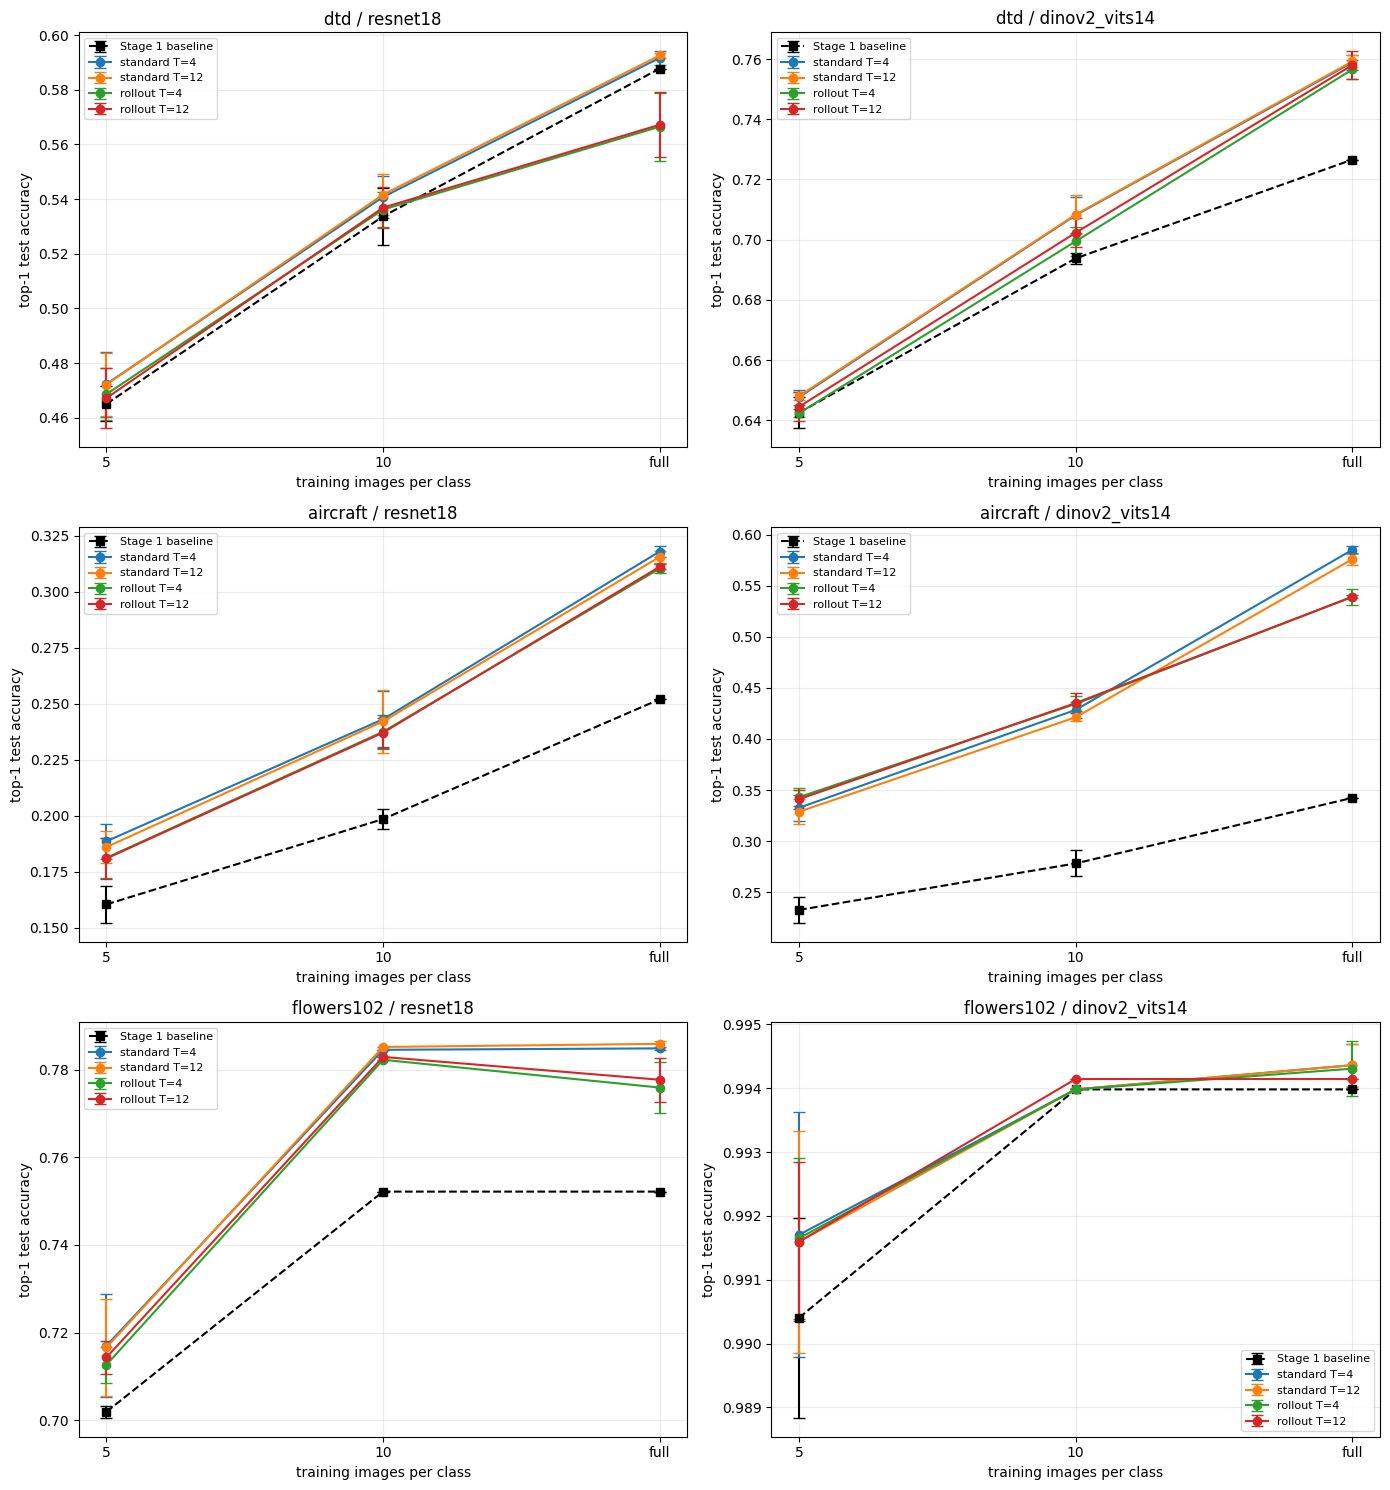

In [10]:
fm_summary = results_df.groupby(['dataset', 'encoder', 'shot', 'variant', 'T'], as_index=False).agg(
    mean_accuracy=('test_accuracy', 'mean'), std_accuracy=('test_accuracy', 'std'), runs=('test_accuracy', 'size'))

baseline_summary = pd.read_csv(STAGE1_PROTOTYPE_ROOT / 'accuracy_summary.csv')
baseline_summary = baseline_summary.rename(columns={'mean_accuracy': 'baseline_mean_accuracy', 'std_accuracy': 'baseline_std_accuracy'})
baseline_summary['shot'] = baseline_summary['shot'].astype(str)

comparison = fm_summary.merge(
    baseline_summary[['dataset', 'encoder', 'shot', 'baseline_mean_accuracy', 'baseline_std_accuracy']],
    on=['dataset', 'encoder', 'shot'], how='left')
comparison['delta_acc'] = comparison['mean_accuracy'] - comparison['baseline_mean_accuracy']
comparison.to_csv(OUTPUT_ROOT / 'accuracy_summary_with_baseline.csv', index=False)
display(comparison.style.format({'mean_accuracy': '{:.4f}', 'std_accuracy': '{:.4f}',
                                  'baseline_mean_accuracy': '{:.4f}', 'baseline_std_accuracy': '{:.4f}',
                                  'delta_acc': '{:+.4f}'}))

shot_x = {'5': 0, '10': 1, 'full': 2}
fig, axes = plt.subplots(len(DATASETS), max_encoders, figsize=(7 * max_encoders, 5 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        ax = axes[i, j]
        base = baseline_summary[(baseline_summary.dataset == dataset_name) & (baseline_summary.encoder == encoder_name)].copy()
        base['x'] = base.shot.map(shot_x); base = base.sort_values('x')
        ax.errorbar(base.x, base.baseline_mean_accuracy, yerr=base.baseline_std_accuracy.fillna(0),
                     marker='s', capsize=4, label='Stage 1 baseline', color='black', linestyle='--')
        part = fm_summary[(fm_summary.dataset == dataset_name) & (fm_summary.encoder == encoder_name)].copy()
        part['x'] = part.shot.map(shot_x)
        for variant, T in [('standard', 4), ('standard', 12), ('rollout', 4), ('rollout', 12)]:
            row = part[(part.variant == variant) & (part['T'] == T)].sort_values('x')
            ax.errorbar(row.x, row.mean_accuracy, yerr=row.std_accuracy.fillna(0), marker='o', capsize=4, label=f'{variant} T={T}')
        ax.set(title=f'{dataset_name} / {encoder_name}', xticks=[0, 1, 2], xticklabels=['5', '10', 'full'],
               xlabel='training images per class', ylabel='top-1 test accuracy')
        ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'accuracy_vs_training_size.png', dpi=180, bbox_inches='tight'); plt.show()


## 9. Representative training curves

Seed 0 of the 10-shot setting is used as the representative run, matching Stage 1's convention. Standard-FM loss (velocity MSE at a random `t`) and rolled-out loss (final-point MSE after a full `T`-step rollout) are different quantities on different scales — plotted together on a log axis purely to check what the PDF asks for: that both approaches train stably and reach a reasonable solution, not to compare their absolute magnitudes.

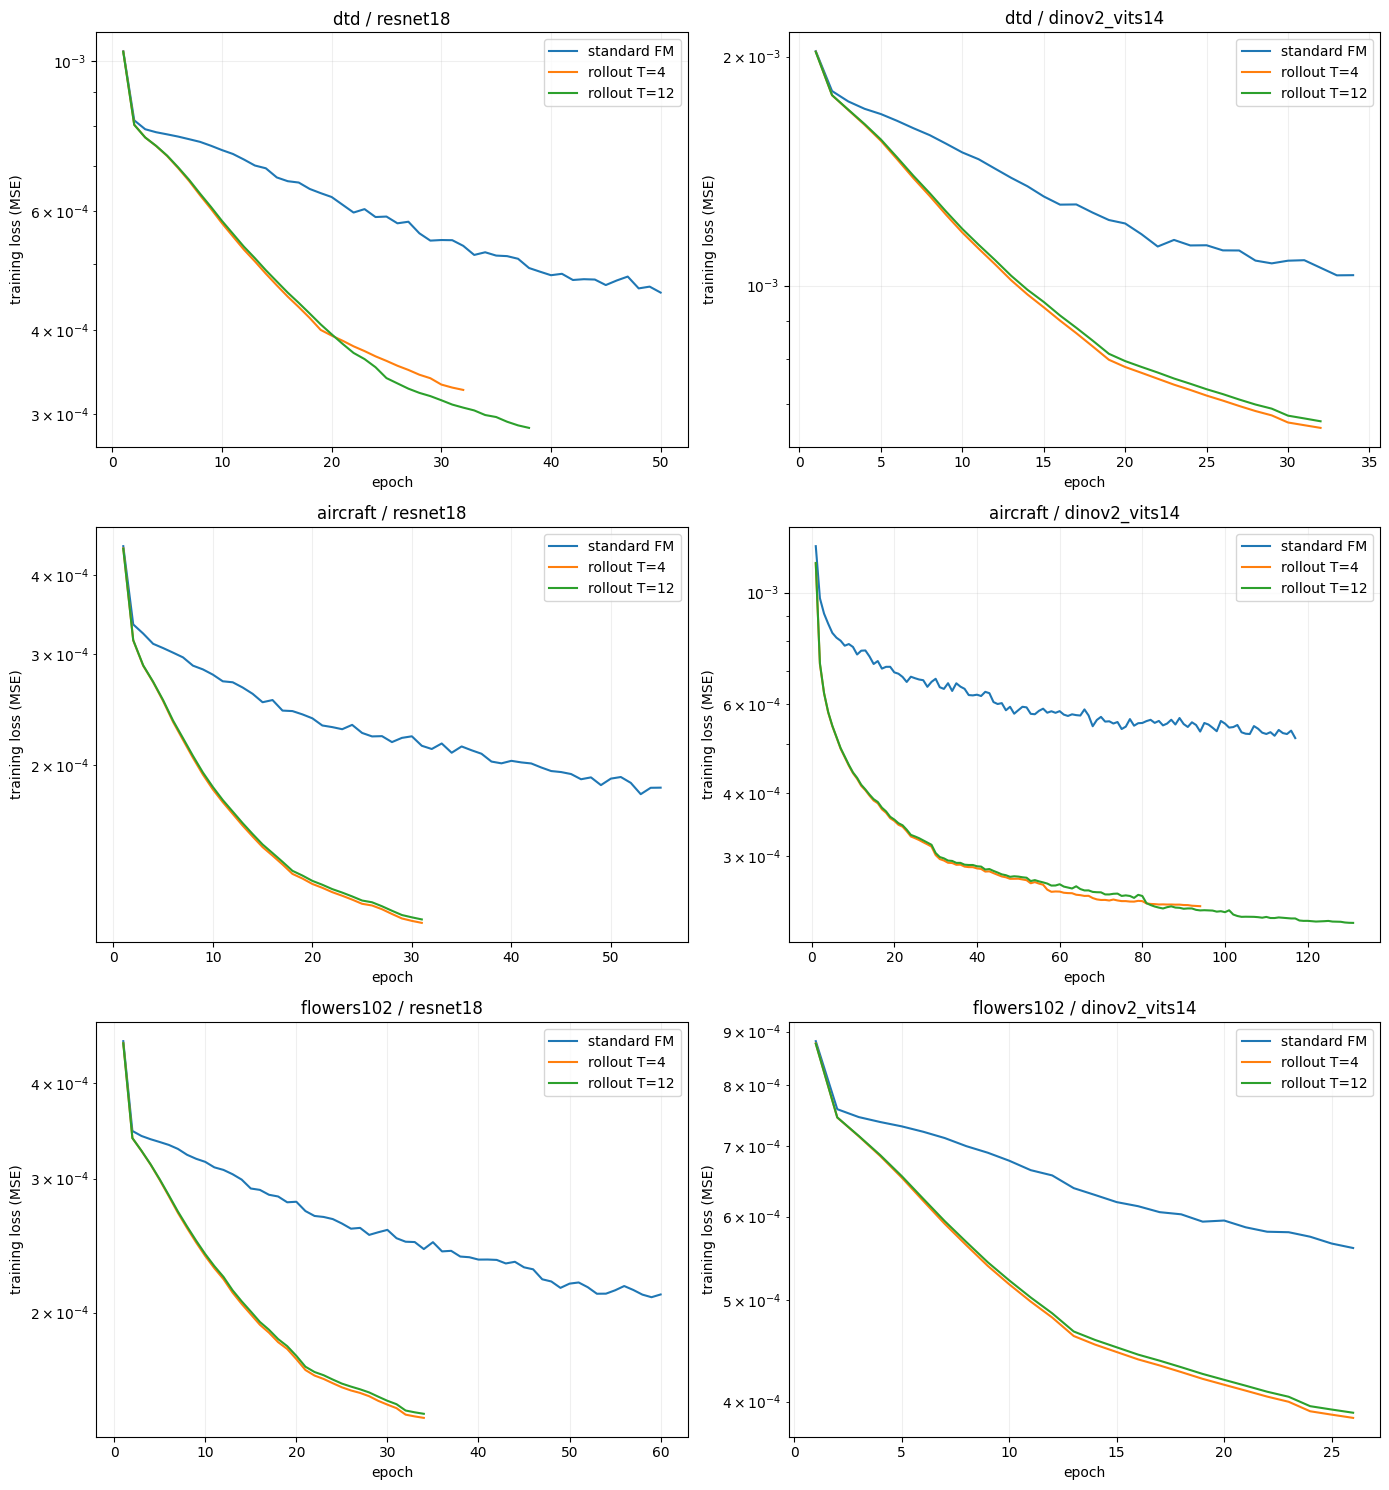

In [11]:
fig, axes = plt.subplots(len(DATASETS), max_encoders, figsize=(7 * max_encoders, 5 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        ax = axes[i, j]
        hist_bundle = fm_histories[(dataset_name, encoder_name, '10', 0)]
        for mode_tag, label in [('standard', 'standard FM'), ('rollout_T4', 'rollout T=4'), ('rollout_T12', 'rollout T=12')]:
            h = pd.DataFrame(hist_bundle[mode_tag])
            ax.plot(h.epoch, h.train_loss, label=label)
        ax.set(title=f'{dataset_name} / {encoder_name}', xlabel='epoch', ylabel='training loss (MSE)', yscale='log')
        ax.legend(); ax.grid(alpha=.2)
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'training_curves.png', dpi=180, bbox_inches='tight'); plt.show()


## 10. Feature-space visualization: original vs. standard-FM vs. rolled-out-FM

Per the PDF, the projection is fit **jointly across all three views plus the prototypes** (one PCA fit over the concatenation of original/standard-transported/rollout-transported features and the selected class prototypes), so the three panels share one coordinate frame and a point's movement between panels is directly comparable — not three independently-fit projections that happen to look similar. The three panels are also drawn with **shared axis limits** (`draw_three_views`), since a joint fit that is then autoscaled per panel would silently rescale each view and hide exactly the contraction the figure is meant to show. Same 10 classes, same up-to-30 test examples per class, and same class colors as Stage 1's feature plots, using the representative 10-shot/seed-0 networks (`T=12`).

`fm_view_bank` caches the joint matrix `[z | z_standard | z_rollout | prototypes]` per (dataset, encoder) so Section 10b's t-SNE view is computed on the *identical* transported tensors rather than re-running the flow with a second set of forward passes.


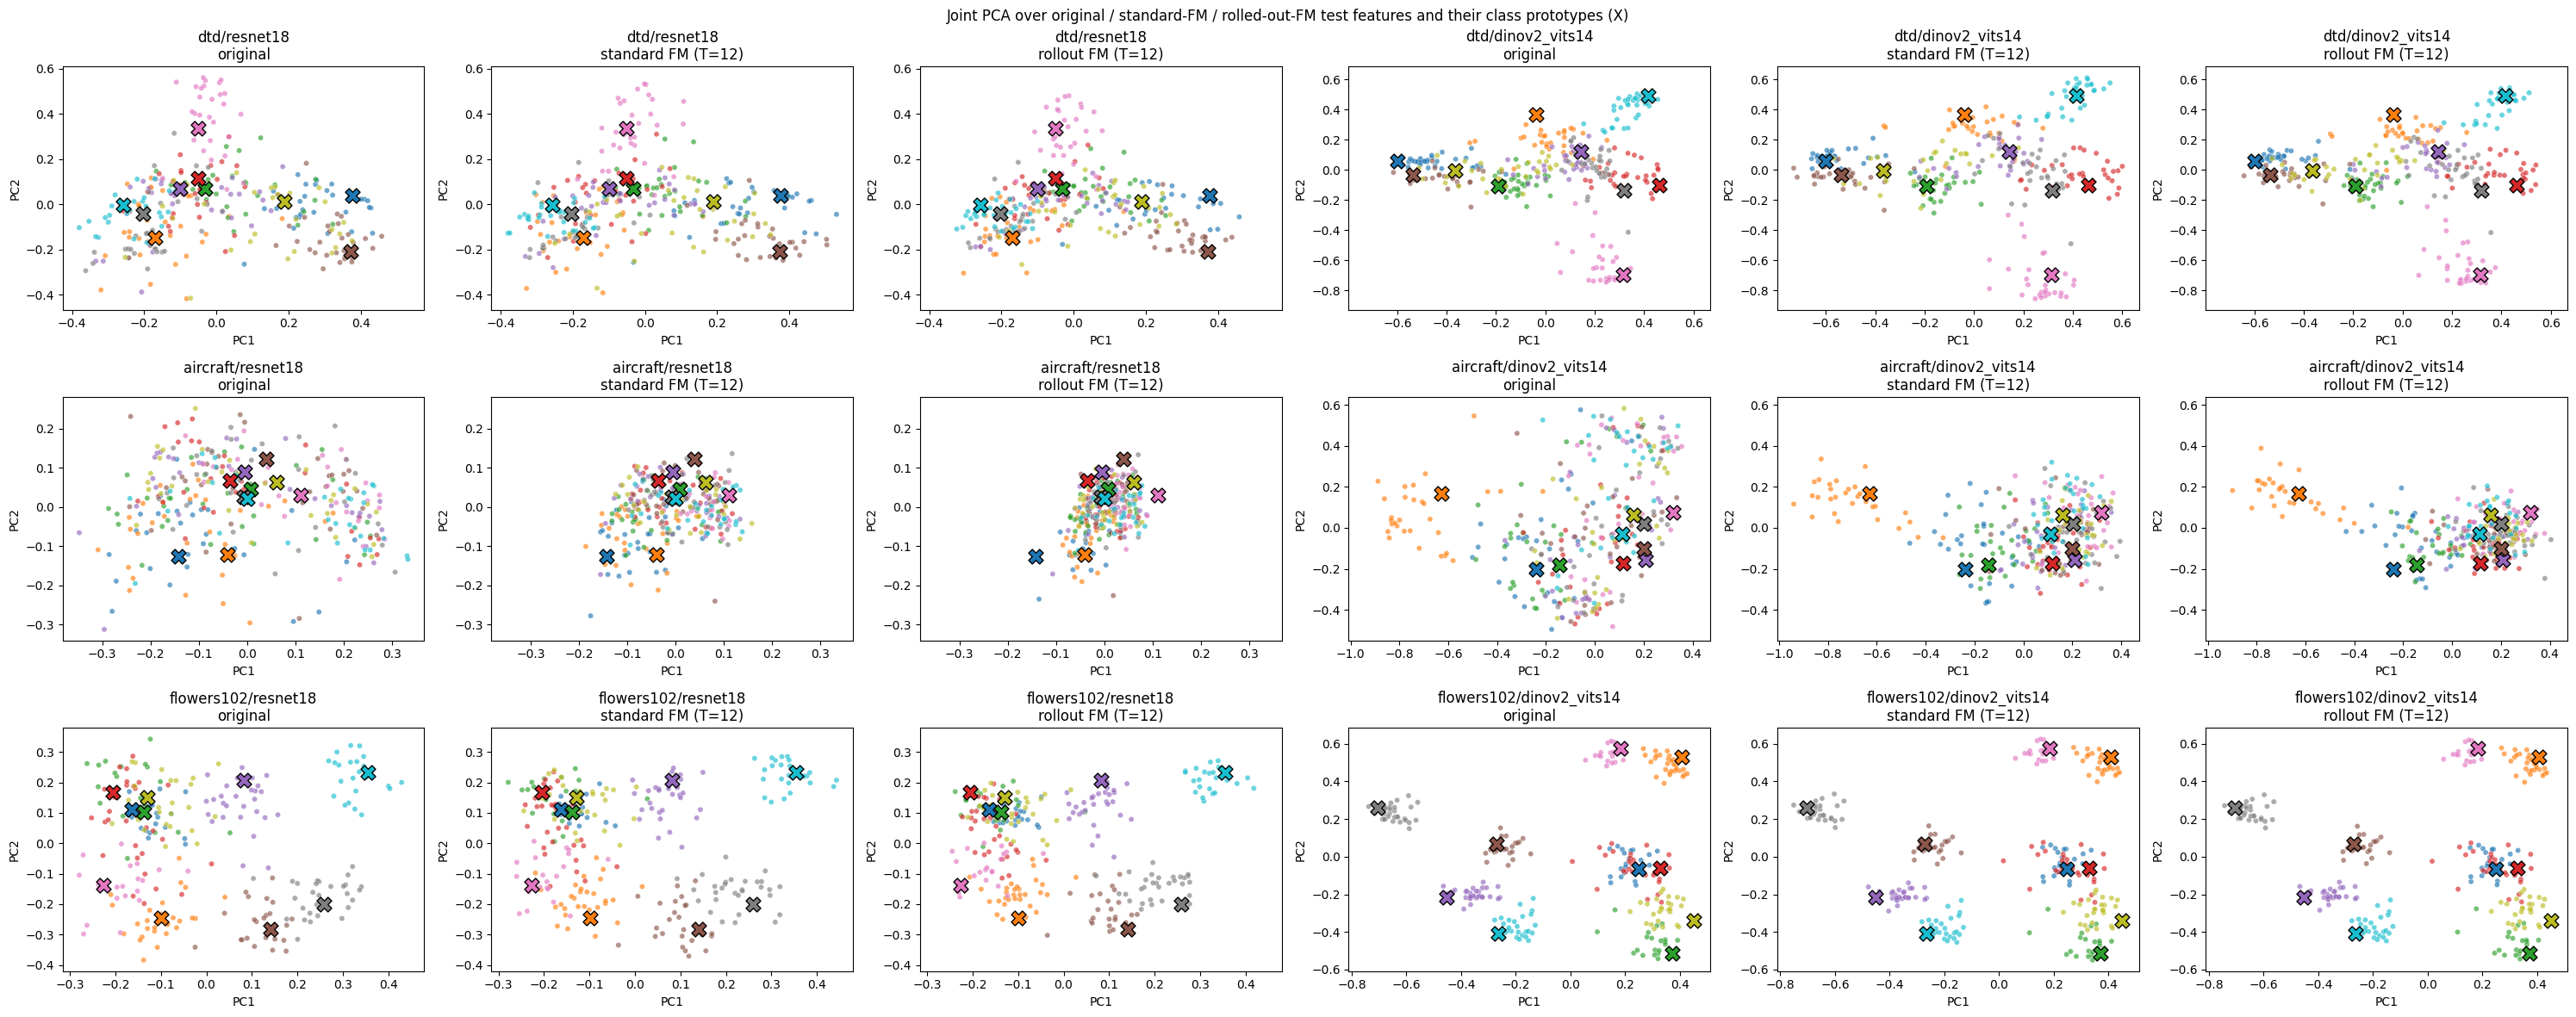

In [12]:
VIEW_TITLES = ['original', 'standard FM (T=12)', 'rollout FM (T=12)']

def draw_three_views(target_axes, xy, n, y, n_classes, dataset_name, encoder_name, axis_labels):
    """Draw the three compared views from one *jointly fit* 2-D embedding `xy` of the row-stacked
    [z | z_standard | z_rollout | prototypes]. All three panels get the same xlim/ylim, so a point's
    displacement between panels is a real movement in the shared projection rather than an artifact
    of per-panel autoscaling."""
    palette = sns.color_palette('tab10', n_classes)
    pad = 0.05 * np.ptp(xy, axis=0)
    xlim = (xy[:, 0].min() - pad[0], xy[:, 0].max() + pad[0])
    ylim = (xy[:, 1].min() - pad[1], xy[:, 1].max() + pad[1])
    proto_xy = xy[3 * n:]
    for k, view_title in enumerate(VIEW_TITLES):
        ax, pts = target_axes[k], xy[k * n:(k + 1) * n]
        sns.scatterplot(x=pts[:, 0], y=pts[:, 1], hue=y, palette=palette, s=20, alpha=.65, ax=ax, legend=False)
        for c_idx in range(n_classes):
            ax.scatter(proto_xy[c_idx, 0], proto_xy[c_idx, 1], color=palette[c_idx], marker='X', s=150, edgecolors='black')
        ax.set(title=f'{dataset_name}/{encoder_name}\n{view_title}', xlabel=axis_labels[0], ylabel=axis_labels[1],
               xlim=xlim, ylim=ylim)

fm_view_bank = {}
fig, axes = plt.subplots(len(DATASETS), max_encoders * 3, figsize=(5 * max_encoders * 3, 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    selected_classes = np.arange(10)
    base_labels = feature_bank[(dataset_name, 'resnet18')]['test']['labels'].numpy()
    selected_idx = np.concatenate([np.flatnonzero(base_labels == c)[:30] for c in selected_classes])
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        bank = feature_bank[(dataset_name, encoder_name)]['test']
        z = F.normalize(bank['features'][selected_idx].float(), dim=1).to(DEVICE)
        y = bank['labels'][selected_idx].numpy()
        prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, '10', 0)
        prototypes = prototypes.to(DEVICE)
        feature_dim = z.shape[1]
        standard_net = load_trained_network(dataset_name, encoder_name, '10', 0, 0, 'standard', feature_dim)
        rollout_net = load_trained_network(dataset_name, encoder_name, '10', 0, 0, 'rollout_T12', feature_dim)
        with torch.no_grad():
            z_standard = euler_rollout(standard_net, z, 12)
            z_rollout = euler_rollout(rollout_net, z, 12)
        joint = torch.cat([z, z_standard, z_rollout, prototypes[selected_classes]]).cpu().numpy()
        fm_view_bank[(dataset_name, encoder_name)] = dict(joint=joint, y=y, n=len(z), n_classes=len(selected_classes))
        xy = PCA(n_components=2).fit_transform(joint)
        draw_three_views(axes[i, 3 * j:3 * j + 3], xy, len(z), y, len(selected_classes),
                         dataset_name, encoder_name, ('PC1', 'PC2'))
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]) * 3, max_encoders * 3):
        axes[i, j].axis('off')
fig.suptitle('Joint PCA over original / standard-FM / rolled-out-FM test features and their class prototypes (X)')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'feature_space_comparison.png', dpi=180, bbox_inches='tight'); plt.show()


## 10b. The same comparison under a joint t-SNE

The PDF allows PCA **or** t-SNE for the feature-space comparison, and Stage 1 (`02_image_prototypes.ipynb`) already shows its features under both, so this repeats Section 10 with t-SNE on exactly the same cached `fm_view_bank` matrices, the same 10 classes, the same test examples, and the same `tab10` colors — the two figures differ only in the projection.

The t-SNE is fit **once per (dataset, encoder) over the full stack** `[z | z_standard | z_rollout | prototypes]`, never once per panel, so all three views and the prototypes live in one embedding, exactly as the PDF requires. `perplexity`, `init='pca'` and `random_state=0` match Stage 1's setting so the two stages' t-SNE views are produced the same way.

**Read this figure qualitatively, and read Section 10 for anything geometric.** t-SNE normalizes local density, so it deliberately re-expands the tightly contracted post-FM clusters: the visual shrinkage toward each prototype will look far milder here than in the PCA panels, even though the transported features are numerically much closer to their prototype. Cluster *separation* and which prototype a class's points sit on are what this view shows well; distances, and the near-collapse the flow actually produces, are what PCA shows well. This is also why the trajectory figure in Section 11 stays on PCA.


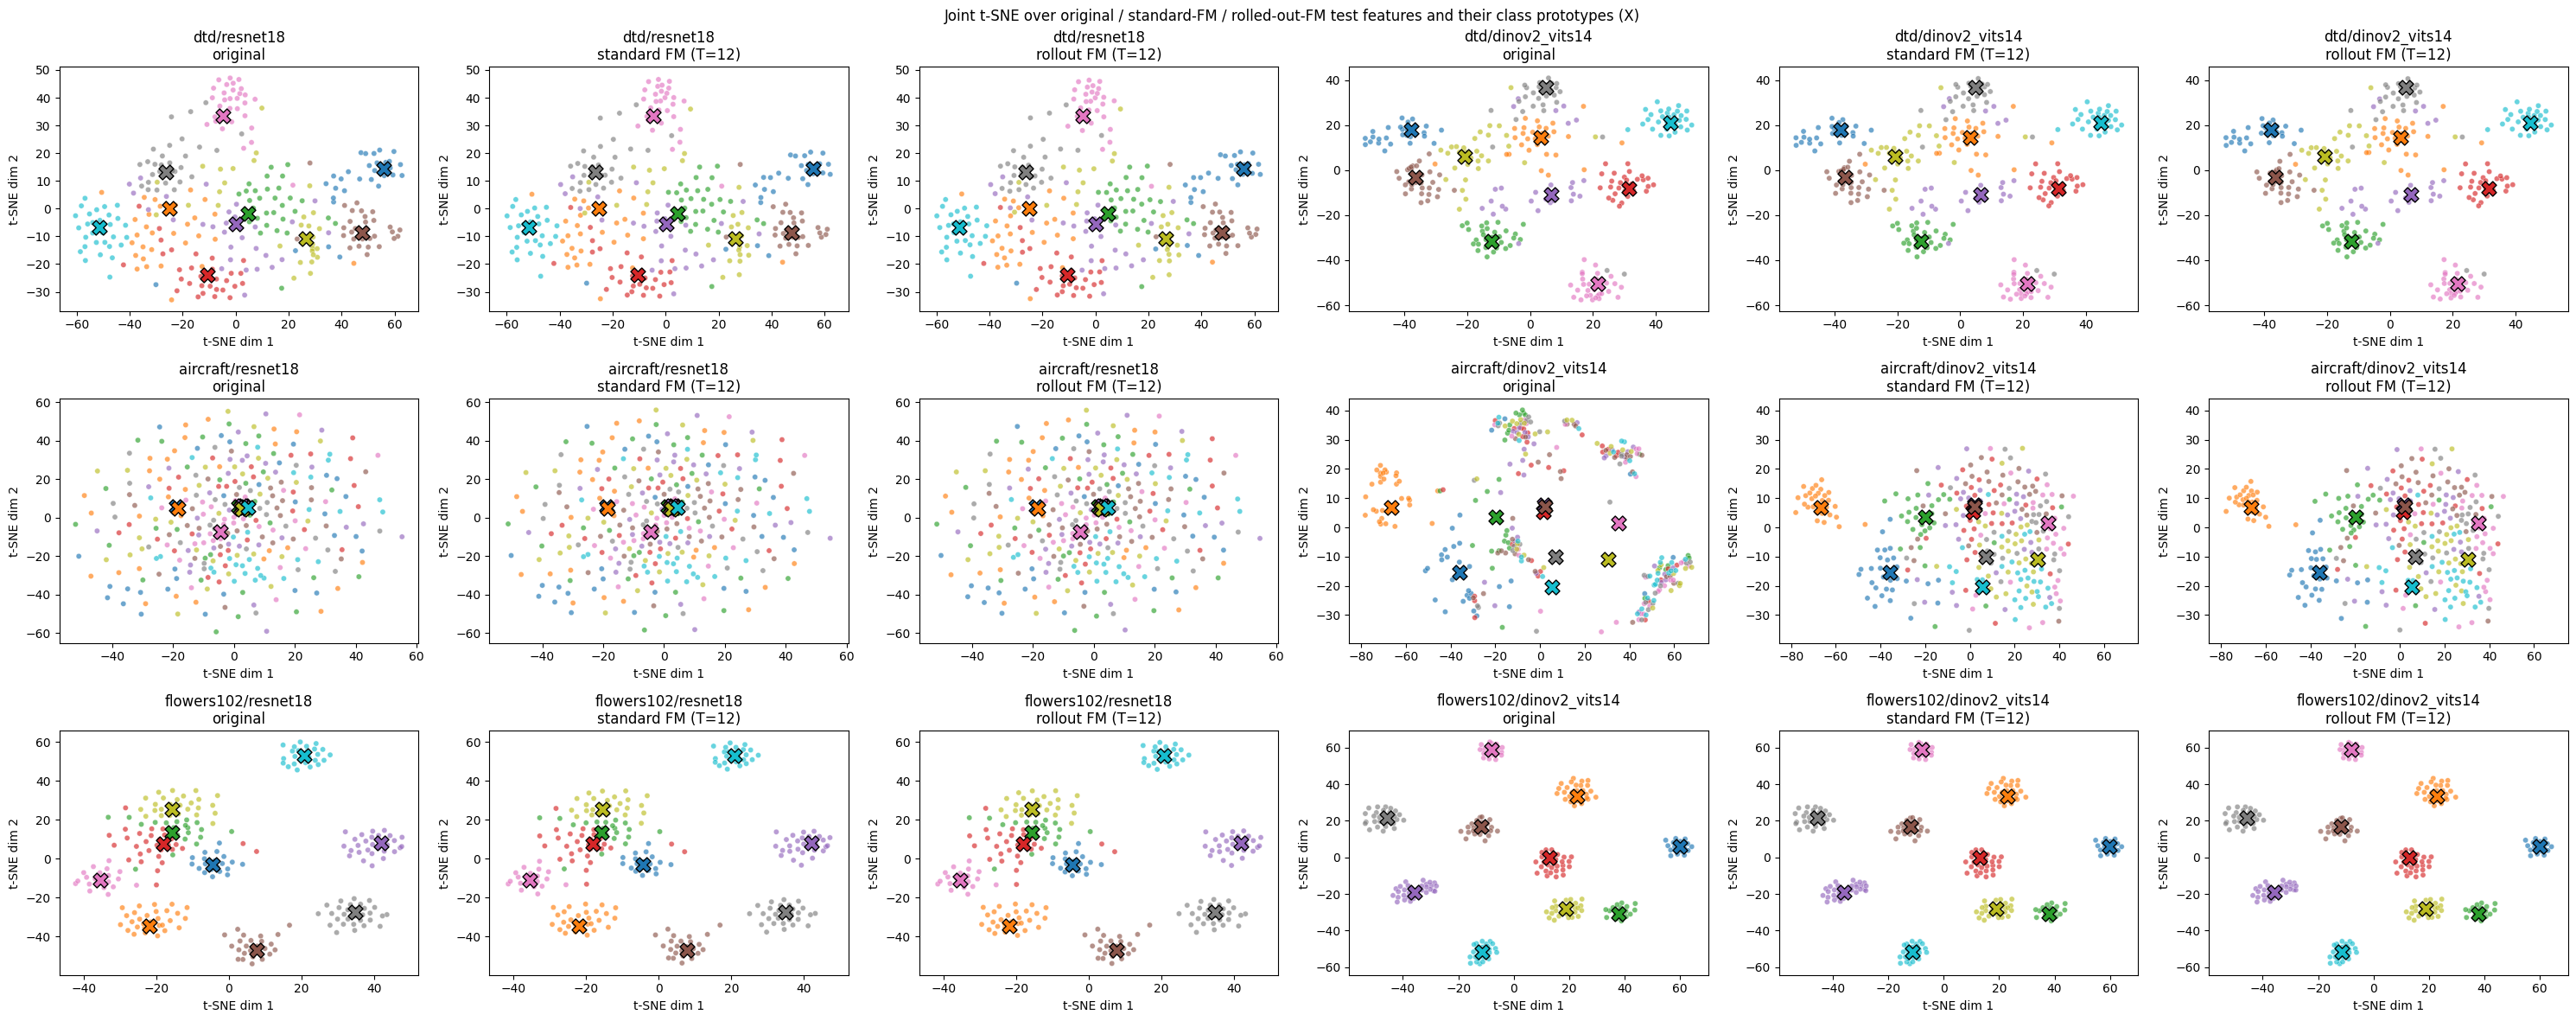

In [13]:
fig, axes = plt.subplots(len(DATASETS), max_encoders * 3, figsize=(5 * max_encoders * 3, 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        view = fm_view_bank[(dataset_name, encoder_name)]
        joint, y, n, n_classes = view['joint'], view['y'], view['n'], view['n_classes']
        perplexity = min(30, max(5, len(joint) // 3 - 1))
        xy = TSNE(n_components=2, perplexity=perplexity, init='pca', random_state=0).fit_transform(joint)
        draw_three_views(axes[i, 3 * j:3 * j + 3], xy, n, y, n_classes,
                         dataset_name, encoder_name, ('t-SNE dim 1', 't-SNE dim 2'))
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]) * 3, max_encoders * 3):
        axes[i, j].axis('off')
fig.suptitle('Joint t-SNE over original / standard-FM / rolled-out-FM test features and their class prototypes (X)')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'feature_space_comparison_tsne.png', dpi=180, bbox_inches='tight'); plt.show()


## 11. Flow trajectories

For 3 representative test examples per dataset (one per class, first 3 classes, strongest encoder per dataset), the intermediate Euler states `z_hat_0 ... z_hat_12` from the standard-FM network are plotted together with the original feature, final transported feature, and target prototype, in one PCA fit jointly over that single trajectory plus its prototype (PCA rather than t-SNE, per the PDF, since the projected path needs to stay geometrically interpretable as a trajectory).

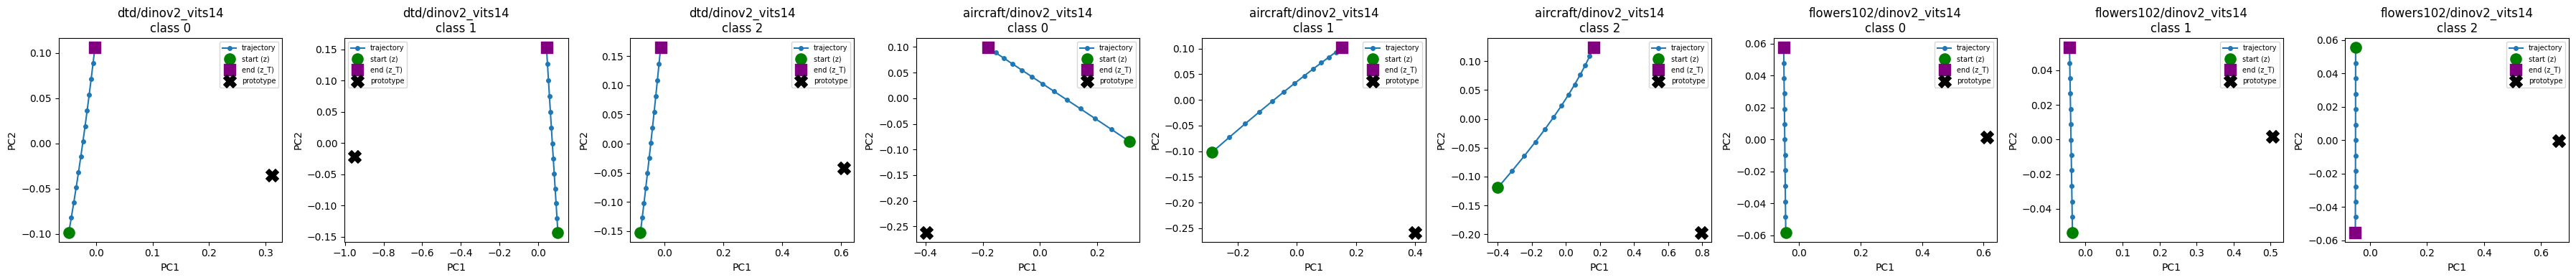

In [14]:
fig, axes = plt.subplots(1, len(DATASETS) * 3, figsize=(4 * len(DATASETS) * 3, 4))
col = 0
for dataset_name in DATASETS:
    encoder_name = ENCODERS_BY_DATASET[dataset_name][-1]
    bank = feature_bank[(dataset_name, encoder_name)]['test']
    y = bank['labels'].numpy()
    chosen_classes = np.arange(3)
    chosen_idx = [int(np.flatnonzero(y == c)[0]) for c in chosen_classes]
    prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, '10', 0)
    prototypes = prototypes.to(DEVICE)
    feature_dim = prototypes.shape[1]
    net = load_trained_network(dataset_name, encoder_name, '10', 0, 0, 'standard', feature_dim)
    for idx, c in zip(chosen_idx, chosen_classes):
        z0 = F.normalize(bank['features'][idx:idx + 1].float(), dim=1).to(DEVICE)
        with torch.no_grad():
            _, trajectory = euler_rollout(net, z0, 12, return_trajectory=True)
        traj = torch.cat(trajectory).cpu().numpy()
        proto = prototypes[c:c + 1].cpu().numpy()
        xy = PCA(n_components=2).fit_transform(np.concatenate([traj, proto]))
        ax = axes[col]; col += 1
        ax.plot(xy[:-1, 0], xy[:-1, 1], '-o', color='tab:blue', markersize=4, label='trajectory')
        ax.scatter(xy[0, 0], xy[0, 1], color='green', s=120, zorder=5, label='start (z)')
        ax.scatter(xy[-2, 0], xy[-2, 1], color='purple', s=120, marker='s', zorder=5, label='end (z_T)')
        ax.scatter(xy[-1, 0], xy[-1, 1], color='black', s=160, marker='X', zorder=5, label='prototype')
        ax.set(title=f'{dataset_name}/{encoder_name}\nclass {c}', xlabel='PC1', ylabel='PC2')
        ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'flow_trajectories.png', dpi=180, bbox_inches='tight'); plt.show()


## 12. Optional extension A: the flow in reverse

The PDF's first optional extension: start from each class prototype at `t=1` and integrate the *same* learned velocity field backward toward `t=0`. `euler_rollout_reverse` evaluates the field at decreasing time and subtracts rather than adds.

Beyond the scatter plot, this section answers the question quantitatively. A **recovery rate** asks, for each class, whether the reverse-flowed prototype lands closest to its *own* class's mean test feature rather than some other class's. The untouched forward prototype's recovery rate is reported alongside as the control - it is the ceiling this measurement can reach, since a prototype that does not already identify its own class cloud cannot be expected to after a round trip.

Two honest caveats. The backward pass evaluates the field at `t` in {1, 1-1/T, ..., 1/T} while the forward pass uses {0, ..., 1-1/T}, so this is **not** the exact inverse of the forward map even for a perfectly learned field. And the forward flow is a deliberate *contraction* - many features are mapped onto one prototype - so it is not invertible in principle; the reverse pass recovers a plausible pre-image, not the original point. Read this as a check on how well-behaved the learned field is, never as a demonstration of invertibility.

In [15]:
def euler_rollout_reverse(v_theta, z0, T, return_trajectory=False):
    """Integrate the learned field backward from t=1 toward t=0. Mirrors `euler_rollout`: same step
    size and one network evaluation per step, but decreasing time and a subtracted update."""
    z = z0
    trajectory = [z0.detach().clone()] if return_trajectory else None
    for k in range(T):
        t = torch.full((z.shape[0],), 1.0 - k / T, device=z.device, dtype=z.dtype)
        z = z - (1.0 / T) * v_theta(z, t)
        if return_trajectory: trajectory.append(z.detach().clone())
    return (z, trajectory) if return_trajectory else z

def class_mean_features(x, y, n_classes):
    """Unit-norm mean test feature per class - the empirical cloud centre a reverse-flowed
    prototype should land nearest to if the learned field is well behaved."""
    means = torch.stack([x[y == c].mean(0) if bool((y == c).any())
                         else torch.zeros(x.shape[1], device=x.device) for c in range(n_classes)])
    return F.normalize(means, dim=1)

REVERSE_T = 12
reverse_rows, reverse_views = [], {}
for dataset_name, encoder_name in ENABLED_PAIRS:
    bank = feature_bank[(dataset_name, encoder_name)]['test']
    x = F.normalize(bank['features'].float(), dim=1).to(DEVICE)
    y = bank['labels'].long().to(DEVICE)
    prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, '10', 0)
    prototypes = prototypes.to(DEVICE)
    n_classes = prototypes.shape[0]
    net = load_trained_network(dataset_name, encoder_name, '10', 0, 0, 'standard', x.shape[1])
    with torch.no_grad():
        reversed_protos, reverse_traj = euler_rollout_reverse(net, prototypes, REVERSE_T, return_trajectory=True)
    means = class_mean_features(x, y, n_classes)
    target = torch.arange(n_classes, device=DEVICE)
    forward_hit = (F.normalize(prototypes, dim=1) @ means.T).argmax(1) == target
    reverse_hit = (F.normalize(reversed_protos, dim=1) @ means.T).argmax(1) == target
    moved = 1 - (F.normalize(reversed_protos, dim=1) * F.normalize(prototypes, dim=1)).sum(1)
    reverse_rows.append(dict(dataset=dataset_name, encoder=encoder_name, classes=n_classes,
                             forward_recovery=forward_hit.float().mean().item(),
                             reverse_recovery=reverse_hit.float().mean().item(),
                             mean_cosine_distance_moved=moved.mean().item()))
    reverse_views[(dataset_name, encoder_name)] = dict(traj=[s.cpu() for s in reverse_traj],
                                                       x=x.cpu(), y=y.cpu())
reverse_summary = pd.DataFrame(reverse_rows)
reverse_summary.to_csv(OUTPUT_ROOT / 'reverse_flow_recovery.csv', index=False)
print('Recovery rate = fraction of classes whose prototype is nearest to its OWN class mean test '
      'feature. "forward" is the untouched Stage 1 prototype: the control and the ceiling.')
display(reverse_summary.style.format({'forward_recovery': '{:.3f}', 'reverse_recovery': '{:.3f}',
                                      'mean_cosine_distance_moved': '{:.4f}'}))

Recovery rate = fraction of classes whose prototype is nearest to its OWN class mean test feature. "forward" is the untouched Stage 1 prototype: the control and the ceiling.


,dataset,encoder,classes,forward_recovery,reverse_recovery,mean_cosine_distance_moved
0,dtd,resnet18,47,0.957,0.957,0.0333
1,dtd,dinov2_vits14,47,1.000,1.000,0.0261
2,aircraft,resnet18,100,0.660,0.530,0.0257
3,aircraft,dinov2_vits14,100,0.690,0.620,0.0443
4,flowers102,resnet18,102,1.000,1.000,0.0143
5,flowers102,dinov2_vits14,102,1.000,1.000,0.0055


### 12b. Where the prototypes go on the way back

The same reverse integration, shown at five reverse times. Each row is one dataset at its strongest encoder; the faint cloud is the real test features (10 classes, up to 30 examples each, same colours as every other figure here) and the **P** markers are the class prototypes after that much backward integration. One PCA per row is fit jointly over the test features and every reverse state shown, and all five panels share axis limits, so movement across a row is real movement in one plane.

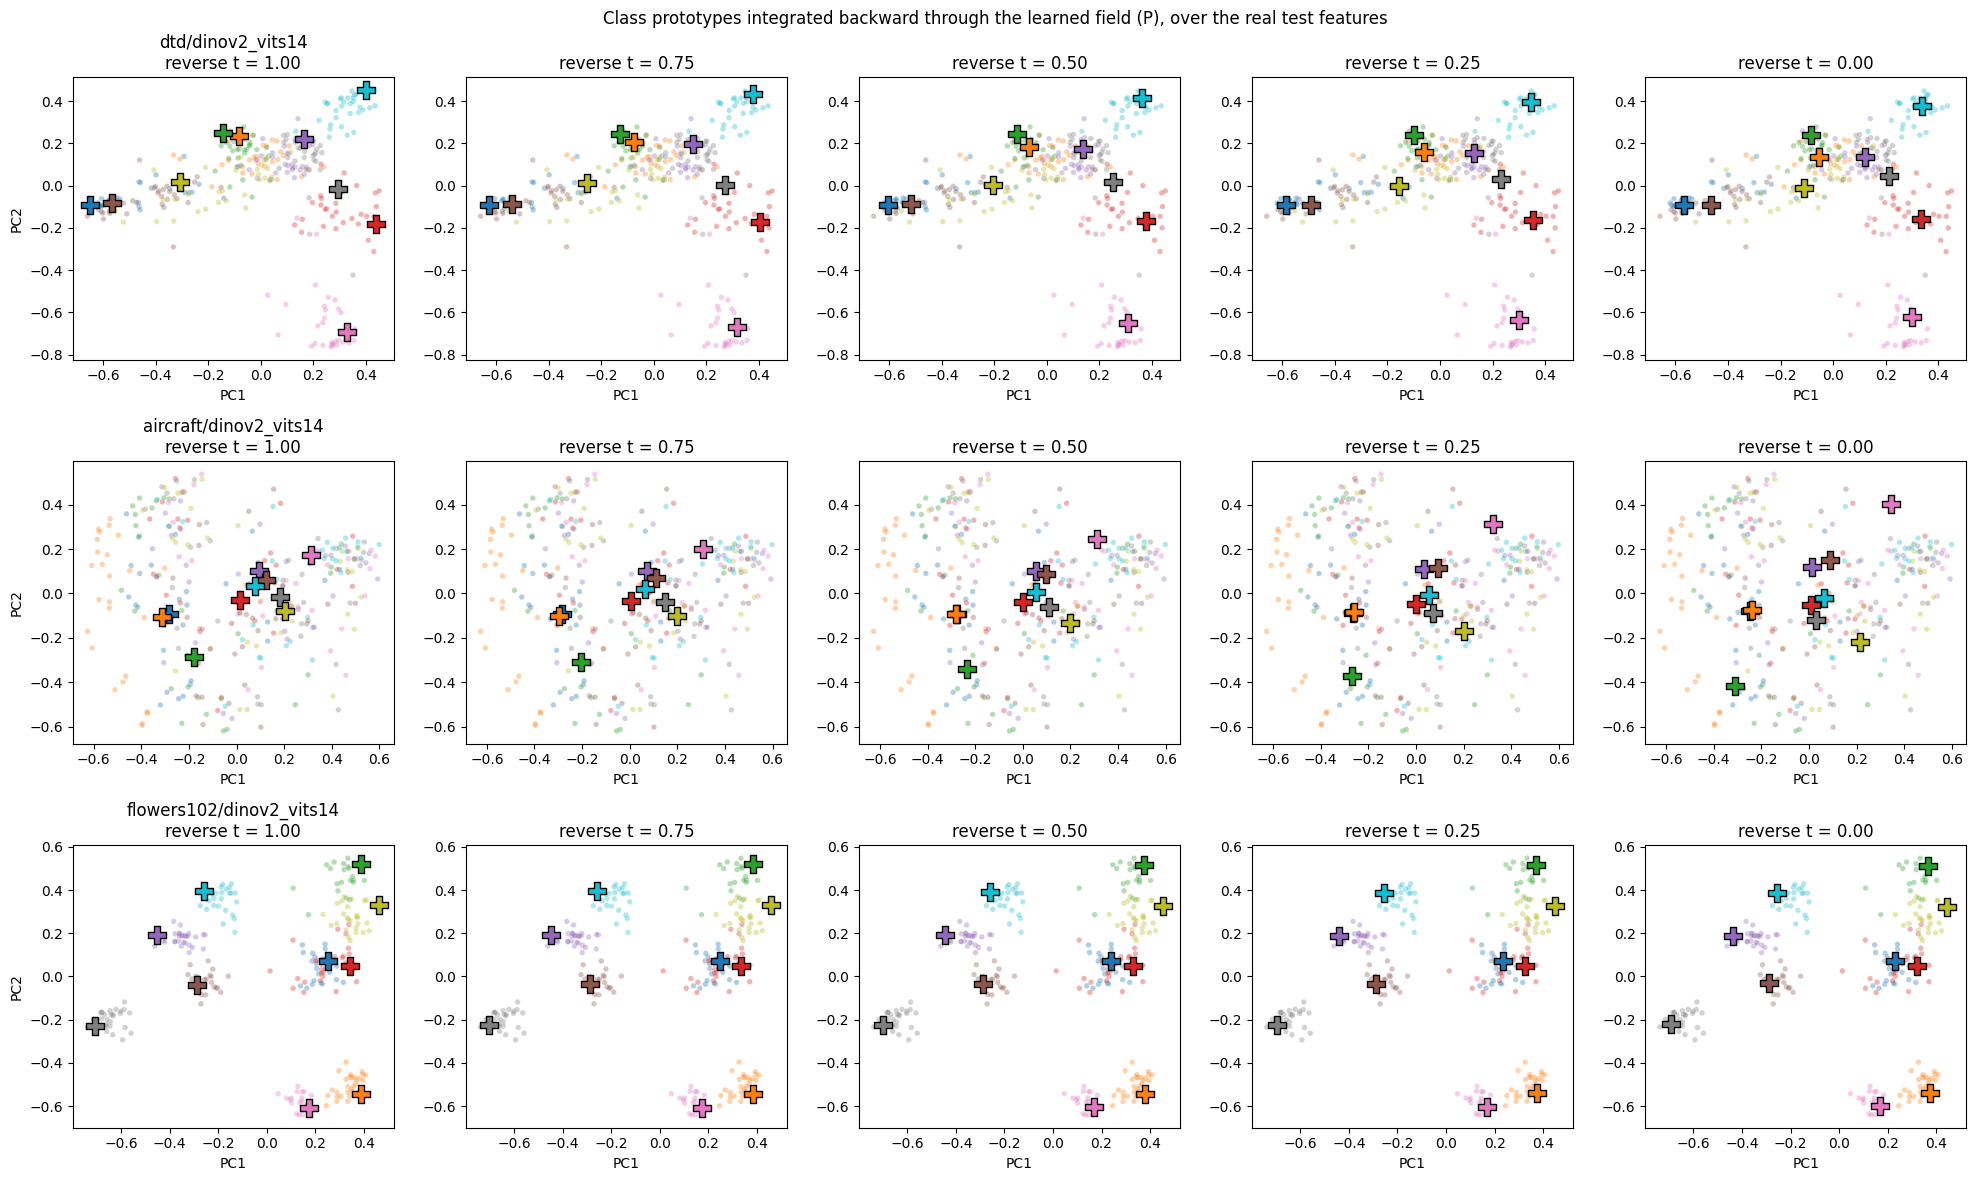

In [16]:
REVERSE_SNAPSHOTS = [0, REVERSE_T // 4, REVERSE_T // 2, 3 * REVERSE_T // 4, REVERSE_T]
fig, axes = plt.subplots(len(DATASETS), len(REVERSE_SNAPSHOTS),
                         figsize=(4 * len(REVERSE_SNAPSHOTS), 4 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    encoder_name = ENCODERS_BY_DATASET[dataset_name][-1]
    view = reverse_views[(dataset_name, encoder_name)]
    labels = view['y'].numpy()
    selected_classes = np.arange(10)
    sel = np.concatenate([np.flatnonzero(labels == c)[:30] for c in selected_classes])
    bg = view['x'][sel].numpy(); bg_y = labels[sel]
    states = [view['traj'][k][selected_classes].numpy() for k in REVERSE_SNAPSHOTS]
    pca = PCA(n_components=2).fit(np.concatenate([bg] + states))
    bg_xy = pca.transform(bg); state_xy = [pca.transform(s) for s in states]
    allxy = np.concatenate([bg_xy] + state_xy)
    pad = 0.05 * np.ptp(allxy, axis=0)
    xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
    ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])
    palette = sns.color_palette('tab10', 10)
    for j, (k, xy) in enumerate(zip(REVERSE_SNAPSHOTS, state_xy)):
        ax = axes[i, j]
        sns.scatterplot(x=bg_xy[:, 0], y=bg_xy[:, 1], hue=bg_y, palette=palette, s=16, alpha=.35,
                        ax=ax, legend=False)
        for c_idx in range(len(selected_classes)):
            ax.scatter(xy[c_idx, 0], xy[c_idx, 1], color=palette[c_idx], marker='P', s=170,
                       edgecolors='black', zorder=5)
        header = f'{dataset_name}/{encoder_name}\n' if j == 0 else ''
        ax.set(title=f'{header}reverse t = {1 - k / REVERSE_T:.2f}', xlabel='PC1',
               ylabel='PC2' if j == 0 else '', xlim=xlim, ylim=ylim)
fig.suptitle('Class prototypes integrated backward through the learned field (P), over the real test features')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'reverse_flow.png', dpi=180, bbox_inches='tight'); plt.show()

## 13. Optional extension B: samples and prototypes at intermediate flow times

The PDF's second optional extension, and the most informative diagnostic in this notebook: instead of looking only at `t=0` and `t=1`, measure what the flow is doing at **every** Euler state.

Two rows of the resulting curve are self-checking, which is what makes it trustworthy:

- **`t=0` is the Stage 1 baseline.** The state at `t=0` is the untouched feature, so classifying it *is* the prototype classifier. The cell asserts this against Stage 1's own saved `metrics.json` for the same run.
- **`t=1` is the reported FM test accuracy.** Same states, same classifier, same split.

The accuracy-versus-`t` curve is therefore ΔAcc unrolled: it starts exactly at the Stage 1 number, ends exactly at the Stage 2 number, and shows how the layer gets from one to the other. Three further quantities track the mechanism rather than the outcome - cosine similarity to the true prototype and L2 distance to it (is the point actually being transported to its target?) and the **margin**, `cos(z, p_true) - max over other classes of cos(z, p_c)` (is it being transported to the *right* target, or merely somewhere?). Margin is the one that separates real discrimination from a flow that contracts everything indiscriminately.

Representative setting: 10-shot, seed 0, `T=12`, matching every other figure here. Metrics are computed over the **complete** test split; chunking only bounds memory.

In [17]:
def flow_metrics_over_time(net, x, y, prototypes, T, chunk=2048):
    """Per-step statistics of every intermediate Euler state, over the full test split.

    Uses the shared `euler_rollout`, so these are exactly the states inference produces - chunking
    bounds memory only. Row k=0 is the untouched feature (i.e. the Stage 1 prototype classifier)
    and row k=T is the reported FM result; the rows between are what the PDF's "compare samples
    and prototypes at intermediate flow times" asks for."""
    net.eval()
    P = F.normalize(prototypes, dim=1)
    n_steps = T + 1
    correct, margin = np.zeros(n_steps), np.zeros(n_steps)
    cos_true, dist = np.zeros(n_steps), np.zeros(n_steps)
    with torch.no_grad():
        for s in range(0, len(x), chunk):
            xb, yb = x[s:s + chunk], y[s:s + chunk]
            _, traj = euler_rollout(net, xb, T, return_trajectory=True)
            for k, z in enumerate(traj):
                scores = F.normalize(z, dim=1) @ P.T
                true_score = scores.gather(1, yb.view(-1, 1)).squeeze(1)
                masked = scores.clone(); masked.scatter_(1, yb.view(-1, 1), float('-inf'))
                correct[k] += float((scores.argmax(1) == yb).sum().item())
                margin[k] += float((true_score - masked.max(1).values).sum().item())
                cos_true[k] += float(true_score.sum().item())
                dist[k] += float((z - prototypes[yb]).norm(dim=1).sum().item())
    n = len(x)
    return pd.DataFrame(dict(step=np.arange(n_steps), t=np.arange(n_steps) / T,
                             accuracy=correct / n, margin=margin / n,
                             cosine_to_true_prototype=cos_true / n,
                             distance_to_true_prototype=dist / n))

INTERMEDIATE_T, INTERMEDIATE_SHOT, INTERMEDIATE_SEED = 12, '10', 0
INTERMEDIATE_MODES = [('standard', 'standard FM'),
                      (f'rollout_T{INTERMEDIATE_T}', f'rolled-out FM (T={INTERMEDIATE_T})')]

flow_time_curves, rows = {}, []
for dataset_name, encoder_name in ENABLED_PAIRS:
    bank = feature_bank[(dataset_name, encoder_name)]['test']
    x = F.normalize(bank['features'].float(), dim=1).to(DEVICE)
    y = bank['labels'].long().to(DEVICE)
    prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED)
    prototypes = prototypes.to(DEVICE)
    for mode_tag, label in INTERMEDIATE_MODES:
        net = load_trained_network(dataset_name, encoder_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED,
                                   0, mode_tag, x.shape[1])
        curve = flow_metrics_over_time(net, x, y, prototypes, INTERMEDIATE_T)
        flow_time_curves[(dataset_name, encoder_name, mode_tag)] = curve
        rows.append(dict(dataset=dataset_name, encoder=encoder_name, model=label,
                         acc_t0=curve.accuracy.iloc[0], acc_t1=curve.accuracy.iloc[-1],
                         gain=curve.accuracy.iloc[-1] - curve.accuracy.iloc[0],
                         best_t=float(curve.t[curve.accuracy.idxmax()]), best_acc=curve.accuracy.max(),
                         margin_t0=curve.margin.iloc[0], margin_t1=curve.margin.iloc[-1],
                         cos_t0=curve.cosine_to_true_prototype.iloc[0],
                         cos_t1=curve.cosine_to_true_prototype.iloc[-1]))
    # t=0 must reproduce Stage 1's own saved number for this exact run, or the curve is not
    # anchored to the baseline it claims to start from.
    baseline_path = (STAGE1_PROTOTYPE_ROOT / 'runs' / dataset_name / encoder_name /
                     INTERMEDIATE_SHOT / f'seed_{INTERMEDIATE_SEED}' / 'metrics.json')
    if baseline_path.exists():
        baseline_acc = json.loads(baseline_path.read_text())['test_accuracy']
        drift = abs(flow_time_curves[(dataset_name, encoder_name, 'standard')].accuracy.iloc[0] - baseline_acc)
        assert drift < 1e-6, (f'{dataset_name}/{encoder_name}: t=0 accuracy differs from the Stage 1 '
                              f'prototype run by {drift:.2e}; the curve is not anchored to that baseline.')

flow_time_summary = pd.DataFrame(rows)
flow_time_summary.to_csv(OUTPUT_ROOT / 'intermediate_flow_time_metrics.csv', index=False)
print('Verified: t=0 accuracy equals the saved Stage 1 prototype run for every dataset/encoder.')
display(flow_time_summary.style.format({c: '{:.4f}' for c in
        ['acc_t0', 'acc_t1', 'gain', 'best_t', 'best_acc', 'margin_t0', 'margin_t1', 'cos_t0', 'cos_t1']}))

Verified: t=0 accuracy equals the saved Stage 1 prototype run for every dataset/encoder.


,dataset,encoder,model,acc_t0,acc_t1,gain,best_t,best_acc,margin_t0,margin_t1,cos_t0,cos_t1
0,dtd,resnet18,standard FM,0.5239,0.5330,0.0090,0.4167,0.5394,0.0051,0.0035,0.7260,0.8186
1,dtd,resnet18,rolled-out FM (T=12),0.5239,0.5282,0.0043,0.4167,0.5399,0.0051,0.0028,0.7260,0.8143
2,dtd,dinov2_vits14,standard FM,0.6936,0.7027,0.0090,0.8333,0.7037,0.1135,0.1110,0.5439,0.6387
3,dtd,dinov2_vits14,rolled-out FM (T=12),0.6936,0.6968,0.0032,0.3333,0.7011,0.1135,0.1028,0.5439,0.6264
4,aircraft,resnet18,standard FM,0.2019,0.2514,0.0495,1.0000,0.2514,-0.0160,-0.0072,0.8894,0.9419
5,aircraft,resnet18,rolled-out FM (T=12),0.2019,0.2337,0.0318,0.8333,0.2397,-0.0160,-0.0071,0.8894,0.9269
6,aircraft,dinov2_vits14,standard FM,0.2919,0.4257,0.1338,1.0000,0.4257,-0.0542,-0.0088,0.7087,0.8831
7,aircraft,dinov2_vits14,rolled-out FM (T=12),0.2919,0.4401,0.1482,0.7500,0.4476,-0.0542,-0.0050,0.7087,0.9069
8,flowers102,resnet18,standard FM,0.7522,0.7852,0.0330,0.6667,0.7852,0.0220,0.0197,0.8870,0.9296
9,flowers102,resnet18,rolled-out FM (T=12),0.7522,0.7829,0.0307,1.0000,0.7829,0.0220,0.0178,0.8870,0.9187


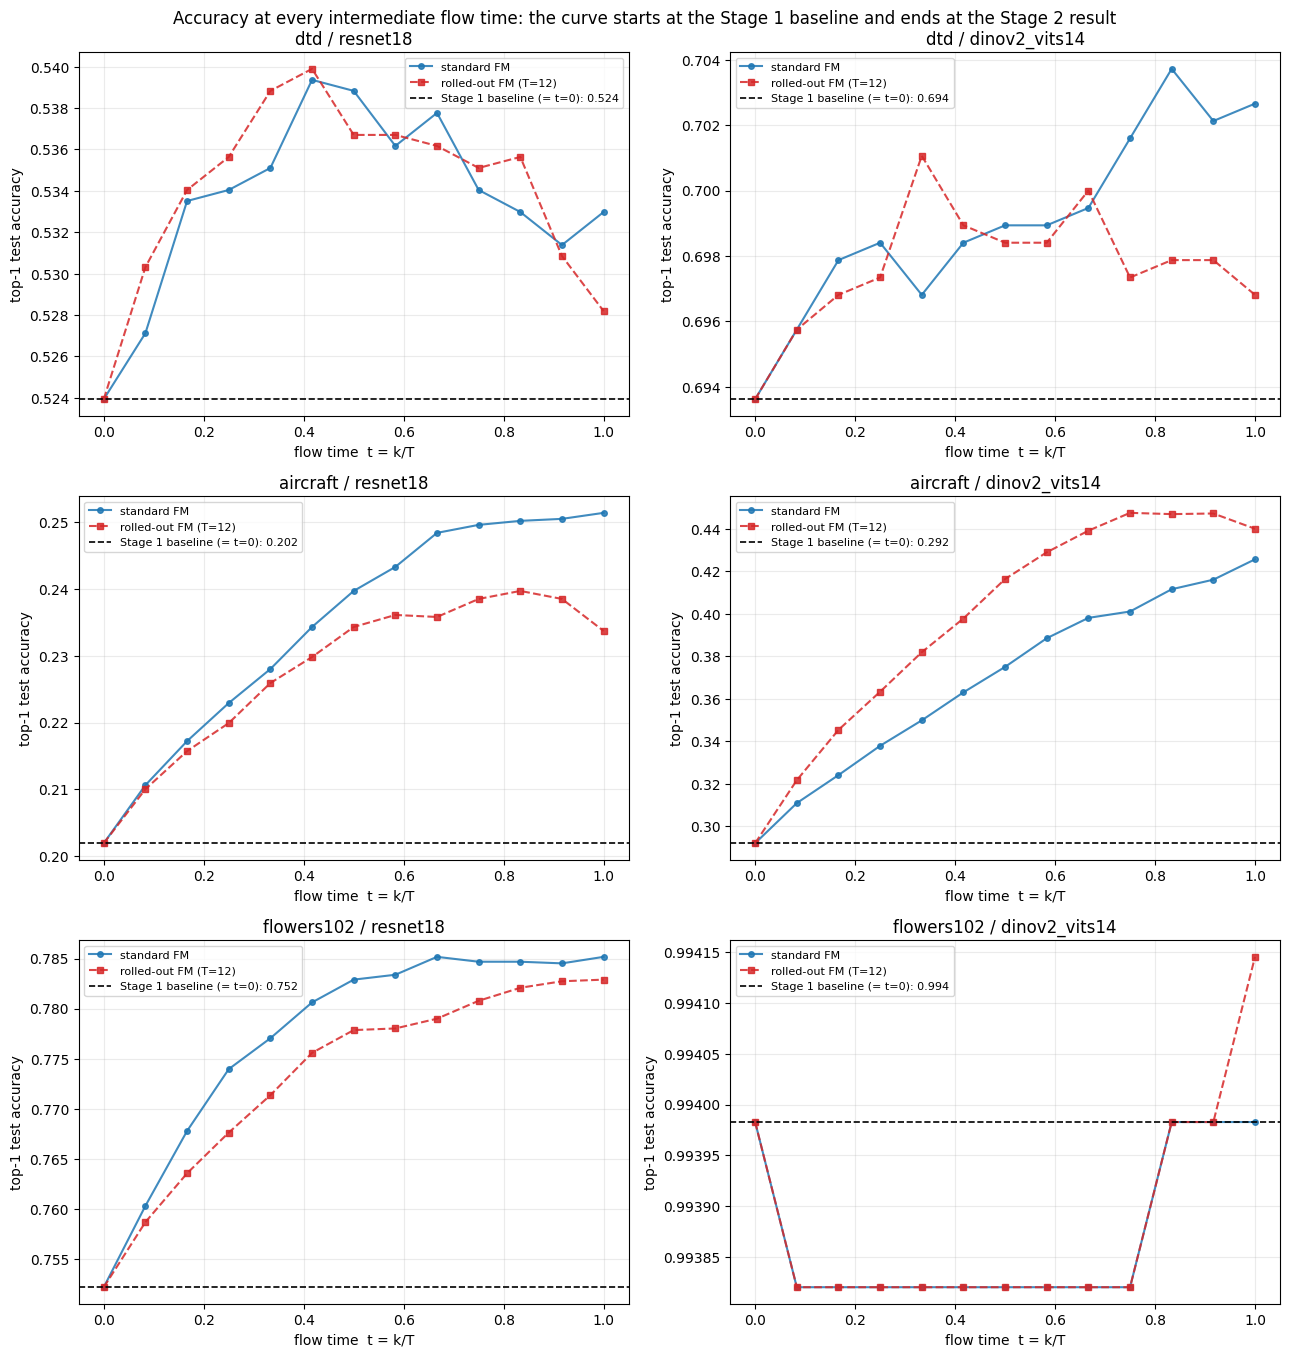

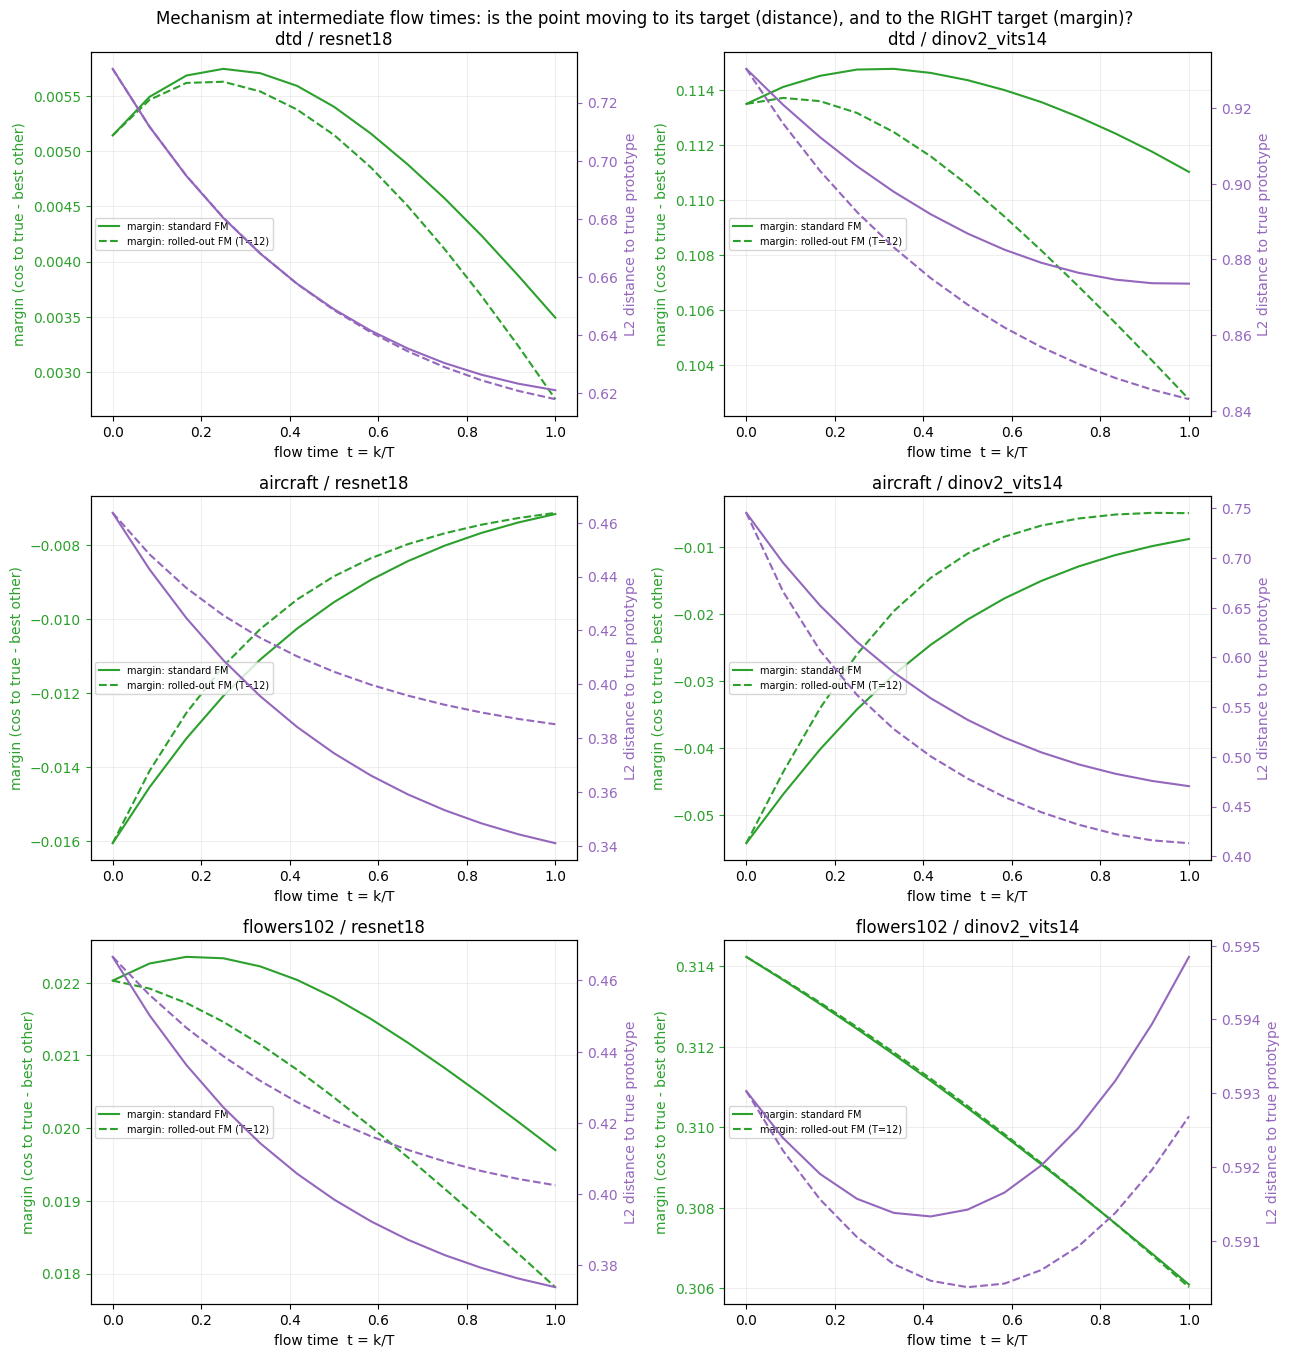

In [18]:
fig, axes = plt.subplots(len(DATASETS), max_encoders, figsize=(6.5 * max_encoders, 4.6 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        ax = axes[i, j]
        for (mode_tag, label), (color, style, marker) in zip(
                INTERMEDIATE_MODES, [('tab:blue', '-', 'o'), ('tab:red', '--', 's')]):
            c = flow_time_curves[(dataset_name, encoder_name, mode_tag)]
            # distinct dash + marker: a well-learned field can make the two curves coincide,
            # and two solid lines would then look like one series
            ax.plot(c.t, c.accuracy, style, marker=marker, ms=4, color=color, label=label, alpha=.85)
        base = flow_time_curves[(dataset_name, encoder_name, 'standard')].accuracy.iloc[0]
        ax.axhline(base, color='black', ls='--', lw=1.2, label=f'Stage 1 baseline (= t=0): {base:.3f}')
        ax.set(title=f'{dataset_name} / {encoder_name}', xlabel='flow time  t = k/T',
               ylabel='top-1 test accuracy')
        ax.grid(alpha=.25); ax.legend(fontsize=8)
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
        axes[i, j].axis('off')
fig.suptitle('Accuracy at every intermediate flow time: the curve starts at the Stage 1 baseline and ends at the Stage 2 result')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'accuracy_vs_flow_time.png', dpi=180, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(len(DATASETS), max_encoders, figsize=(6.5 * max_encoders, 4.6 * len(DATASETS)), squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        ax = axes[i, j]; twin = ax.twinx()
        for (mode_tag, label), style in zip(INTERMEDIATE_MODES, ['-', '--']):
            c = flow_time_curves[(dataset_name, encoder_name, mode_tag)]
            ax.plot(c.t, c.margin, style, color='tab:green', label=f'margin: {label}')
            twin.plot(c.t, c.distance_to_true_prototype, style, color='tab:purple',
                      label=f'distance: {label}')
        ax.set(title=f'{dataset_name} / {encoder_name}', xlabel='flow time  t = k/T')
        ax.set_ylabel('margin (cos to true - best other)', color='tab:green')
        twin.set_ylabel('L2 distance to true prototype', color='tab:purple')
        ax.tick_params(axis='y', colors='tab:green'); twin.tick_params(axis='y', colors='tab:purple')
        ax.grid(alpha=.2); ax.legend(fontsize=7, loc='center left')
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
        axes[i, j].axis('off')
fig.suptitle('Mechanism at intermediate flow times: is the point moving to its target (distance), and to the RIGHT target (margin)?')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'margin_and_distance_vs_flow_time.png', dpi=180, bbox_inches='tight'); plt.show()

### 13b. The point cloud at intermediate flow times

The same intermediate states, shown rather than measured. Each row is one dataset at its strongest encoder, once per training objective; columns are `t = 0, 1/4, 1/2, 3/4, 1`. One PCA per row is fit jointly over **every** snapshot plus the prototypes, and all five panels share axis limits, so contraction across a row is real movement in a single plane rather than five independently scaled plots.

This is the figure that makes the mechanism obvious: classes start as overlapping clouds and are pulled onto their prototypes (X). Comparing the two objectives, standard FM moves points along nearly straight, roughly parallel paths, while rolled-out FM - supervised only on the endpoint - is free to take a more curved route.

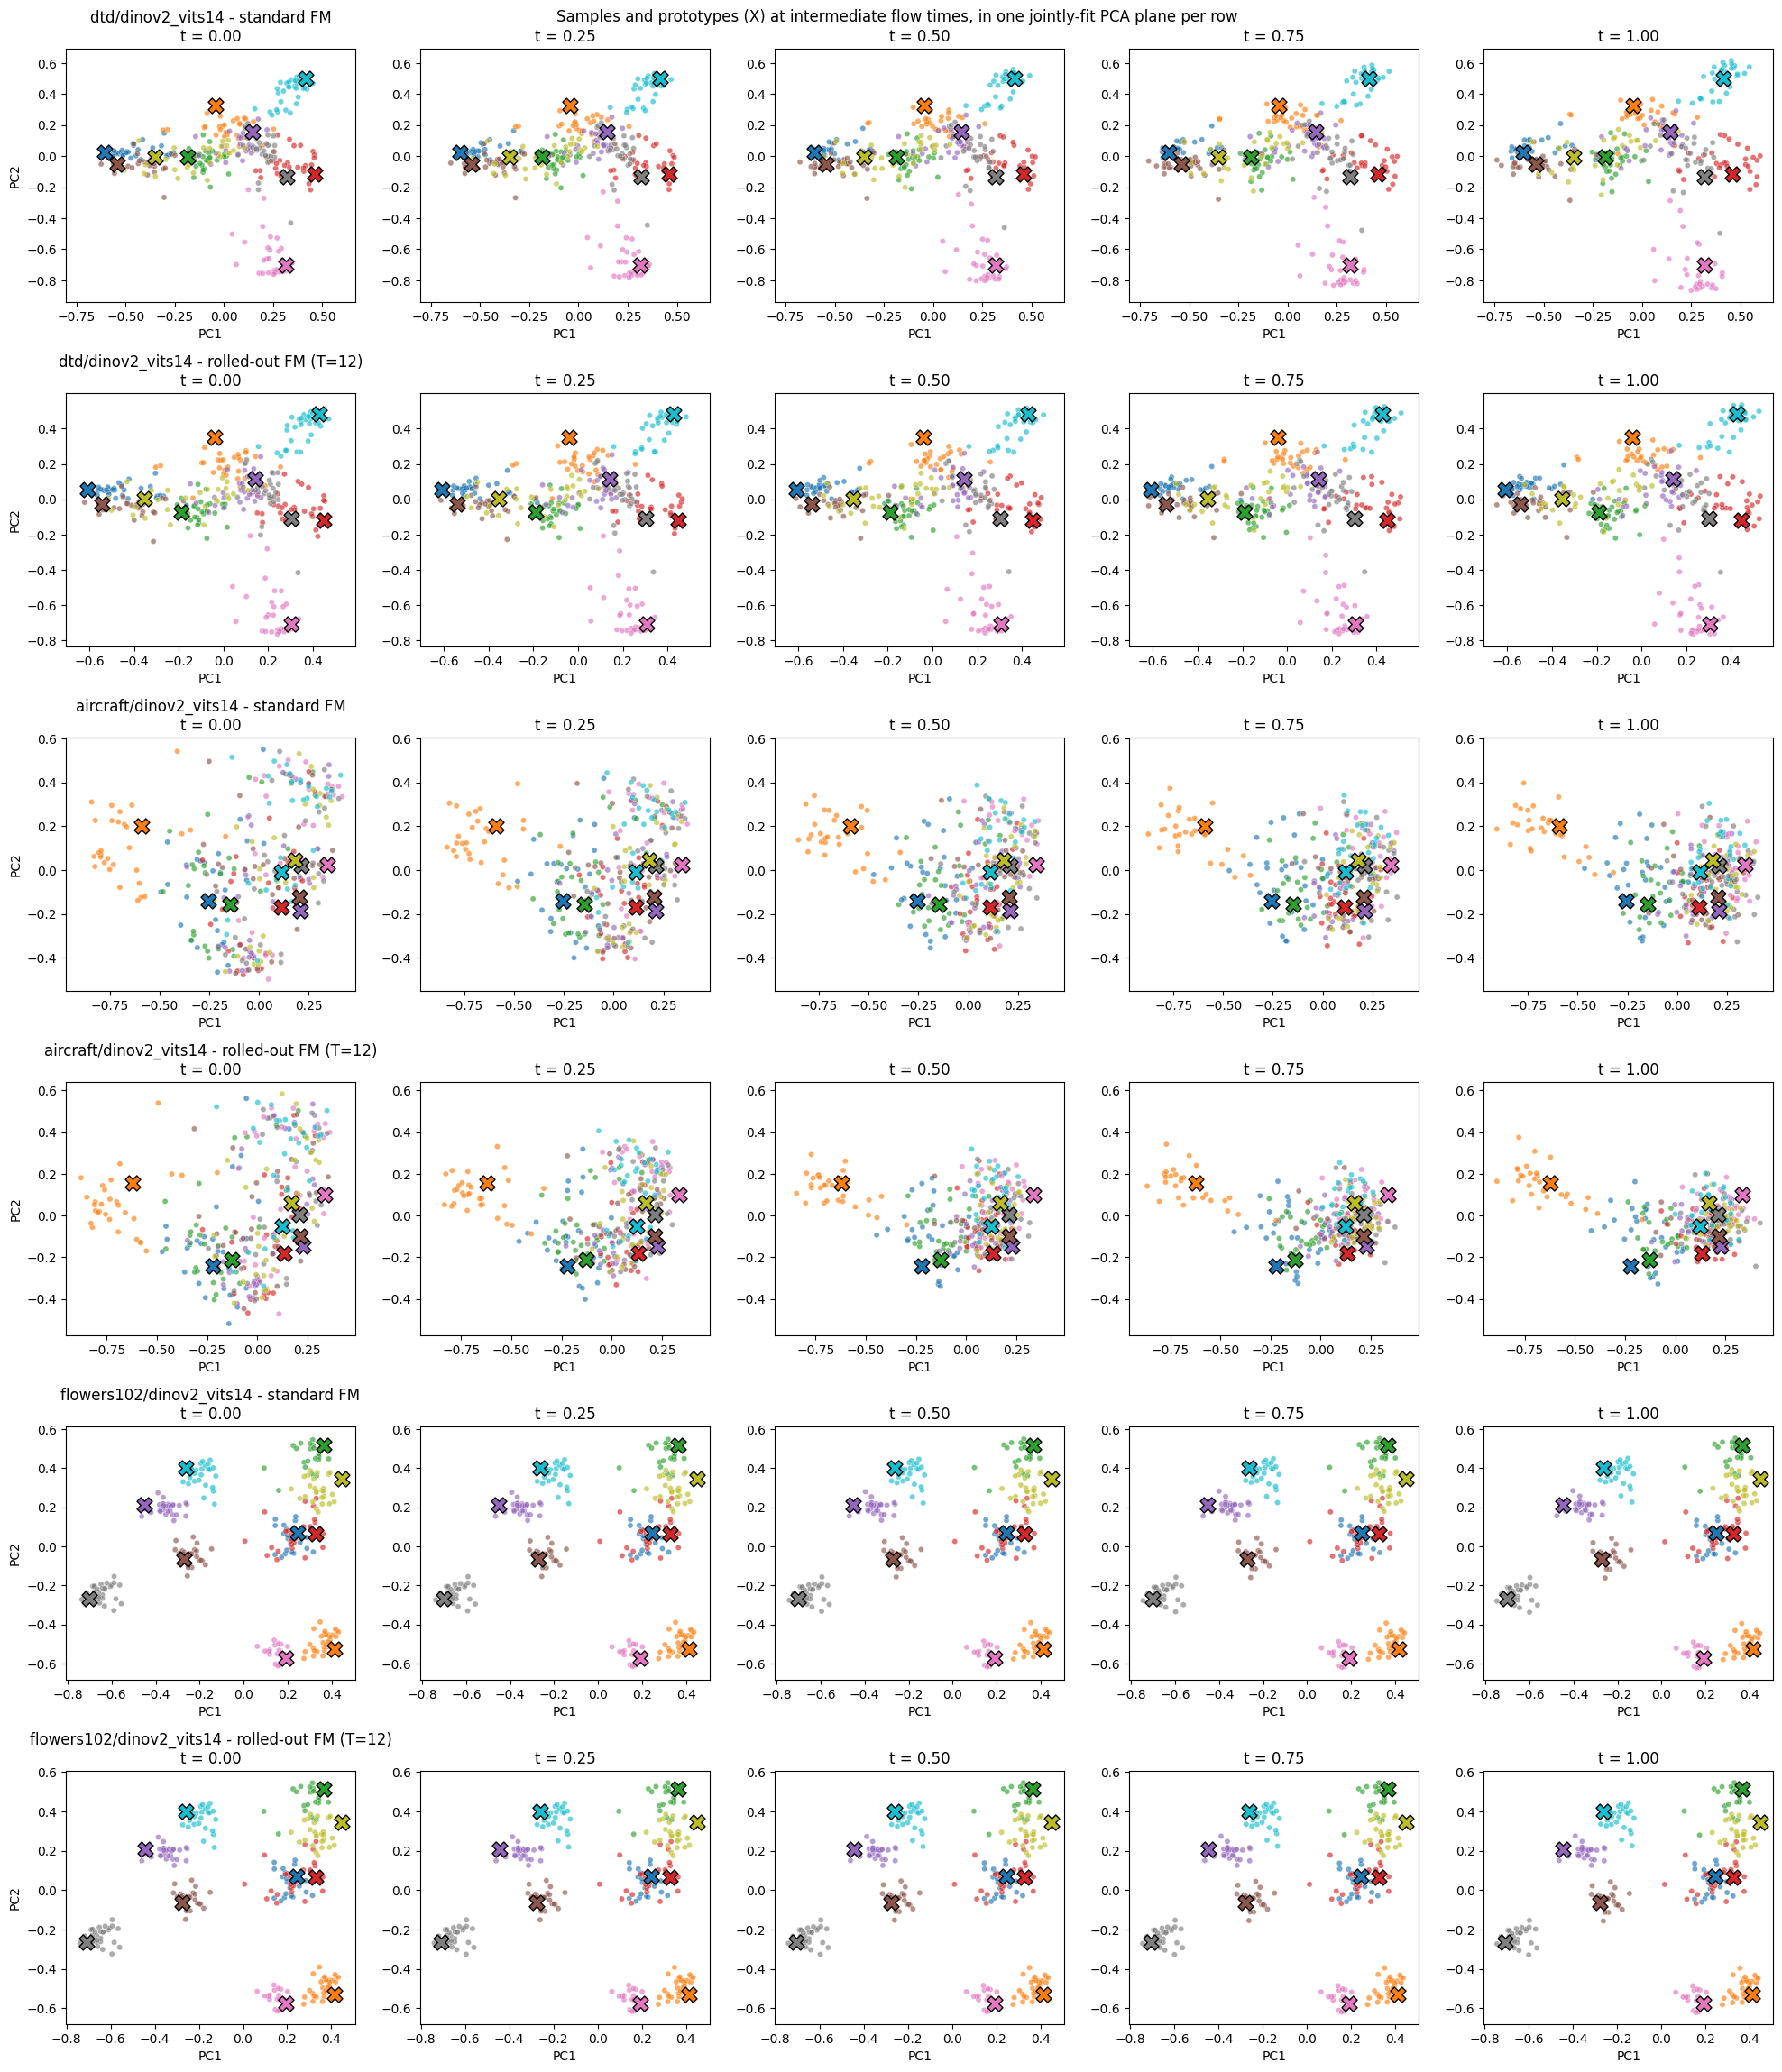

In [19]:
SNAPSHOT_STEPS = [0, INTERMEDIATE_T // 4, INTERMEDIATE_T // 2, 3 * INTERMEDIATE_T // 4, INTERMEDIATE_T]
panel_rows = [(d, ENCODERS_BY_DATASET[d][-1], m, lbl) for d in DATASETS for m, lbl in INTERMEDIATE_MODES]
fig, axes = plt.subplots(len(panel_rows), len(SNAPSHOT_STEPS),
                         figsize=(4 * len(SNAPSHOT_STEPS), 3.9 * len(panel_rows)), squeeze=False)
for i, (dataset_name, encoder_name, mode_tag, label) in enumerate(panel_rows):
    bank = feature_bank[(dataset_name, encoder_name)]['test']
    labels = bank['labels'].numpy()
    selected_classes = np.arange(10)
    sel = np.concatenate([np.flatnonzero(labels == c)[:30] for c in selected_classes])
    z = F.normalize(bank['features'][sel].float(), dim=1).to(DEVICE)
    y = labels[sel]
    prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED)
    prototypes = prototypes.to(DEVICE)
    net = load_trained_network(dataset_name, encoder_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED,
                               0, mode_tag, z.shape[1])
    with torch.no_grad():
        _, traj = euler_rollout(net, z, INTERMEDIATE_T, return_trajectory=True)
    states = [traj[k].cpu().numpy() for k in SNAPSHOT_STEPS]
    protos_np = prototypes[selected_classes].cpu().numpy()
    pca = PCA(n_components=2).fit(np.concatenate(states + [protos_np]))
    state_xy = [pca.transform(s) for s in states]; proto_xy = pca.transform(protos_np)
    allxy = np.concatenate(state_xy + [proto_xy])
    pad = 0.05 * np.ptp(allxy, axis=0)
    xlim = (allxy[:, 0].min() - pad[0], allxy[:, 0].max() + pad[0])
    ylim = (allxy[:, 1].min() - pad[1], allxy[:, 1].max() + pad[1])
    palette = sns.color_palette('tab10', 10)
    for j, (k, xy) in enumerate(zip(SNAPSHOT_STEPS, state_xy)):
        ax = axes[i, j]
        sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=y, palette=palette, s=20, alpha=.65, ax=ax, legend=False)
        for c_idx in range(len(selected_classes)):
            ax.scatter(proto_xy[c_idx, 0], proto_xy[c_idx, 1], color=palette[c_idx], marker='X',
                       s=150, edgecolors='black', zorder=5)
        header = f'{dataset_name}/{encoder_name} - {label}\n' if j == 0 else ''
        ax.set(title=f'{header}t = {k / INTERMEDIATE_T:.2f}', xlabel='PC1',
               ylabel='PC2' if j == 0 else '', xlim=xlim, ylim=ylim)
fig.suptitle('Samples and prototypes (X) at intermediate flow times, in one jointly-fit PCA plane per row')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'intermediate_flow_time_snapshots.png', dpi=180, bbox_inches='tight'); plt.show()

## 14. Paired ΔAcc, confidence intervals, and significance

Sections 8's ΔAcc is a difference of two independently-averaged means. That throws away the fact that Stage 2 deliberately reuses Stage 1's subsets: FM run *s* and baseline run *s* saw **the same K images**, so the per-run difference `Δ_s = Acc_FM,s − Acc_base,s` is a paired quantity with much lower variance than the two marginals suggest. This section recomputes ΔAcc that way and puts an interval on it.

Two statistics are reported, and they answer different questions:

- **Paired per-seed CI** (primary). Mean of `Δ_s` with a 95% t-interval over the repetitions. The unit of analysis is the *run*, so this accounts for subset/initialization variance — the thing that actually differs between repetitions. With `n=3` the interval is wide, which is honest rather than unfortunate.
- **McNemar** (secondary). Baseline and FM predict on the *same test images*, so their disagreements are paired and can be tested directly on the discordant counts. But McNemar's unit is the test image, not the run: it ignores seed variance entirely and is therefore anti-conservative here. Where the two disagree, trust the CI.

At `K=full` the Stage 1 image prototype is a single deterministic closed-form run — the mean over the whole training split has nothing to reseed — so all three FM repetitions are differenced against one baseline and the spread reflects FM initialization variance alone. That is stated in the table via `variance_source` rather than left for the reader to infer.

`n_fixed` and `n_broken` (samples the layer corrects and breaks) are carried here too; Section 15 uses them.

In [20]:
from scipy import stats

def stage1_baseline_run(dataset_name, encoder_name, shot, seed):
    """The Stage 1 image-prototype run this FM run must be compared against. Never recomputed."""
    run_dir = STAGE1_PROTOTYPE_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / f'seed_{seed}'
    metrics_path, pred_path = run_dir / 'metrics.json', run_dir / 'test_predictions.npy'
    if not (metrics_path.exists() and pred_path.exists()):
        raise FileNotFoundError(f'Missing Stage 1 baseline run: {run_dir}. Run 02_image_prototypes.ipynb first.')
    return json.loads(metrics_path.read_text())['test_accuracy'], np.load(pred_path)

def fm_eval_dir(row):
    subset_seed = None if pd.isna(row.subset_seed) else int(row.subset_seed)
    run_tag = f'subset_{subset_seed}__init_{int(row.init_seed)}'
    base = OUTPUT_ROOT / 'runs' / row.dataset / row.encoder / str(row.shot)
    if row.variant == 'standard':
        return base / 'standard' / run_tag / f'eval_T{int(row.T)}'
    return base / f'rollout_T{int(row.T)}' / run_tag / 'eval'

def mcnemar_p(b, c):
    """Two-sided McNemar on the discordant pairs: b = baseline-only-correct, c = FM-only-correct."""
    n = b + c
    if n == 0:
        return 1.0
    if n < 25:  # exact binomial; the chi-square approximation is unreliable this small
        try:
            return float(stats.binomtest(min(b, c), n, 0.5).pvalue)
        except AttributeError:  # scipy < 1.7
            return float(stats.binom_test(min(b, c), n, 0.5))
    return float(stats.chi2.sf((abs(b - c) - 1) ** 2 / n, 1))

paired_rows = []
for row in results_df.itertuples():
    shot = str(row.shot)
    # K-shot pairs on the subset seed - the FM run and the baseline saw the same K images. At
    # K=full the Stage 1 prototype is a single deterministic closed-form run, so all three FM
    # repetitions share one baseline and the spread below is FM initialization variance alone.
    base_seed = 0 if shot == 'full' else int(row.subset_seed)
    base_acc, base_pred = stage1_baseline_run(row.dataset, row.encoder, shot, base_seed)
    fm_pred = np.load(fm_eval_dir(row) / 'test_predictions.npy')
    y_true = feature_bank[(row.dataset, row.encoder)]['test']['labels'].numpy()
    assert len(fm_pred) == len(base_pred) == len(y_true), 'prediction arrays are not the same test split'
    base_ok, fm_ok = base_pred == y_true, fm_pred == y_true
    b = int((base_ok & ~fm_ok).sum())   # broken by FM
    c = int((~base_ok & fm_ok).sum())   # fixed by FM
    paired_rows.append(dict(dataset=row.dataset, encoder=row.encoder, shot=shot, variant=row.variant,
                            T=int(row.T), seed=base_seed if shot != 'full' else int(row.init_seed),
                            baseline_accuracy=base_acc, fm_accuracy=row.test_accuracy,
                            delta=row.test_accuracy - base_acc, n_broken=b, n_fixed=c,
                            mcnemar_p=mcnemar_p(b, c), n_test=len(y_true)))

paired_runs = pd.DataFrame(paired_rows)
paired_runs.to_csv(OUTPUT_ROOT / 'paired_delta_per_run.csv', index=False)

def summarize(group):
    d = group.delta.to_numpy()
    n = len(d)
    mean, sd = float(d.mean()), float(d.std(ddof=1)) if n > 1 else float('nan')
    half = float(stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n)) if n > 1 and np.isfinite(sd) else float('nan')
    return pd.Series(dict(
        runs=n, mean_delta=mean, std_delta=sd, ci95_low=mean - half, ci95_high=mean + half,
        significant=bool(np.isfinite(half) and (mean - half) * (mean + half) > 0),
        median_mcnemar_p=float(group.mcnemar_p.median()),
        seeds_mcnemar_sig=int((group.mcnemar_p < 0.05).sum()),
        mean_fixed=float(group.n_fixed.mean()), mean_broken=float(group.n_broken.mean())))

paired_summary = (paired_runs.groupby(['dataset', 'encoder', 'shot', 'variant', 'T'])
                  .apply(summarize).reset_index()
                  .merge(subset_diagnostics[['dataset', 'shot', 'effective_repetitions', 'variance_source']],
                         on=['dataset', 'shot'], how='left'))
paired_summary.to_csv(OUTPUT_ROOT / 'paired_delta_summary.csv', index=False)

n_sig = int(paired_summary.significant.sum())
print(f'Paired dAcc over {len(paired_summary)} (dataset, encoder, K, variant, T) conditions.')
print(f'  {n_sig} have a 95% CI that excludes zero; {len(paired_summary) - n_sig} do not and must be '
      f'reported as "no measurable effect", not as a small gain.')
print('  Error bars and CIs throughout: paired per-seed differences across Stage 1-matched repetitions.')
print('  McNemar treats test images as the unit and ignores seed variance, so it is anti-conservative')
print('  here; where the two disagree, the seed-level CI is the one to trust.')
display(paired_summary.sort_values('mean_delta', ascending=False).style.format({
    'mean_delta': '{:+.4f}', 'std_delta': '{:.4f}', 'ci95_low': '{:+.4f}', 'ci95_high': '{:+.4f}',
    'median_mcnemar_p': '{:.3g}', 'mean_fixed': '{:.1f}', 'mean_broken': '{:.1f}'}))

Paired dAcc over 72 (dataset, encoder, K, variant, T) conditions.
  48 have a 95% CI that excludes zero; 24 do not and must be reported as "no measurable effect", not as a small gain.
  Error bars and CIs throughout: paired per-seed differences across Stage 1-matched repetitions.
  McNemar treats test images as the unit and ignores seed variance, so it is anti-conservative
  here; where the two disagree, the seed-level CI is the one to trust.


/tmp/ipykernel_4738/2956270528.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize).reset_index()


,dataset,encoder,shot,variant,T,runs,mean_delta,std_delta,ci95_low,ci95_high,significant,median_mcnemar_p,seeds_mcnemar_sig,mean_fixed,mean_broken,effective_repetitions,variance_source
10,aircraft,dinov2_vits14,full,standard,4,3,+0.2428,0.0036,+0.2339,+0.2517,True,3.64e-137,3,932.0,122.7,3,network initialization
11,aircraft,dinov2_vits14,full,standard,12,3,+0.2336,0.0053,+0.2205,+0.2468,True,4.18e-135,3,888.7,110.0,3,network initialization
8,aircraft,dinov2_vits14,full,rollout,4,3,+0.1968,0.0079,+0.1773,+0.2164,True,1.02e-88,3,880.3,224.3,3,network initialization
9,aircraft,dinov2_vits14,full,rollout,12,3,+0.1968,0.0013,+0.1936,+0.2001,True,2.29e-86,3,878.0,222.0,3,network initialization
1,aircraft,dinov2_vits14,10,rollout,12,3,+0.1570,0.0147,+0.1204,+0.1936,True,5.79e-62,3,711.7,188.3,3,K-shot subset
0,aircraft,dinov2_vits14,10,rollout,4,3,+0.1562,0.0118,+0.1268,+0.1856,True,2.04e-61,3,712.3,191.7,3,K-shot subset
2,aircraft,dinov2_vits14,10,standard,4,3,+0.1503,0.0048,+0.1384,+0.1622,True,3.51e-77,3,610.7,109.7,3,K-shot subset
3,aircraft,dinov2_vits14,10,standard,12,3,+0.1431,0.0088,+0.1213,+0.1649,True,3.98e-75,3,576.3,99.3,3,K-shot subset
4,aircraft,dinov2_vits14,5,rollout,4,3,+0.1104,0.0160,+0.0706,+0.1502,True,4.48e-50,3,506.3,138.3,3,K-shot subset
5,aircraft,dinov2_vits14,5,rollout,12,3,+0.1084,0.0152,+0.0707,+0.1462,True,1.71e-47,3,511.7,150.3,3,K-shot subset


## 15. Which samples the flow actually flips

Top-1 accuracy nets out two opposite effects. This section separates them: every test sample is classified into `baseline correct/wrong × FM correct/wrong`, giving `N_fixed`, `N_broken`, and the net gain that Section 8 reports as a single number.

The diagnostic question is *which* samples move. For each fixed and broken sample the **margin before the flow runs** is recorded — `cos(z, p_true) − max_{c≠y} cos(z, p_c)` at `t=0`. If FM only flips samples whose initial margin sits near zero, it is nudging borderline cases; if it fixes samples that started confidently misclassified (clearly negative margin), it is genuinely restructuring the space. For Aircraft, where the mean initial margin is *negative* and the baseline error rate is around 80%, the answer decides how the headline gain should be described.

Per-sample transitions at K=10, seed 0, T=12. "fixed" = baseline wrong and FM correct; "broken" = the reverse. Top-1 gain is their difference.
mean_margin_fixed/broken are the margins BEFORE the flow runs, so they say whether FM flips near-boundary samples (margin close to 0) or genuinely restructures confident mistakes.


,dataset,encoder,model,both_correct,fixed,broken,both_wrong,net_gain,n_test,net_gain_pp,mean_margin_fixed,mean_margin_broken,mean_margin_all
0,dtd,resnet18,standard FM,917,85,68,810,17,1880,+0.90,-0.0144,+0.0149,+0.0051
1,dtd,resnet18,rolled-out FM (T=12),890,103,95,792,8,1880,+0.43,-0.0175,+0.0202,+0.0051
2,dtd,dinov2_vits14,standard FM,1265,56,39,520,17,1880,+0.90,-0.0258,+0.0248,+0.1135
3,dtd,dinov2_vits14,rolled-out FM (T=12),1250,60,54,516,6,1880,+0.32,-0.0320,+0.0278,+0.1135
4,aircraft,resnet18,standard FM,553,285,120,2375,165,3333,+4.95,-0.0080,+0.0051,-0.0160
5,aircraft,resnet18,rolled-out FM (T=12),512,267,161,2393,106,3333,+3.18,-0.0093,+0.0053,-0.0160
6,aircraft,dinov2_vits14,standard FM,857,562,116,1798,446,3333,+13.38,-0.0444,+0.0231,-0.0542
7,aircraft,dinov2_vits14,rolled-out FM (T=12),766,701,207,1659,494,3333,+14.82,-0.0571,+0.0309,-0.0542
8,flowers102,resnet18,standard FM,4447,381,178,1143,203,6149,+3.30,-0.0082,+0.0091,+0.0220
9,flowers102,resnet18,rolled-out FM (T=12),4436,378,189,1146,189,6149,+3.07,-0.0082,+0.0086,+0.0220


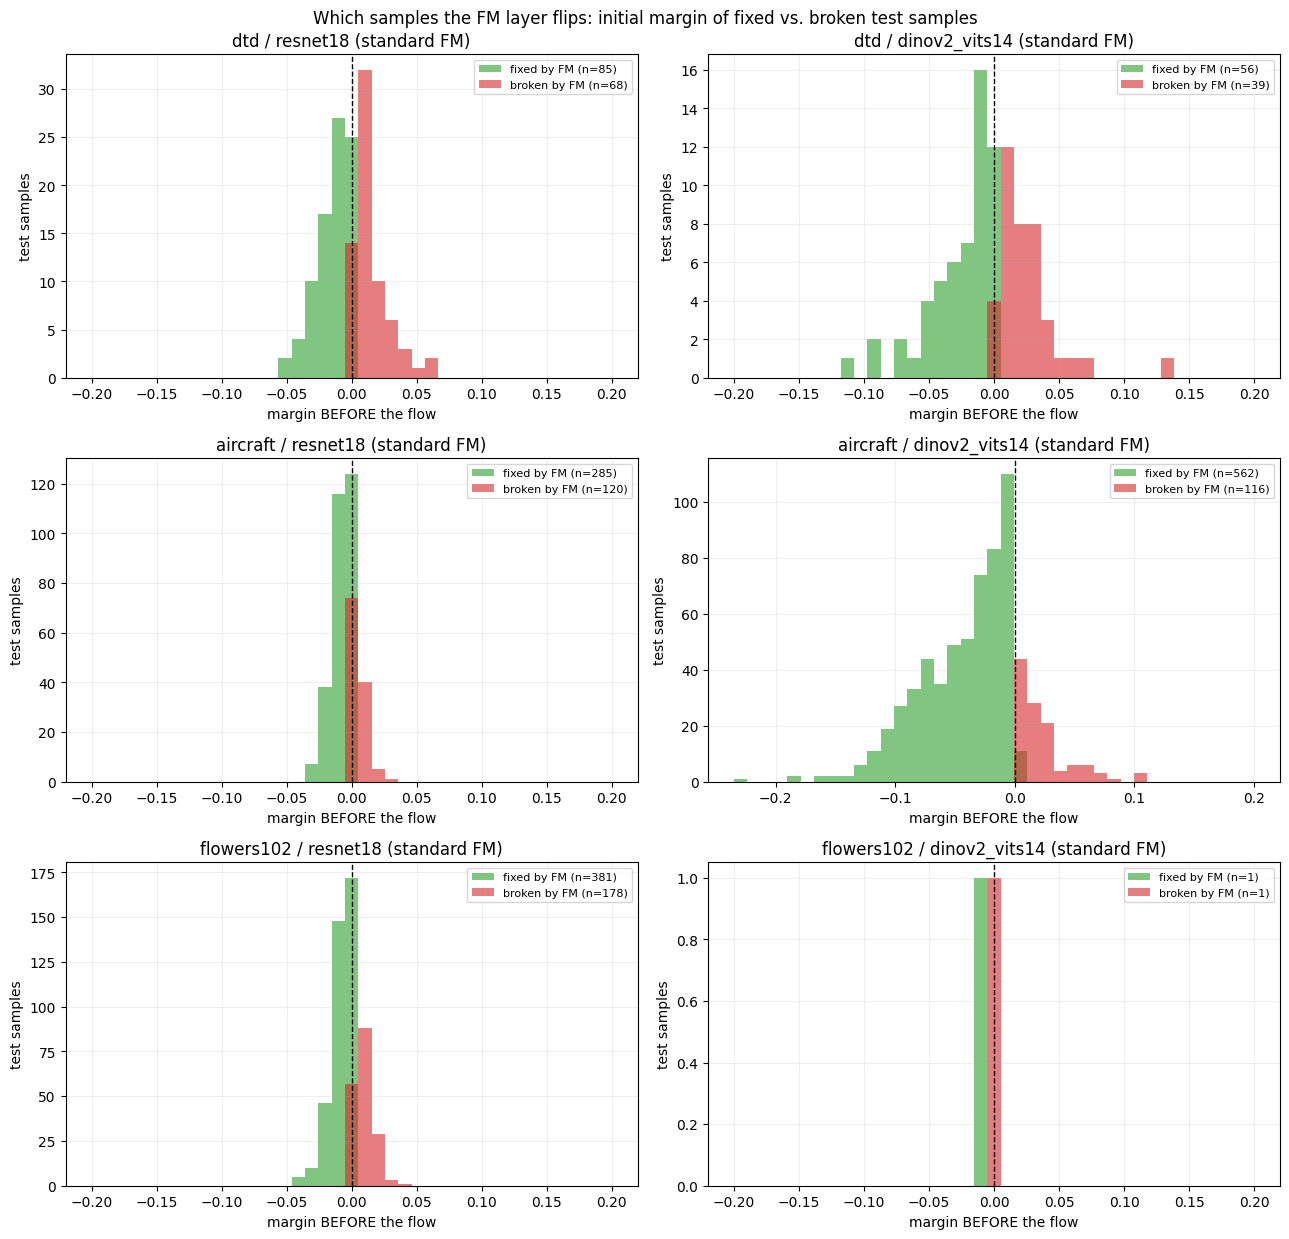

In [21]:
TRANSITION_SHOT, TRANSITION_SEED = INTERMEDIATE_SHOT, INTERMEDIATE_SEED

def prototype_margins(x, y, prototypes):
    """cos(z, p_true) - max over other classes of cos(z, p_c), per sample."""
    P = F.normalize(prototypes, dim=1)
    scores = F.normalize(x, dim=1) @ P.T
    true_score = scores.gather(1, y.view(-1, 1)).squeeze(1)
    masked = scores.clone(); masked.scatter_(1, y.view(-1, 1), float('-inf'))
    return (true_score - masked.max(1).values).cpu().numpy()

transition_rows, transition_margins = [], {}
for dataset_name, encoder_name in ENABLED_PAIRS:
    bank = feature_bank[(dataset_name, encoder_name)]['test']
    y_true = bank['labels'].numpy()
    x = F.normalize(bank['features'].float(), dim=1).to(DEVICE)
    y = bank['labels'].long().to(DEVICE)
    prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, TRANSITION_SHOT, TRANSITION_SEED)
    prototypes = prototypes.to(DEVICE)
    margin0 = prototype_margins(x, y, prototypes)

    base_dir = (STAGE1_PROTOTYPE_ROOT / 'runs' / dataset_name / encoder_name /
                TRANSITION_SHOT / f'seed_{TRANSITION_SEED}')
    base_pred = np.load(base_dir / 'test_predictions.npy')
    base_ok = base_pred == y_true

    for mode_tag, label in INTERMEDIATE_MODES:
        net = load_trained_network(dataset_name, encoder_name, TRANSITION_SHOT, TRANSITION_SEED,
                                   0, mode_tag, x.shape[1])
        _, fm_pred = evaluate_split(net, x, y, prototypes, INTERMEDIATE_T)
        fm_ok = fm_pred.numpy() == y_true
        fixed = ~base_ok & fm_ok
        broken = base_ok & ~fm_ok
        transition_rows.append(dict(
            dataset=dataset_name, encoder=encoder_name, model=label,
            both_correct=int((base_ok & fm_ok).sum()), fixed=int(fixed.sum()),
            broken=int(broken.sum()), both_wrong=int((~base_ok & ~fm_ok).sum()),
            net_gain=int(fixed.sum() - broken.sum()), n_test=len(y_true),
            net_gain_pp=100.0 * (fixed.sum() - broken.sum()) / len(y_true),
            mean_margin_fixed=float(margin0[fixed].mean()) if fixed.any() else float('nan'),
            mean_margin_broken=float(margin0[broken].mean()) if broken.any() else float('nan'),
            mean_margin_all=float(margin0.mean())))
        transition_margins[(dataset_name, encoder_name, mode_tag)] = dict(
            fixed=margin0[fixed], broken=margin0[broken], unchanged=margin0[~(fixed | broken)])

transitions = pd.DataFrame(transition_rows)
transitions.to_csv(OUTPUT_ROOT / 'confusion_transitions.csv', index=False)
print(f'Per-sample transitions at K={TRANSITION_SHOT}, seed {TRANSITION_SEED}, T={INTERMEDIATE_T}. '
      f'"fixed" = baseline wrong and FM correct; "broken" = the reverse. Top-1 gain is their difference.')
print('mean_margin_fixed/broken are the margins BEFORE the flow runs, so they say whether FM flips '
      'near-boundary samples (margin close to 0) or genuinely restructures confident mistakes.')
display(transitions.style.format({'net_gain_pp': '{:+.2f}', 'mean_margin_fixed': '{:+.4f}',
                                  'mean_margin_broken': '{:+.4f}', 'mean_margin_all': '{:+.4f}'}))

fig, axes = plt.subplots(len(DATASETS), max_encoders, figsize=(6.5 * max_encoders, 4.2 * len(DATASETS)),
                         squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        ax = axes[i, j]
        m = transition_margins[(dataset_name, encoder_name, 'standard')]
        bins = np.linspace(min(m['fixed'].min(initial=0.0), m['broken'].min(initial=0.0), -0.2),
                           max(m['fixed'].max(initial=0.0), m['broken'].max(initial=0.0), 0.2), 40)
        ax.hist(m['fixed'], bins=bins, alpha=.6, label=f'fixed by FM (n={len(m["fixed"])})', color='tab:green')
        ax.hist(m['broken'], bins=bins, alpha=.6, label=f'broken by FM (n={len(m["broken"])})', color='tab:red')
        ax.axvline(0, color='black', lw=1, ls='--')
        ax.set(title=f'{dataset_name} / {encoder_name} (standard FM)',
               xlabel='margin BEFORE the flow', ylabel='test samples')
        ax.legend(fontsize=8); ax.grid(alpha=.2)
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
        axes[i, j].axis('off')
fig.suptitle('Which samples the FM layer flips: initial margin of fixed vs. broken test samples')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'confusion_transitions.png', dpi=180, bbox_inches='tight'); plt.show()

## 16. Ablation: stopping the flow at a validation-selected time

Section 13's curves show accuracy peaking *before* `t=1` in several settings — DTD/ResNet-18 peaks around `t≈0.42` and then gives back roughly half its gain by `t=1`. Since the number of Euler steps actually taken is a free inference-time choice, that overshoot is recoverable.

**This is an ablation and is reported separately.** `ref/stage_2.pdf` specifies classifying `ẑ_T` after the full `T`-step sequence, and Section 8's required table continues to do exactly that. Nothing here changes the required result.

The selection is made honestly: `t*` is the argmax of accuracy on the **validation** split, frozen, and only then evaluated once on test. Reading a peak off the *test* curve and reporting it would be selecting on the test set, which is why the `oracle_best` column — the best any `t` could have achieved on test — is shown alongside as the unreachable upper bound rather than as a result. The gap between `test_at_tstar` and `oracle_best` is the honest cost of not being allowed to peek.

In [22]:
TSTAR_T = 12

def accuracy_by_step(net, x, y, prototypes, T, chunk=4096):
    """Top-1 accuracy at each of the T+1 Euler states, using the shared integrator."""
    net.eval()
    P = F.normalize(prototypes, dim=1)
    correct = np.zeros(T + 1)
    with torch.no_grad():
        for s in range(0, len(x), chunk):
            xb, yb = x[s:s + chunk], y[s:s + chunk]
            _, traj = euler_rollout(net, xb, T, return_trajectory=True)
            for k, z in enumerate(traj):
                correct[k] += float(((F.normalize(z, dim=1) @ P.T).argmax(1) == yb).sum().item())
    return correct / len(x)

TSTAR_MODES = [('standard', 'standard FM'), (f'rollout_T{TSTAR_T}', f'rolled-out FM (T={TSTAR_T})')]
tstar_rows = []
for dataset_name, encoder_name in tqdm(ENABLED_PAIRS, desc='validation-selected t*'):
    bank = feature_bank[(dataset_name, encoder_name)]
    x_val = F.normalize(bank['val']['features'].float(), dim=1).to(DEVICE)
    y_val = bank['val']['labels'].long().to(DEVICE)
    x_test = F.normalize(bank['test']['features'].float(), dim=1).to(DEVICE)
    y_test = bank['test']['labels'].long().to(DEVICE)
    for shot in SHOT_SETTINGS:
        reps = [(s, 0) for s in SUBSET_SEEDS] if shot != 'full' else [(None, s) for s in INIT_SEEDS]
        for subset_seed, init_seed in reps:
            proto_seed = subset_seed if shot != 'full' else 0
            prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, shot, proto_seed)
            prototypes = prototypes.to(DEVICE)
            for mode_tag, label in TSTAR_MODES:
                net = load_trained_network(dataset_name, encoder_name, shot, subset_seed, init_seed,
                                           mode_tag, x_val.shape[1])
                # t* is chosen on VALIDATION only. The test curve is computed for reporting, but the
                # index read out of it was fixed before test was touched - no test information
                # enters the choice.
                val_curve = accuracy_by_step(net, x_val, y_val, prototypes, TSTAR_T)
                k_star = int(val_curve.argmax())
                test_curve = accuracy_by_step(net, x_test, y_test, prototypes, TSTAR_T)
                tstar_rows.append(dict(
                    dataset=dataset_name, encoder=encoder_name, shot=str(shot), model=label,
                    seed=init_seed if shot == 'full' else subset_seed,
                    t_star=k_star / TSTAR_T, val_accuracy_at_tstar=float(val_curve[k_star]),
                    val_accuracy_at_t1=float(val_curve[-1]),
                    test_accuracy_at_tstar=float(test_curve[k_star]),
                    test_accuracy_at_t1=float(test_curve[-1]),
                    gain_from_early_stop=float(test_curve[k_star] - test_curve[-1]),
                    test_best_possible=float(test_curve.max())))

tstar_runs = pd.DataFrame(tstar_rows)
tstar_runs.to_csv(OUTPUT_ROOT / 'validation_selected_tstar_runs.csv', index=False)
tstar_summary = tstar_runs.groupby(['dataset', 'encoder', 'shot', 'model'], as_index=False).agg(
    mean_t_star=('t_star', 'mean'),
    test_at_t1=('test_accuracy_at_t1', 'mean'),
    test_at_tstar=('test_accuracy_at_tstar', 'mean'),
    gain=('gain_from_early_stop', 'mean'),
    gain_std=('gain_from_early_stop', 'std'),
    oracle_best=('test_best_possible', 'mean'))
tstar_summary['oracle_gap'] = tstar_summary.oracle_best - tstar_summary.test_at_tstar
tstar_summary.to_csv(OUTPUT_ROOT / 'validation_selected_tstar_summary.csv', index=False)

print('ABLATION - not part of the required Stage 2 table, which always classifies the final state z_T.')
print(f'Integration is stopped at t* = argmax of VALIDATION accuracy over the T={TSTAR_T} Euler grid,')
print('then test is evaluated once at that t*. "oracle_best" is the best the test curve could have')
print('reached at any t; the gap to it is the price of choosing t* honestly on validation.')
improved = int((tstar_summary.gain > 0).sum())
print(f'Early stopping the flow helps in {improved} of {len(tstar_summary)} conditions '
      f'(mean gain {tstar_summary.gain.mean():+.4f}, best {tstar_summary.gain.max():+.4f}).')
display(tstar_summary.sort_values('gain', ascending=False).style.format({
    'mean_t_star': '{:.3f}', 'test_at_t1': '{:.4f}', 'test_at_tstar': '{:.4f}',
    'gain': '{:+.4f}', 'gain_std': '{:.4f}', 'oracle_best': '{:.4f}', 'oracle_gap': '{:.4f}'}))

validation-selected t*:   0%|          | 0/6 [00:00<?, ?it/s]

ABLATION - not part of the required Stage 2 table, which always classifies the final state z_T.
Integration is stopped at t* = argmax of VALIDATION accuracy over the T=12 Euler grid,
then test is evaluated once at that t*. "oracle_best" is the best the test curve could have
reached at any t; the gap to it is the price of choosing t* honestly on validation.
Early stopping the flow helps in 18 of 36 conditions (mean gain +0.0018, best +0.0303).


,dataset,encoder,shot,model,mean_t_star,test_at_t1,test_at_tstar,gain,gain_std,oracle_best,oracle_gap
22,dtd,resnet18,full,rolled-out FM (T=12),0.556,0.5672,0.5975,+0.0303,0.0207,0.6009,0.0034
4,aircraft,dinov2_vits14,full,rolled-out FM (T=12),0.806,0.5392,0.5537,+0.0145,0.0014,0.5574,0.0037
18,dtd,resnet18,10,rolled-out FM (T=12),0.750,0.5369,0.5410,+0.0041,0.0034,0.5440,0.0030
0,aircraft,dinov2_vits14,10,rolled-out FM (T=12),0.917,0.4351,0.4391,+0.0040,0.0030,0.4404,0.0013
10,aircraft,resnet18,full,rolled-out FM (T=12),0.806,0.3112,0.3145,+0.0033,0.0031,0.3193,0.0048
34,flowers102,resnet18,full,rolled-out FM (T=12),0.722,0.7777,0.7801,+0.0024,0.0035,0.7813,0.0012
19,dtd,resnet18,10,standard FM,0.778,0.5417,0.5438,+0.0021,0.0023,0.5461,0.0023
23,dtd,resnet18,full,standard FM,0.944,0.5926,0.5941,+0.0016,0.0016,0.6046,0.0105
16,dtd,dinov2_vits14,full,rolled-out FM (T=12),0.833,0.7580,0.7596,+0.0016,0.0028,0.7642,0.0046
20,dtd,resnet18,5,rolled-out FM (T=12),0.778,0.4672,0.4684,+0.0012,0.0013,0.4700,0.0016


## 17. Quantitative geometry: contraction or discrimination?

Section 13 measures every intermediate state against the sample's *own* prototype — accuracy, margin, cosine and L2 distance to `p_true`. Those quantities share a blind spot: all of them improve whenever the flow contracts toward the prototype set, whether or not it makes the classes any easier to tell apart. Section 13's own table already shows the tension, with `cos_to_true` rising on every dataset while the margin *falls* on DTD and Flowers.

This section measures the class structure directly, at every Euler state:

- `s_other(t)` — mean cosine to the nearest **competing** prototype.
- `W(t)` — within-class scatter, mean squared distance to the class centroid at time `t`.
- `B(t)` — between-class separation, mean squared distance between class centroids.
- `W(t)/B(t)` — the discriminative quantity. A flow that merely drags everything inward shrinks `W` and `B` together and leaves the ratio flat. A flow that genuinely separates classes drives it down.

Plotting `W/B` against accuracy on the same axes is the most direct answer this notebook gives to the specification's third goal, *study how the learned transformation changes the geometry of the feature space*. It is computed with the shared `euler_rollout` over the complete test split, so these are exactly the states inference produces.

flow geometry:   0%|          | 0/6 [00:00<?, ?it/s]

W(t)/B(t) is the quantity that separates real discrimination from indiscriminate contraction:
  a flow that only drags everything inward shrinks W and B together and leaves the ratio flat;
  a flow that separates classes drives it down. Compare ratio_change against accuracy_gain.


,dataset,encoder,model,within_t0,within_t1,between_t0,between_t1,ratio_t0,ratio_t1,ratio_change,cos_true_t1,cos_other_t1,accuracy_gain
0,dtd,resnet18,standard FM,0.4234,0.3095,0.2639,0.2400,1.6045,1.2896,-0.3149,0.8186,0.8151,0.0090
1,dtd,resnet18,rolled-out FM (T=12),0.4234,0.2898,0.2639,0.1908,1.6045,1.5186,-0.0859,0.8143,0.8115,0.0043
2,dtd,dinov2_vits14,standard FM,0.6244,0.6166,0.5977,0.8347,1.0447,0.7387,-0.3059,0.6387,0.5277,0.0090
3,dtd,dinov2_vits14,rolled-out FM (T=12),0.6244,0.5131,0.5977,0.6269,1.0447,0.8185,-0.2262,0.6264,0.5236,0.0032
4,aircraft,resnet18,standard FM,0.1848,0.0897,0.0736,0.0500,2.5095,1.7937,-0.7158,0.9419,0.9491,0.0495
5,aircraft,resnet18,rolled-out FM (T=12),0.1848,0.1211,0.0736,0.0500,2.5095,2.4244,-0.0852,0.9269,0.9340,0.0318
6,aircraft,dinov2_vits14,standard FM,0.4422,0.1628,0.6338,0.8816,0.6978,0.1846,-0.5131,0.8831,0.8919,0.1338
7,aircraft,dinov2_vits14,rolled-out FM (T=12),0.4422,0.1047,0.6338,0.8488,0.6978,0.1234,-0.5744,0.9069,0.9118,0.1482
8,flowers102,resnet18,standard FM,0.1898,0.1151,0.2453,0.2047,0.7737,0.5621,-0.2116,0.9296,0.9099,0.0330
9,flowers102,resnet18,rolled-out FM (T=12),0.1898,0.1296,0.2453,0.1785,0.7737,0.7259,-0.0479,0.9187,0.9009,0.0307


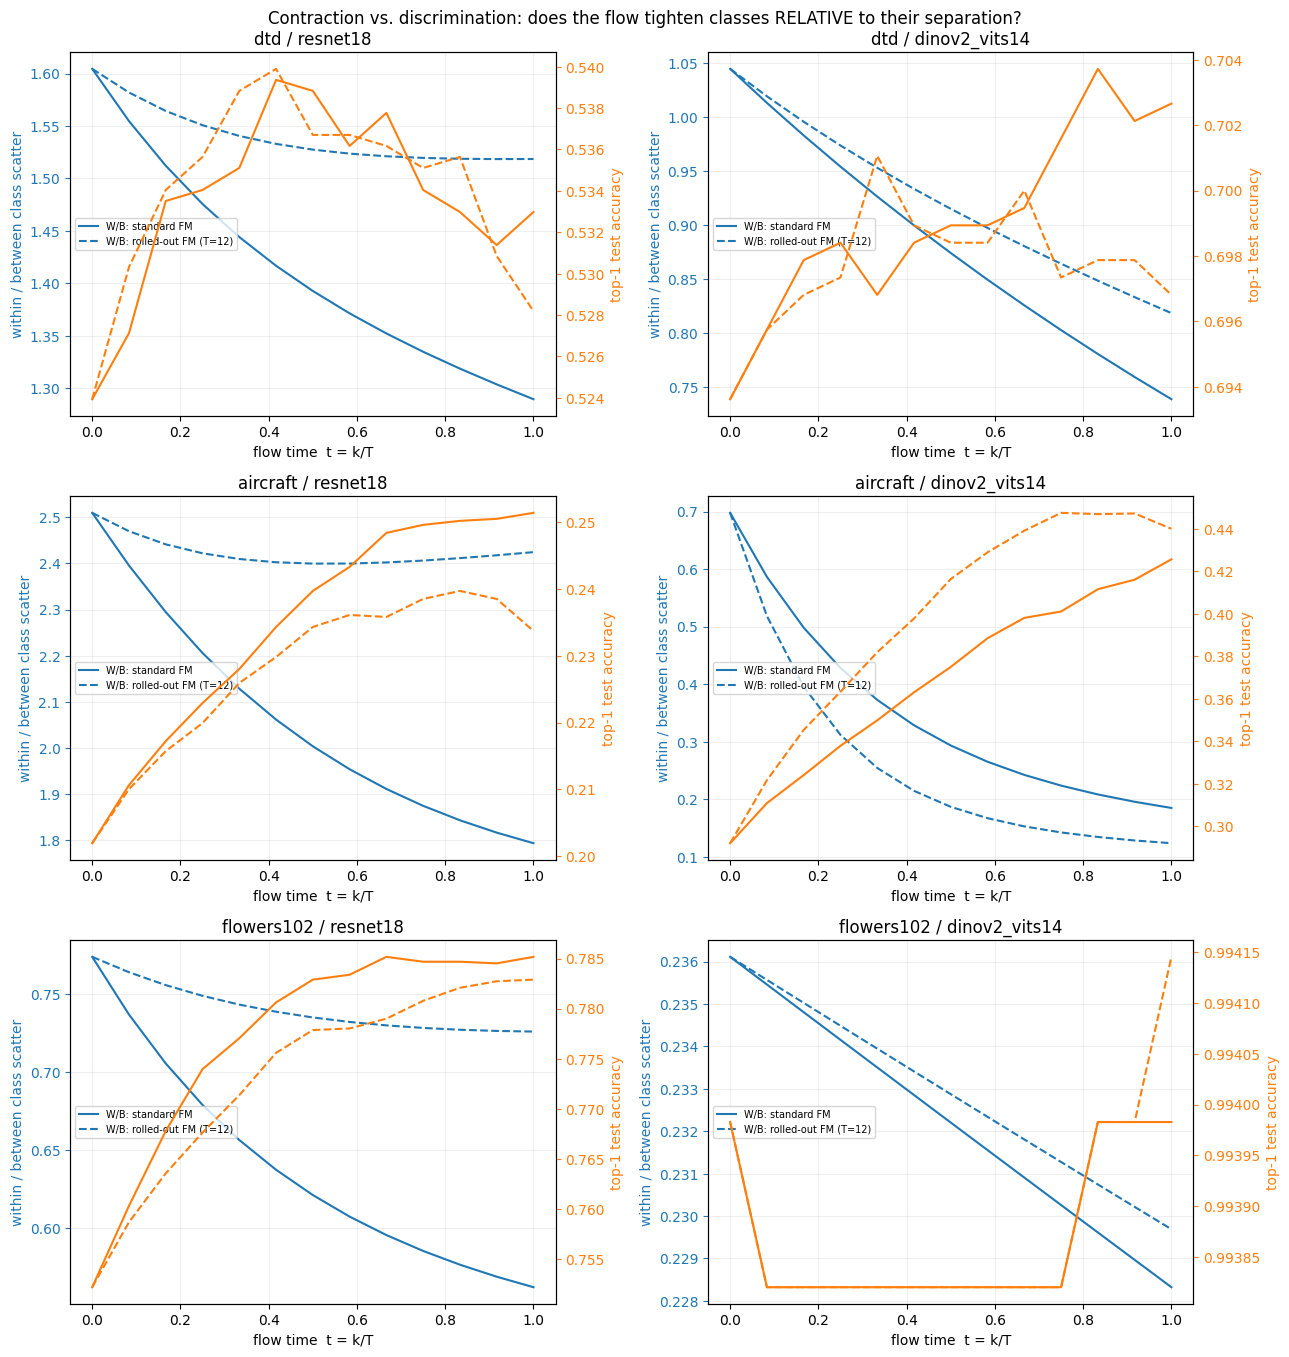

In [23]:
def flow_geometry_over_time(net, x, y, prototypes, T, chunk=2048):
    """Class-level geometry of the transported cloud at every Euler state.

    Section 13 tracks per-sample quantities against the sample's OWN prototype: accuracy, margin,
    cosine and L2 distance to `p_true`. Every one of those improves whenever the flow contracts
    toward the prototype set, whether or not it makes the classes any more separable. The three
    quantities added here are what tell the two apart:

      s_other   mean cosine to the nearest COMPETING prototype
      within    within-class scatter W(t): mean squared distance to the class centroid at time t
      between   between-class separation B(t): mean squared distance between class centroids
      ratio     W(t)/B(t) - the discriminative quantity. A flow that merely drags everything
                inward shrinks W and B together and leaves the ratio flat; a flow that actually
                separates classes drives the ratio down.

    Uses the shared `euler_rollout`, so these are exactly the states inference produces.
    """
    net.eval()
    P = F.normalize(prototypes, dim=1)
    n_steps, n_classes, dim = T + 1, prototypes.shape[0], x.shape[1]
    s_other = np.zeros(n_steps)
    sum_z = torch.zeros(n_steps, n_classes, dim, device=DEVICE)
    sum_sq = torch.zeros(n_steps, device=DEVICE)
    counts = torch.zeros(n_classes, device=DEVICE)
    with torch.no_grad():
        for s in range(0, len(x), chunk):
            xb, yb = x[s:s + chunk], y[s:s + chunk]
            counts += torch.bincount(yb, minlength=n_classes).float()
            _, traj = euler_rollout(net, xb, T, return_trajectory=True)
            for k, z in enumerate(traj):
                scores = F.normalize(z, dim=1) @ P.T
                masked = scores.clone(); masked.scatter_(1, yb.view(-1, 1), float('-inf'))
                s_other[k] += float(masked.max(1).values.sum().item())
                sum_z[k].index_add_(0, yb, z)
                sum_sq[k] += float((z * z).sum().item())
    n = len(x)
    present = counts > 0
    rows = []
    for k in range(n_steps):
        mu = sum_z[k][present] / counts[present].unsqueeze(1)
        c = mu.shape[0]
        # W = (1/N)(sum_i ||z_i||^2 - sum_c n_c ||mu_c||^2)
        within = float((sum_sq[k] - (counts[present] * (mu * mu).sum(1)).sum()).item() / n)
        # sum_{c,c'} ||mu_c - mu_c'||^2 = 2c*sum_c||mu_c||^2 - 2||sum_c mu_c||^2 (diagonal adds 0)
        sq = float((mu * mu).sum().item()); tot = float((mu.sum(0) ** 2).sum().item())
        between = (2 * c * sq - 2 * tot) / (c * (c - 1)) if c > 1 else float('nan')
        rows.append(dict(step=k, t=k / T, cosine_to_nearest_other=s_other[k] / n,
                         within_class_scatter=within, between_class_separation=between,
                         within_over_between=within / between if between else float('nan')))
    return pd.DataFrame(rows)

geometry_curves, geometry_rows = {}, []
for dataset_name, encoder_name in tqdm(ENABLED_PAIRS, desc='flow geometry'):
    bank = feature_bank[(dataset_name, encoder_name)]['test']
    x = F.normalize(bank['features'].float(), dim=1).to(DEVICE)
    y = bank['labels'].long().to(DEVICE)
    prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED)
    prototypes = prototypes.to(DEVICE)
    for mode_tag, label in INTERMEDIATE_MODES:
        net = load_trained_network(dataset_name, encoder_name, INTERMEDIATE_SHOT, INTERMEDIATE_SEED,
                                   0, mode_tag, x.shape[1])
        curve = flow_geometry_over_time(net, x, y, prototypes, INTERMEDIATE_T)
        geometry_curves[(dataset_name, encoder_name, mode_tag)] = curve
        base = flow_time_curves[(dataset_name, encoder_name, mode_tag)]
        geometry_rows.append(dict(
            dataset=dataset_name, encoder=encoder_name, model=label,
            within_t0=curve.within_class_scatter.iloc[0], within_t1=curve.within_class_scatter.iloc[-1],
            between_t0=curve.between_class_separation.iloc[0], between_t1=curve.between_class_separation.iloc[-1],
            ratio_t0=curve.within_over_between.iloc[0], ratio_t1=curve.within_over_between.iloc[-1],
            ratio_change=curve.within_over_between.iloc[-1] - curve.within_over_between.iloc[0],
            cos_true_t1=base.cosine_to_true_prototype.iloc[-1],
            cos_other_t1=curve.cosine_to_nearest_other.iloc[-1],
            accuracy_gain=base.accuracy.iloc[-1] - base.accuracy.iloc[0]))

geometry_summary = pd.DataFrame(geometry_rows)
geometry_summary.to_csv(OUTPUT_ROOT / 'flow_geometry_summary.csv', index=False)
print('W(t)/B(t) is the quantity that separates real discrimination from indiscriminate contraction:')
print('  a flow that only drags everything inward shrinks W and B together and leaves the ratio flat;')
print('  a flow that separates classes drives it down. Compare ratio_change against accuracy_gain.')
display(geometry_summary.style.format({c: '{:.4f}' for c in geometry_summary.columns if c not in
                                       ('dataset', 'encoder', 'model')}))

fig, axes = plt.subplots(len(DATASETS), max_encoders, figsize=(6.5 * max_encoders, 4.6 * len(DATASETS)),
                         squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        ax = axes[i, j]; twin = ax.twinx()
        for (mode_tag, label), style in zip(INTERMEDIATE_MODES, ['-', '--']):
            g = geometry_curves[(dataset_name, encoder_name, mode_tag)]
            b = flow_time_curves[(dataset_name, encoder_name, mode_tag)]
            ax.plot(g.t, g.within_over_between, style, color='tab:blue', label=f'W/B: {label}')
            twin.plot(b.t, b.accuracy, style, color='tab:orange', label=f'accuracy: {label}')
        ax.set(title=f'{dataset_name} / {encoder_name}', xlabel='flow time  t = k/T')
        ax.set_ylabel('within / between class scatter', color='tab:blue')
        twin.set_ylabel('top-1 test accuracy', color='tab:orange')
        ax.tick_params(axis='y', colors='tab:blue'); twin.tick_params(axis='y', colors='tab:orange')
        ax.grid(alpha=.2); ax.legend(fontsize=7, loc='center left')
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
        axes[i, j].axis('off')
fig.suptitle('Contraction vs. discrimination: does the flow tighten classes RELATIVE to their separation?')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'flow_geometry_vs_time.png', dpi=180, bbox_inches='tight'); plt.show()

## 18. Ablation: how many Euler steps does the gain actually need?

Section 8 shows `T=4` and `T=12` landing within a point of each other in every setting, with the largest difference favouring the *cheaper* one. That makes the interesting question the other direction: how far down can `T` go before the gain disappears?

**The required table keeps `T ∈ {4, 12}` exactly as specified.** This is an inference-only ablation on top of it, and it applies to **standard FM only** — its training objective has no `T`, so one trained network is legitimately integrable with any number of steps. Rolled-out networks are deliberately excluded: `T` is part of their training objective, so evaluating one at a `T` it was never trained for would be meaningless, which is the same asymmetry Section 7 enforces.

`frac_at_T1` and `frac_at_T2` report what fraction of the `T=12` gain is already present after one or two velocity evaluations. If most of it is, the computational story changes.

inference-step ablation:   0%|          | 0/6 [00:00<?, ?it/s]

ABLATION - the required table keeps T in {4, 12}, exactly as the specification asks.
Standard FM only: its loss has no T dependence, so one trained network can be integrated with
any number of steps. Rolled-out networks are excluded because T is part of their objective.
Columns 1..12 are dAcc against the matching Stage 1 baseline at that step count.


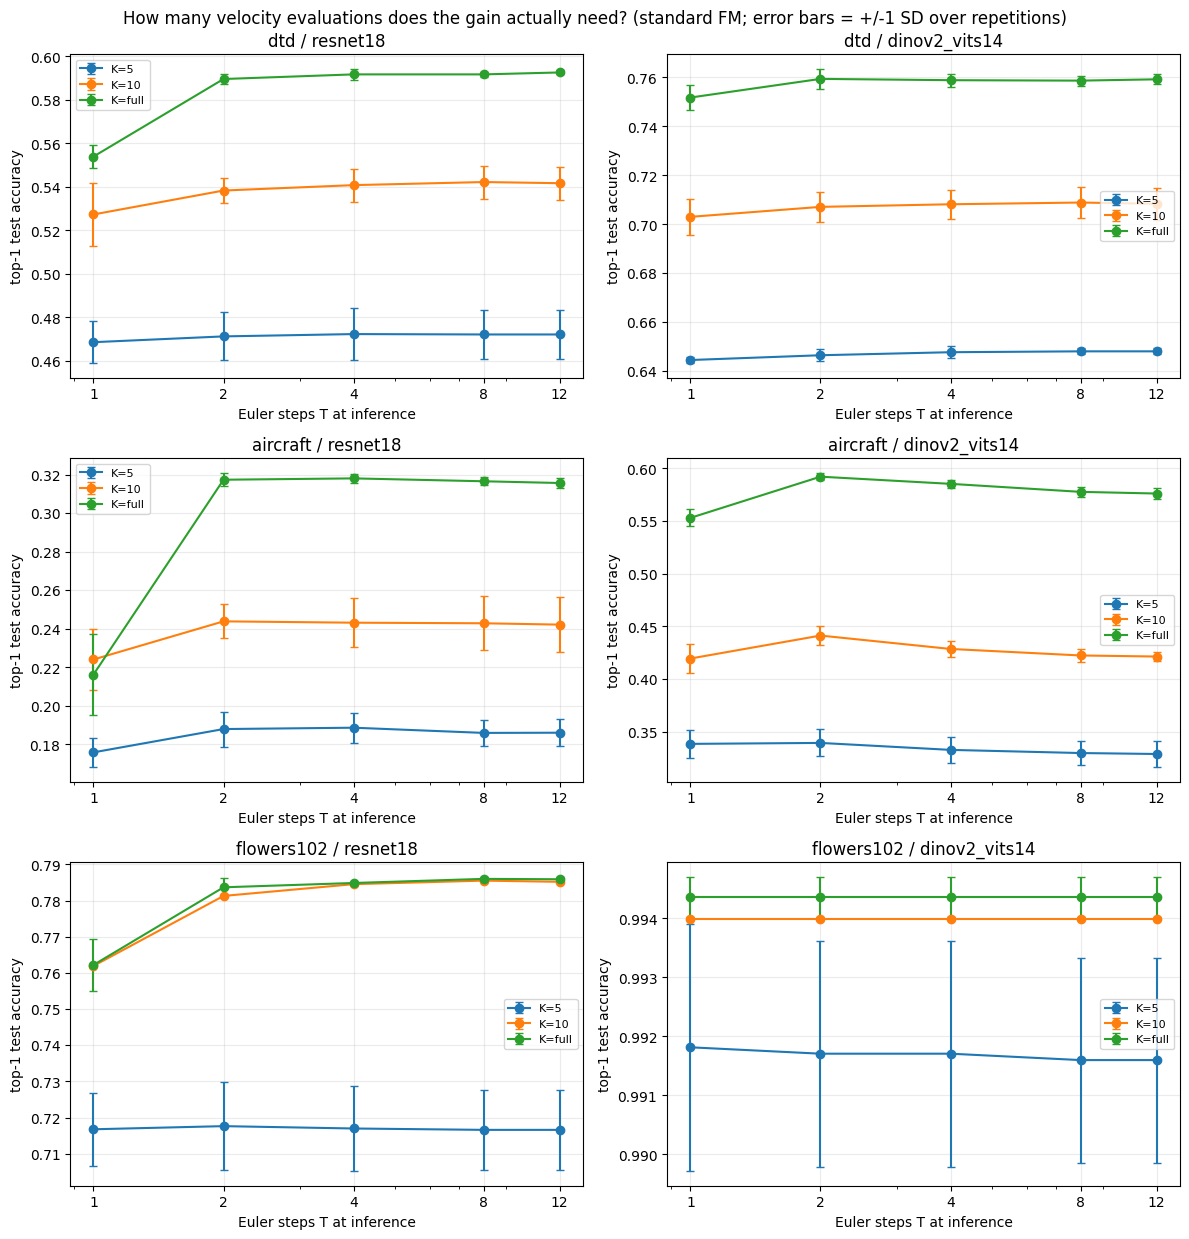

In [24]:
STEP_ABLATION_T = [1, 2, 4, 8, 12]

step_rows = []
for dataset_name, encoder_name in tqdm(ENABLED_PAIRS, desc='inference-step ablation'):
    bank = feature_bank[(dataset_name, encoder_name)]['test']
    x = F.normalize(bank['features'].float(), dim=1).to(DEVICE)
    y = bank['labels'].long().to(DEVICE)
    for shot in SHOT_SETTINGS:
        reps = [(s, 0) for s in SUBSET_SEEDS] if shot != 'full' else [(None, s) for s in INIT_SEEDS]
        for subset_seed, init_seed in reps:
            proto_seed = subset_seed if shot != 'full' else 0
            prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, shot, proto_seed)
            prototypes = prototypes.to(DEVICE)
            # Standard FM only: its objective has no T, so a single trained network is legitimately
            # evaluable at any step count. A rolled-out network is NOT - T is baked into its training
            # objective - so running one here at a T it was never trained for would be meaningless.
            net = load_trained_network(dataset_name, encoder_name, shot, subset_seed, init_seed,
                                       'standard', x.shape[1])
            baseline_acc = json.loads((STAGE1_PROTOTYPE_ROOT / 'runs' / dataset_name / encoder_name /
                                       str(shot) / f'seed_{proto_seed}' / 'metrics.json').read_text())['test_accuracy']
            for T in STEP_ABLATION_T:
                acc, _ = evaluate_split(net, x, y, prototypes, T)
                step_rows.append(dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot),
                                      seed=init_seed if shot == 'full' else subset_seed, T=T,
                                      test_accuracy=acc, baseline_accuracy=baseline_acc,
                                      delta=acc - baseline_acc))

step_runs = pd.DataFrame(step_rows)
step_runs.to_csv(OUTPUT_ROOT / 'inference_step_ablation_runs.csv', index=False)
step_summary = step_runs.groupby(['dataset', 'encoder', 'shot', 'T'], as_index=False).agg(
    mean_accuracy=('test_accuracy', 'mean'), std_accuracy=('test_accuracy', 'std'),
    mean_delta=('delta', 'mean'))
step_pivot = step_summary.pivot_table(index=['dataset', 'encoder', 'shot'], columns='T',
                                      values='mean_delta')
# what fraction of the T=12 gain is already there after a single velocity evaluation?
step_pivot['frac_at_T1'] = step_pivot[1] / step_pivot[12].replace(0, np.nan)
step_pivot['frac_at_T2'] = step_pivot[2] / step_pivot[12].replace(0, np.nan)
step_summary.to_csv(OUTPUT_ROOT / 'inference_step_ablation_summary.csv', index=False)

print('ABLATION - the required table keeps T in {4, 12}, exactly as the specification asks.')
print('Standard FM only: its loss has no T dependence, so one trained network can be integrated with')
print('any number of steps. Rolled-out networks are excluded because T is part of their objective.')
print('Columns 1..12 are dAcc against the matching Stage 1 baseline at that step count.')
display(step_pivot.style.format('{:+.4f}', subset=[1, 2, 4, 8, 12])
        .format({'frac_at_T1': '{:.2f}', 'frac_at_T2': '{:.2f}'}))

fig, axes = plt.subplots(len(DATASETS), max_encoders, figsize=(6.0 * max_encoders, 4.2 * len(DATASETS)),
                         squeeze=False)
for i, dataset_name in enumerate(DATASETS):
    for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        ax = axes[i, j]
        for shot in SHOT_SETTINGS:
            row = step_summary[(step_summary.dataset == dataset_name) &
                               (step_summary.encoder == encoder_name) &
                               (step_summary.shot == str(shot))].sort_values('T')
            ax.errorbar(row['T'], row.mean_accuracy, yerr=row.std_accuracy.fillna(0), marker='o',
                        capsize=3, label=f'K={shot}')
        ax.set(title=f'{dataset_name} / {encoder_name}', xlabel='Euler steps T at inference',
               ylabel='top-1 test accuracy', xscale='log', xticks=STEP_ABLATION_T)
        ax.set_xticklabels([str(t) for t in STEP_ABLATION_T])
        ax.grid(alpha=.25); ax.legend(fontsize=8)
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
        axes[i, j].axis('off')
fig.suptitle('How many velocity evaluations does the gain actually need? (standard FM; error bars = +/-1 SD over repetitions)')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'inference_step_ablation.png', dpi=180, bbox_inches='tight'); plt.show()

## 19. Control experiment: is it flow matching, or just another MLP?

This is the experiment the accuracy table cannot settle on its own. The FM layer adds a trained network with roughly a million parameters to a previously closed-form classifier, so before attributing +24 points on Aircraft/DINOv2 to *flow matching*, the cheaper explanations have to be ruled out. Two controls, both **outside** the required Stage 2 comparison and written to their own `controls/` tree:

- **Direct MLP endpoint regression** — `g(z) ≈ p_y`, trained on `‖g(z) − p_y‖²`. No time input, no path, no integration. This isolates *having a supervised nonlinear map into prototype space*.
- **Repeated residual** — `z_{k+1} = z_k + (1/T)·f(z_k)`, the same shared network applied the same `T` times as FM, trained only on the endpoint. This keeps iterative shared computation but removes the time conditioning and the per-`t` velocity supervision.

Everything else is held fixed: same hidden architecture (`d → 512 → 512 → d`, SiLU), same optimizer, schedule, early stopping, checkpoint rule, subsets and seeds. Reading the three columns together separates the explanations — if `direct` already matches FM, the gain is capacity; if `residual` matches but `direct` does not, it is iterative computation; only if FM beats both is time-conditioned path supervision doing the work.

Training cost is small (the same seconds-per-network as the main grid), so this is cheap insurance on the headline claim.

In [25]:
CONTROL_ROOT = OUTPUT_ROOT / 'controls'
CONTROL_T = 12
FORCE_RETRAIN_CONTROLS = False
CONTROL_KINDS = [('direct', 'direct MLP  g(z) -> p_y'),
                 ('residual', f'repeated residual  (T={CONTROL_T}, no t)')]

class ControlNet(nn.Module):
    """Identical width, depth and activation to VelocityNet - only the time input is removed."""
    def __init__(self, feature_dim, hidden_dim, num_hidden_layers):
        super().__init__()
        layers = []
        in_dim = feature_dim
        for _ in range(num_hidden_layers):
            layers += [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, feature_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)

def control_forward(net, z, kind, T=CONTROL_T):
    """'direct' predicts the prototype in one shot; 'residual' takes the same T shared-weight steps
    as FM but with no time conditioning, so it isolates iterative computation from flow matching."""
    if kind == 'direct':
        return net(z)
    out = z
    for _ in range(T):
        out = out + (1.0 / T) * net(out)
    return out

def train_control(kind, x_train, y_train, prototypes, x_val, y_val, run_dir, init_seed):
    seed_everything(init_seed)
    feature_dim = x_train.shape[1]
    net = ControlNet(feature_dim, FM['hidden_dim'], FM['num_hidden_layers']).to(DEVICE)
    optimizer = torch.optim.AdamW(net.parameters(), lr=FM['learning_rate'], weight_decay=FM['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=FM['lr_patience'])
    best_acc, best_state, stale, history = -1.0, None, 0, []
    n_train = x_train.shape[0]
    started = time.perf_counter()
    for epoch in range(1, FM['max_epochs'] + 1):
        generator = torch.Generator().manual_seed(init_seed * 100000 + epoch)
        perm = torch.randperm(n_train, generator=generator)
        net.train(); total = 0.0
        for start in range(0, n_train, FM['batch_size']):
            batch_idx = perm[start:start + FM['batch_size']]
            zb, pb = x_train[batch_idx], prototypes[y_train[batch_idx]]
            optimizer.zero_grad(set_to_none=True)
            loss = F.mse_loss(control_forward(net, zb, kind), pb)
            loss.backward(); optimizer.step()
            total += loss.item() * len(batch_idx)
        net.eval()
        with torch.no_grad():
            pred, _ = classify_cosine(control_forward(net, x_val, kind), prototypes)
            val_acc = (pred == y_val).float().mean().item()
        history.append(dict(epoch=epoch, train_loss=total / n_train, val_accuracy=val_acc))
        if val_acc > best_acc + FM['min_delta']:
            best_acc, best_state, stale = val_acc, copy.deepcopy(net.state_dict()), 0
        else:
            stale += 1
        scheduler.step(val_acc)
        if stale >= FM['early_stopping_patience']:
            break
    if best_state is None:
        best_state = copy.deepcopy(net.state_dict())
    net.load_state_dict(best_state); net.eval()
    run_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(history).to_csv(run_dir / 'history.csv', index=False)
    torch.save(dict(model_state_dict=best_state, kind=kind, T=CONTROL_T,
                    best_val_accuracy=best_acc), run_dir / 'best.pt')
    return net, best_acc, time.perf_counter() - started

control_rows = []
for dataset_name, encoder_name in tqdm(ENABLED_PAIRS, desc='non-FM controls'):
    bank = feature_bank[(dataset_name, encoder_name)]
    x_train_all, y_train_all = bank['train']['features'].float(), bank['train']['labels'].long()
    x_val = F.normalize(bank['val']['features'].float(), dim=1).to(DEVICE)
    y_val = bank['val']['labels'].long().to(DEVICE)
    x_test = F.normalize(bank['test']['features'].float(), dim=1).to(DEVICE)
    y_test = bank['test']['labels'].long().to(DEVICE)
    for shot in SHOT_SETTINGS:
        reps = [(s, 0) for s in SUBSET_SEEDS] if shot != 'full' else [(None, s) for s in INIT_SEEDS]
        for subset_seed, init_seed in reps:
            if shot != 'full':
                idx = torch.as_tensor(balanced_indices(y_train_all.numpy(), int(shot), subset_seed))
                xs, ys = x_train_all[idx], y_train_all[idx]
            else:
                xs, ys = x_train_all, y_train_all
            x_train = F.normalize(xs, dim=1).to(DEVICE); y_train = ys.to(DEVICE)
            proto_seed = subset_seed if shot != 'full' else 0
            prototypes, _ = load_stage1_prototypes(dataset_name, encoder_name, shot, proto_seed)
            prototypes = prototypes.to(DEVICE)
            run_tag = f'subset_{subset_seed}__init_{init_seed}'
            for kind, label in CONTROL_KINDS:
                run_dir = CONTROL_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / kind / run_tag
                metrics_path = run_dir / 'metrics.json'
                if metrics_path.exists() and not FORCE_RETRAIN_CONTROLS:
                    control_rows.append(json.loads(metrics_path.read_text())); continue
                net, best_val, runtime = train_control(kind, x_train, y_train, prototypes,
                                                       x_val, y_val, run_dir, init_seed)
                with torch.no_grad():
                    pred, _ = classify_cosine(control_forward(net, x_test, kind), prototypes)
                    test_acc = (pred == y_test).float().mean().item()
                np.save(run_dir / 'test_predictions.npy', pred.cpu().numpy())
                metrics = dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot),
                               subset_seed=subset_seed, init_seed=init_seed, control=kind,
                               control_label=label, best_val_accuracy=best_val,
                               test_accuracy=test_acc, runtime_seconds=runtime)
                metrics_path.write_text(json.dumps(metrics, indent=2))
                control_rows.append(metrics)

controls_df = pd.DataFrame(control_rows)
controls_df.to_csv(CONTROL_ROOT / 'run_metrics.csv', index=False)
control_summary = controls_df.groupby(['dataset', 'encoder', 'shot', 'control'], as_index=False).agg(
    mean_accuracy=('test_accuracy', 'mean'), std_accuracy=('test_accuracy', 'std'))
control_pivot = control_summary.pivot_table(index=['dataset', 'encoder', 'shot'], columns='control',
                                            values='mean_accuracy')

best_fm = (fm_summary.groupby(['dataset', 'encoder', 'shot'], as_index=False)
           .agg(best_fm_accuracy=('mean_accuracy', 'max')))
control_comparison = (control_pivot.reset_index()
                      .merge(best_fm, on=['dataset', 'encoder', 'shot'], how='left')
                      .merge(baseline_summary[['dataset', 'encoder', 'shot', 'baseline_mean_accuracy']],
                             on=['dataset', 'encoder', 'shot'], how='left'))
control_comparison['fm_over_direct'] = control_comparison.best_fm_accuracy - control_comparison['direct']
control_comparison['fm_over_residual'] = control_comparison.best_fm_accuracy - control_comparison['residual']
control_comparison.to_csv(CONTROL_ROOT / 'fm_vs_controls.csv', index=False)

wins = int((control_comparison[['fm_over_direct', 'fm_over_residual']].min(axis=1) > 0).sum())
print('CONTROL EXPERIMENT - not part of the required Stage 2 comparison, which remains')
print('Stage 1 prototype vs. standard FM vs. rolled-out FM.')
print('Both controls use the same hidden architecture, optimizer, schedule, early stopping,')
print('subsets and seeds as FM. "direct" removes the flow entirely; "residual" keeps the T shared-')
print('weight steps but removes the time conditioning and the per-t velocity supervision.')
print(f'FM beats BOTH controls in {wins} of {len(control_comparison)} settings.')
display(control_comparison.style.format({c: '{:.4f}' for c in
        ['direct', 'residual', 'best_fm_accuracy', 'baseline_mean_accuracy']}
        ).format({'fm_over_direct': '{:+.4f}', 'fm_over_residual': '{:+.4f}'}))

non-FM controls:   0%|          | 0/6 [00:00<?, ?it/s]

CONTROL EXPERIMENT - not part of the required Stage 2 comparison, which remains
Stage 1 prototype vs. standard FM vs. rolled-out FM.
Both controls use the same hidden architecture, optimizer, schedule, early stopping,
subsets and seeds as FM. "direct" removes the flow entirely; "residual" keeps the T shared-
weight steps but removes the time conditioning and the per-t velocity supervision.
FM beats BOTH controls in 16 of 18 settings.


,dataset,encoder,shot,direct,residual,best_fm_accuracy,baseline_mean_accuracy,fm_over_direct,fm_over_residual
0,aircraft,dinov2_vits14,10,0.428343,0.434443,0.435144,0.278128,+0.0068,+0.0007
1,aircraft,dinov2_vits14,5,0.334833,0.344234,0.343034,0.232623,+0.0082,-0.0012
2,aircraft,dinov2_vits14,full,0.578258,0.543154,0.585158,0.342334,+0.0069,+0.0420
3,aircraft,resnet18,10,0.205221,0.237424,0.243124,0.198520,+0.0379,+0.0057
4,aircraft,resnet18,5,0.160616,0.177018,0.188619,0.160416,+0.0280,+0.0116
5,aircraft,resnet18,full,0.258826,0.308931,0.318032,0.252025,+0.0592,+0.0091
6,dtd,dinov2_vits14,10,0.687411,0.703191,0.708333,0.693794,+0.0209,+0.0051
7,dtd,dinov2_vits14,5,0.625177,0.643972,0.648050,0.642553,+0.0229,+0.0041
8,dtd,dinov2_vits14,full,0.755142,0.753723,0.759220,0.726596,+0.0041,+0.0055
9,dtd,resnet18,10,0.485461,0.535993,0.541667,0.533688,+0.0562,+0.0057


## 20. Context: the other Stage 1 baseline

The required comparison is FM against the Stage 1 **prototype** classifier, and Section 8 makes it. But Stage 1 also produced a **linear probe** on the very same frozen features (`01_linear_probe.ipynb`), and it is the natural yardstick for what a trained discriminative head can extract from these representations.

Framing the FM layer as *closing a fraction of the prototype → probe gap* is more informative than ΔAcc alone: it says how much of the accessible headroom the layer recovers, and where it runs out. The shaded band in the figure is that gap.

**This is context, not a Stage 2 deliverable.** It changes nothing about the required table, and the linear probe is not an FM variant — it is a different Stage 1 baseline, trained on the same images with a different hypothesis class.

CONTEXT ONLY - the required Stage 2 comparison is against the Stage 1 *prototype* baseline,
which Section 8 reports. The linear probe is the other Stage 1 baseline (01_linear_probe.ipynb)
and is shown here because it is the obvious question: how much of the gap between a frozen
prototype rule and a trained discriminative head does the FM layer actually recover?
FM beats the linear probe in 4 of 18 settings; median gap closed 46%.


,dataset,encoder,shot,flow_matching,prototype,linear_probe,fm_gain,gap_closed,winner
0,aircraft,dinov2_vits14,10,0.4351,0.2781,0.5096,+0.1570,68%,linear probe
1,aircraft,dinov2_vits14,5,0.3430,0.2326,0.3651,+0.1104,83%,linear probe
2,aircraft,dinov2_vits14,full,0.5852,0.3423,0.6752,+0.2428,73%,linear probe
3,aircraft,resnet18,10,0.2431,0.1985,0.2621,+0.0446,70%,linear probe
4,aircraft,resnet18,5,0.1886,0.1604,0.1927,+0.0282,87%,linear probe
5,aircraft,resnet18,full,0.3180,0.2520,0.3654,+0.0660,58%,linear probe
6,dtd,dinov2_vits14,10,0.7083,0.6938,0.7181,+0.0145,60%,linear probe
7,dtd,dinov2_vits14,5,0.6480,0.6426,0.6553,+0.0055,43%,linear probe
8,dtd,dinov2_vits14,full,0.7592,0.7266,0.7764,+0.0326,65%,linear probe
9,dtd,resnet18,10,0.5417,0.5337,0.5539,+0.0080,39%,linear probe


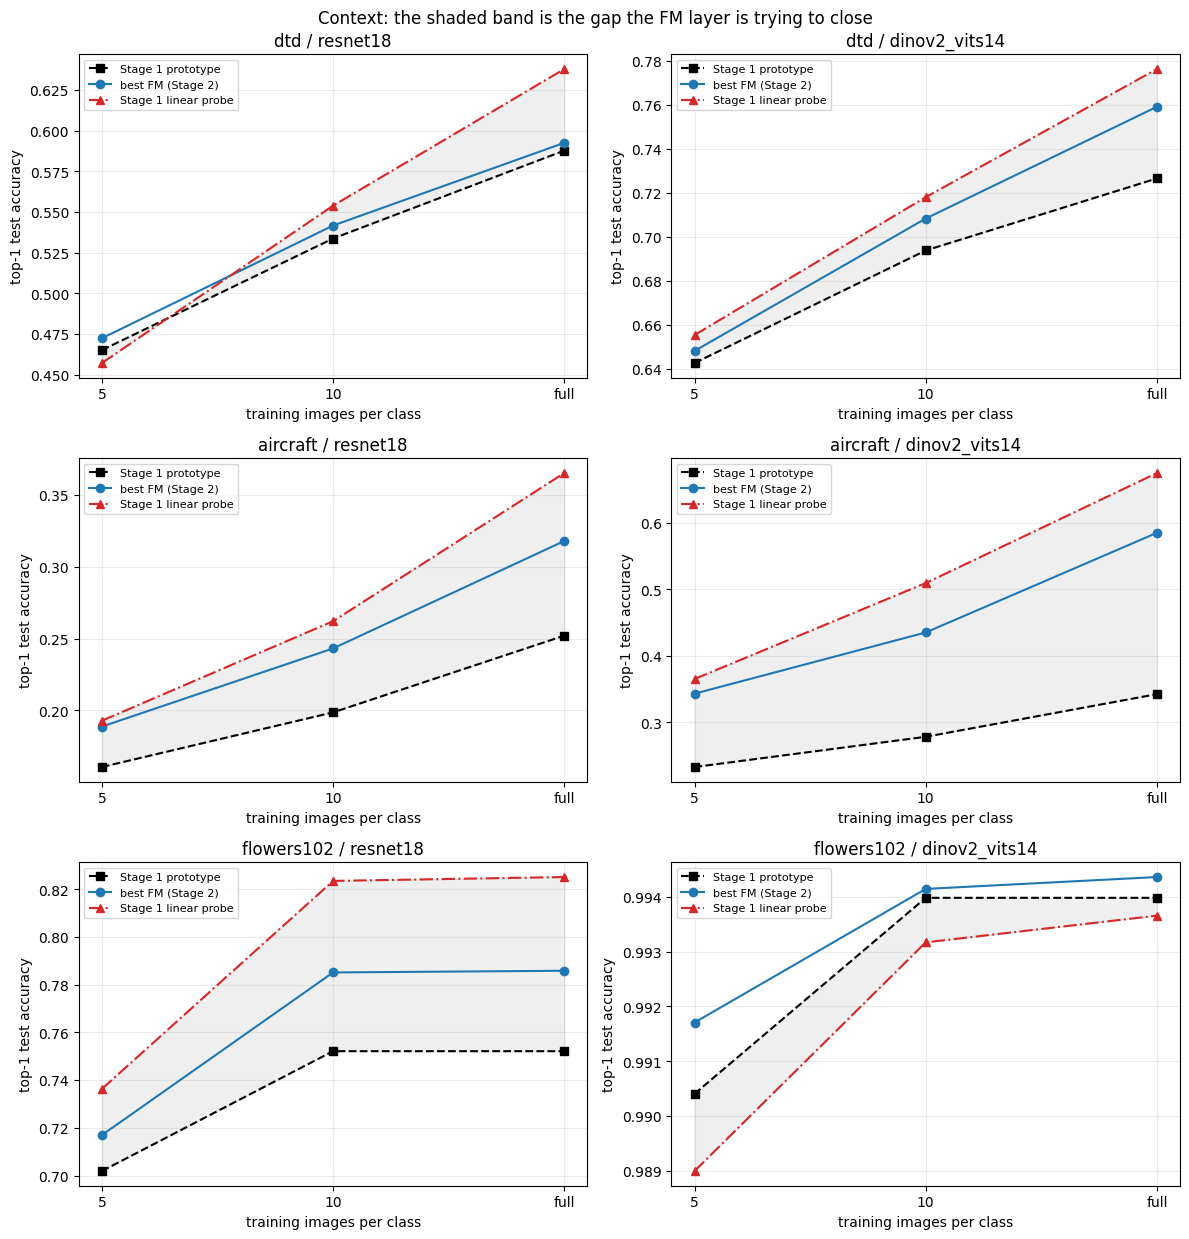

In [26]:
LINEAR_PROBE_SUMMARY = PROJECT_ROOT / 'outputs' / 'linear_probe' / 'accuracy_summary.csv'
if not LINEAR_PROBE_SUMMARY.exists():
    print(f'Skipping: {LINEAR_PROBE_SUMMARY} not found. Run 01_linear_probe.ipynb to enable this context table.')
else:
    probe = (pd.read_csv(LINEAR_PROBE_SUMMARY)
             .rename(columns={'mean_accuracy': 'linear_probe_accuracy', 'std_accuracy': 'linear_probe_std'}))
    probe['shot'] = probe['shot'].astype(str)
    # computed here rather than reused, so this section stands alone if Section 19 is skipped
    best_fm_here = (fm_summary.groupby(['dataset', 'encoder', 'shot'], as_index=False)
                    .agg(best_fm_accuracy=('mean_accuracy', 'max')))
    three_way = (best_fm_here.merge(baseline_summary[['dataset', 'encoder', 'shot', 'baseline_mean_accuracy']],
                               on=['dataset', 'encoder', 'shot'], how='left')
                 .merge(probe[['dataset', 'encoder', 'shot', 'linear_probe_accuracy']],
                        on=['dataset', 'encoder', 'shot'], how='left')
                 .rename(columns={'baseline_mean_accuracy': 'prototype', 'best_fm_accuracy': 'flow_matching',
                                  'linear_probe_accuracy': 'linear_probe'}))
    headroom = three_way.linear_probe - three_way.prototype
    three_way['fm_gain'] = three_way.flow_matching - three_way.prototype
    # what fraction of the prototype -> linear-probe gap does the FM layer recover?
    three_way['gap_closed'] = np.where(headroom.abs() > 1e-9, three_way.fm_gain / headroom, np.nan)
    three_way['winner'] = np.where(three_way.flow_matching > three_way.linear_probe, 'FM', 'linear probe')
    three_way = three_way.sort_values(['dataset', 'encoder', 'shot'])
    three_way.to_csv(OUTPUT_ROOT / 'fm_vs_linear_probe_context.csv', index=False)

    fm_wins = int((three_way.winner == 'FM').sum())
    print('CONTEXT ONLY - the required Stage 2 comparison is against the Stage 1 *prototype* baseline,')
    print('which Section 8 reports. The linear probe is the other Stage 1 baseline (01_linear_probe.ipynb)')
    print('and is shown here because it is the obvious question: how much of the gap between a frozen')
    print('prototype rule and a trained discriminative head does the FM layer actually recover?')
    print(f'FM beats the linear probe in {fm_wins} of {len(three_way)} settings; '
          f'median gap closed {three_way.gap_closed.median():.0%}.')
    display(three_way.style.format({'prototype': '{:.4f}', 'flow_matching': '{:.4f}',
                                    'linear_probe': '{:.4f}', 'fm_gain': '{:+.4f}',
                                    'gap_closed': '{:.0%}'}))

    shot_x = {'5': 0, '10': 1, 'full': 2}
    fig, axes = plt.subplots(len(DATASETS), max_encoders,
                             figsize=(6.0 * max_encoders, 4.2 * len(DATASETS)), squeeze=False)
    for i, dataset_name in enumerate(DATASETS):
        for j, encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
            ax = axes[i, j]
            part = three_way[(three_way.dataset == dataset_name) &
                             (three_way.encoder == encoder_name)].copy()
            part['x'] = part.shot.map(shot_x); part = part.sort_values('x')
            ax.plot(part.x, part.prototype, 's--', color='black', label='Stage 1 prototype')
            ax.plot(part.x, part.flow_matching, 'o-', color='tab:blue', label='best FM (Stage 2)')
            ax.plot(part.x, part.linear_probe, '^-.', color='tab:red', label='Stage 1 linear probe')
            ax.fill_between(part.x, part.prototype, part.linear_probe, color='gray', alpha=.12)
            ax.set(title=f'{dataset_name} / {encoder_name}', xticks=[0, 1, 2],
                   xticklabels=['5', '10', 'full'], xlabel='training images per class',
                   ylabel='top-1 test accuracy')
            ax.grid(alpha=.25); ax.legend(fontsize=8)
        for j in range(len(ENCODERS_BY_DATASET[dataset_name]), max_encoders):
            axes[i, j].axis('off')
    fig.suptitle('Context: the shaded band is the gap the FM layer is trying to close')
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / 'fm_vs_linear_probe_context.png', dpi=180, bbox_inches='tight'); plt.show()

## 21. Animated flow trajectories

The static figures show every Euler state at once; these animations play the **same real transport** through time, standard FM and rolled-out FM side by side from an identical starting feature, so what differs on screen is purely the training objective. At each step an arrow shows the actual update being applied, `(1/T) * v_theta(z_k, k/T)`, projected into the plot plane.

The setting is **chosen programmatically** as the (dataset, encoder) with the largest ΔAcc in Section 8, so the animation always shows the case where the FM layer does the most work rather than a hardcoded favourite. Everything comes from the saved checkpoints; the cell asserts that both trajectories have `T+1` states, that both start from the identical normalized feature, and that no gradients are involved.

**Read these qualitatively.** The transport happens in the encoder's full feature space; this is a 2-D projection of that motion, so projected path length, curvature, and arrow direction are not high-dimensional measurements. What they convey is the mechanism: how `T` small updates accumulate into the representation the cosine rule finally classifies.

Animating the largest-gain setting: aircraft / dinov2_vits14 (shot full, standard T=4, delta +0.2428)
[OK] 3 examples, 13 states each, both models share the same start
[OK] example 0 -> flow_animation_aircraft_dinov2_vits14_ex0.gif



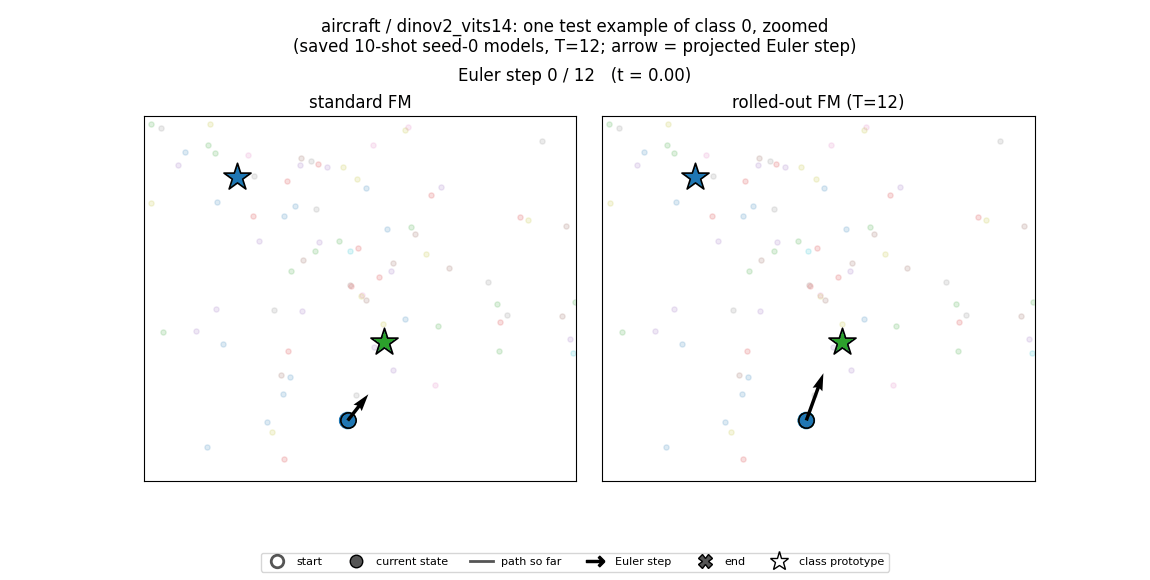

[OK] example 1 -> flow_animation_aircraft_dinov2_vits14_ex1.gif



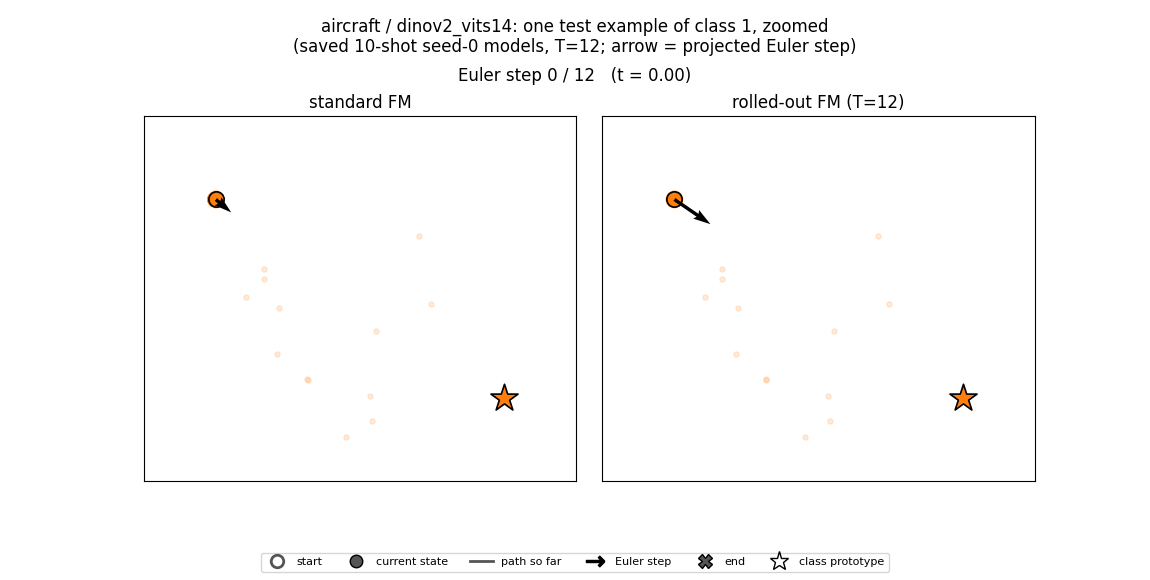

[OK] example 2 -> flow_animation_aircraft_dinov2_vits14_ex2.gif



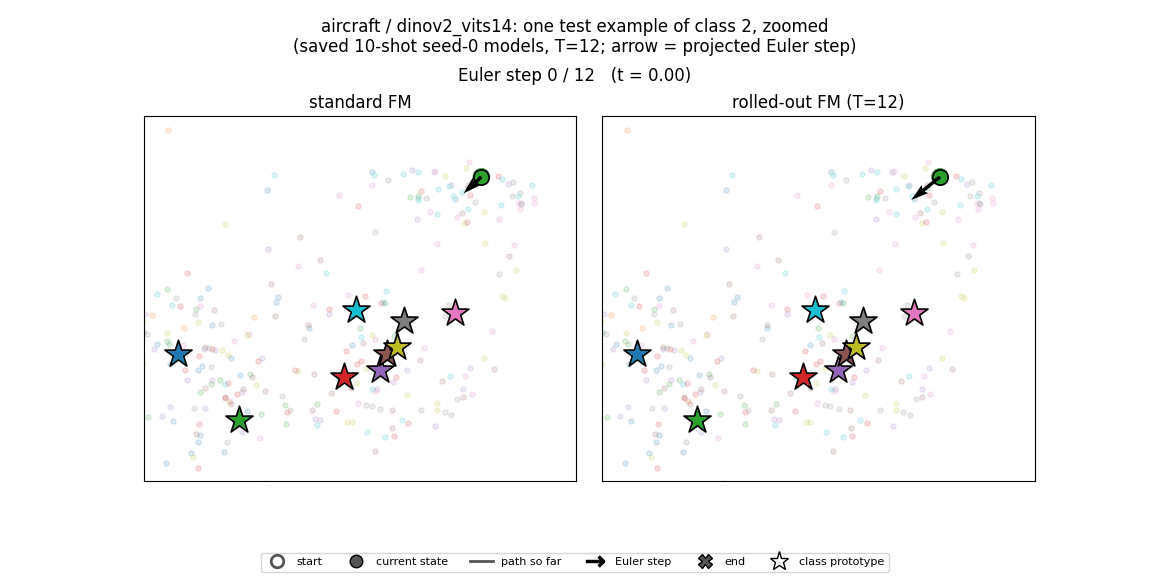

Artifacts saved to: /content/drive/MyDrive/Flow-Matching/outputs/flow_matching


In [27]:
import base64
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import HTML

# Pick the setting where the FM layer does the most work, rather than hardcoding one.
_best = comparison.loc[comparison.delta_acc.idxmax()]
ANIM_DATASET, ANIM_ENCODER = str(_best.dataset), str(_best.encoder)
ANIM_T, N_EXAMPLES = INTERMEDIATE_T, 3
print(f'Animating the largest-gain setting: {ANIM_DATASET} / {ANIM_ENCODER} '
      f'(shot {_best.shot}, {_best.variant} T={_best["T"]}, delta {_best.delta_acc:+.4f})')

bank = feature_bank[(ANIM_DATASET, ANIM_ENCODER)]['test']
labels = bank['labels'].numpy()
selected_classes = np.arange(10)
sel = np.concatenate([np.flatnonzero(labels == c)[:30] for c in selected_classes])
z_bg = F.normalize(bank['features'][sel].float(), dim=1).to(DEVICE)
y_bg = labels[sel]
protos_t, _ = load_stage1_prototypes(ANIM_DATASET, ANIM_ENCODER, INTERMEDIATE_SHOT, INTERMEDIATE_SEED)
protos_t = protos_t.to(DEVICE)
nets = {tag: load_trained_network(ANIM_DATASET, ANIM_ENCODER, INTERMEDIATE_SHOT, INTERMEDIATE_SEED,
                                  0, tag, z_bg.shape[1]) for tag, _ in INTERMEDIATE_MODES}

example_classes = selected_classes[:N_EXAMPLES]
ex_idx = [int(np.flatnonzero(y_bg == c)[0]) for c in example_classes]
z_ex = z_bg[ex_idx]
trajs = {}
for tag, net in nets.items():
    with torch.no_grad():
        _, tr = euler_rollout(net, z_ex, ANIM_T, return_trajectory=True)
    stacked = torch.stack(tr)
    assert stacked.shape[0] == ANIM_T + 1, 'trajectory must have T+1 states'
    assert torch.allclose(stacked[0], z_ex), 'trajectory must start from the untouched feature'
    assert not stacked.requires_grad, 'no gradients during trajectory generation'
    trajs[tag] = stacked.cpu().numpy()
tag_a, tag_b = INTERMEDIATE_MODES[0][0], INTERMEDIATE_MODES[1][0]
assert np.allclose(trajs[tag_a][0], trajs[tag_b][0]), 'both models must start from identical features'
print(f'[OK] {N_EXAMPLES} examples, {ANIM_T + 1} states each, both models share the same start')

protos_np = protos_t[selected_classes].cpu().numpy()
pca = PCA(n_components=2).fit(np.concatenate(
    [z_bg.cpu().numpy()] + [trajs[t].reshape(-1, z_bg.shape[1]) for t, _ in INTERMEDIATE_MODES] + [protos_np]))
bg_xy, proto_xy = pca.transform(z_bg.cpu().numpy()), pca.transform(protos_np)
traj_xy = {tag: np.stack([pca.transform(trajs[tag][:, i]) for i in range(N_EXAMPLES)])
           for tag, _ in INTERMEDIATE_MODES}
palette = sns.color_palette('tab10', 10)
LEGEND = [Line2D([], [], marker='o', ls='', ms=9, mfc='none', mec='#555555', mew=2, label='start'),
          Line2D([], [], marker='o', ls='', ms=9, color='#555555', mec='black', label='current state'),
          Line2D([], [], color='#555555', lw=2, label='path so far'),
          Line2D([], [], marker=r'$\rightarrow$', ls='', ms=13, color='black', label='Euler step'),
          Line2D([], [], marker='X', ls='', ms=10, color='#555555', mec='black', label='end'),
          Line2D([], [], marker='*', ls='', ms=14, mfc='white', mec='black', label='class prototype')]

def animate_example(i):
    cls = int(y_bg[ex_idx[i]]); color = palette[cls]
    pts = np.concatenate([traj_xy[t][i] for t, _ in INTERMEDIATE_MODES] + [proto_xy[cls:cls + 1]])
    lo, hi = pts.min(0), pts.max(0); pad = 0.25 * max(float(np.max(hi - lo)), 1e-6)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.8))
    fig.subplots_adjust(top=0.80, bottom=0.17, wspace=0.06)
    panels = []
    for ax, (tag, label) in zip(axes, INTERMEDIATE_MODES):
        xy = traj_xy[tag][i]
        for c in range(10):
            m = y_bg == c
            ax.scatter(bg_xy[m, 0], bg_xy[m, 1], s=14, alpha=.15, color=palette[c])
            ax.scatter(proto_xy[c, 0], proto_xy[c, 1], marker='*', s=420, color=palette[c],
                       edgecolors='black', linewidths=1.2, zorder=5)
        ax.scatter([xy[0, 0]], [xy[0, 1]], s=110, facecolors='none', edgecolors=color,
                   linewidths=2.2, zorder=6)
        trail, = ax.plot([], [], color=color, lw=2.0, zorder=4)
        cur, = ax.plot([], [], marker='o', ms=11, color=color, mec='black', mew=1.2, zorder=7)
        arrow = ax.quiver([xy[0, 0]], [xy[0, 1]], [0.], [0.], angles='xy', scale_units='xy',
                          scale=1.0, color='black', width=0.008, zorder=8)
        fin = ax.scatter([], [], marker='X', s=140, color=color, edgecolors='black', zorder=9, visible=False)
        ax.set(xlim=(lo[0] - pad, hi[0] + pad), ylim=(lo[1] - pad, hi[1] + pad), title=label,
               xticks=[], yticks=[])
        panels.append(dict(trail=trail, cur=cur, arrow=arrow, fin=fin, xy=xy))
    step_txt = fig.text(0.5, 0.86, '', ha='center', fontsize=12)
    fig.legend(handles=LEGEND, loc='lower center', bbox_to_anchor=(0.5, 0.005), ncol=6, fontsize=8)
    fig.suptitle(f'{ANIM_DATASET} / {ANIM_ENCODER}: one test example of class {cls}, zoomed\n'
                 f'(saved 10-shot seed-0 models, T={ANIM_T}; arrow = projected Euler step)',
                 y=0.97, fontsize=12)

    def draw(k):
        for p in panels:
            xy = p['xy']
            p['trail'].set_data(xy[:k + 1, 0], xy[:k + 1, 1])
            p['cur'].set_data([xy[k, 0]], [xy[k, 1]])
            if k < ANIM_T:
                p['arrow'].set_offsets(xy[k:k + 1])
                p['arrow'].set_UVC([xy[k + 1, 0] - xy[k, 0]], [xy[k + 1, 1] - xy[k, 1]])
                p['arrow'].set_visible(True)
            else:
                p['arrow'].set_visible(False)
            p['fin'].set_visible(k == ANIM_T)
            if k == ANIM_T: p['fin'].set_offsets(xy[-1:])
        step_txt.set_text(f'Euler step {k} / {ANIM_T}   (t = {k / ANIM_T:.2f})')
        return []

    frames = [0] * 3 + list(range(1, ANIM_T)) + [ANIM_T] * 4
    anim = FuncAnimation(fig, draw, frames=frames, interval=600, blit=False)
    path = OUTPUT_ROOT / f'flow_animation_{ANIM_DATASET}_{ANIM_ENCODER}_ex{i}.gif'
    try:
        anim.save(path, writer=PillowWriter(fps=2))
    except Exception as err:
        print(f'[WARN] GIF export failed for example {i} ({err}); showing the final frame instead.')
        draw(ANIM_T); plt.show(); plt.close(fig); return None
    plt.close(fig)
    return path

for i in range(N_EXAMPLES):
    gif = animate_example(i)
    if gif is not None:
        print(f'[OK] example {i} -> {gif.name}')
        display(HTML('<img src="data:image/gif;base64,'
                     + base64.b64encode(gif.read_bytes()).decode('ascii') + '" width="900"/>'))
print('Artifacts saved to:', OUTPUT_ROOT)